# FCFF DCF Valuation v9 — V10 Excel Export 통합본

## 변경 사항 (원본 v9 대비)

이 노트북은 호영님의 원본 `FCFF_DCF_Valuation_v9.ipynb` 에 다음 기능을 통합한 완성본입니다:

1. **DCFModel 패치** (Cell 4 직후 추가됨)
   - `_estimate_phase2_growth` 음수 g₀ 처리 개선
   - `_fetch_v10_extras` 메서드 추가 (10Y monthly + profile)
   - `export_v10_excel` 메서드 추가 (9-sheet workbook)

2. **단일 ticker Excel export 셀** (Cell 5 위에 추가됨)
   - `EXPORT_TICKER` 한 줄만 바꿔서 즉시 Excel 생성

3. **배치 실행 셀 수정** (기존 Cell 5 교체)
   - `EXPORT_EXCEL` 옵션 추가 (default `False`)
   - `True` 일 때 ticker 별 Excel 자동 생성

## 사용 방법

**위에서 아래로 셀을 차례대로 실행**하시면 됩니다:

| 셀 그룹 | 역할 |
|---|---|
| Cell 1~4 | 환경 setup + DCFModel 정의 (원본 그대로) |
| Cell 4.5 | 3-Stage DCF Decomposition (원본 그대로) |
| **Cell 4.6 (NEW)** | **★ DCFModel 패치 적용 ★** (한 번만 실행하면 됨) |
| **Cell 5.0 (NEW)** | **★ 단일 ticker → Excel** (`EXPORT_TICKER` 만 수정) |
| Cell 5 | 배치 실행 (`EXPORT_EXCEL` 옵션 추가됨) |
| Cell 6, 7 | 결과 조회 / 시각화 / Sensitivity (원본 그대로) |

## 가장 흔한 사용 패턴

**한 종목만 빠르게 분석하고 싶을 때** → Cell 1~4.6 까지 한 번 실행 후, Cell 5.0 에서 ticker 만 바꿔가며 반복 실행

**2,000개 batch 실행하고 싶을 때** → Cell 1~4.6 한 번 실행 후, Cell 5 의 `EXPORT_EXCEL` 옵션 설정 후 실행


## Cell 1 · 경로 자동 감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root 자동 감지 : {root}")
            return root
    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "DATA")):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f"[PATH] root 후보 경로 : {candidate}")
            return candidate
    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다.\n"
        "_CANDIDATE_ROOTS 를 현재 환경에 맞게 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")


[PATH] root 자동 감지 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · Import & 설정 상수

> **여기만 수정하면 됩니다**: `TICKER_START / TICKER_END / SKIP_DONE / DISCOUNT_MODE`

In [2]:
# ── 표준 라이브러리 ──────────────────────────────────────────────
import gc, math, time, traceback, warnings
import requests
from datetime import datetime
from typing import Optional, Dict, Any, List, Tuple

# ── 외부 라이브러리 ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

# ── 내부 모듈 ────────────────────────────────────────────────────
from DATA.config import get_db_info, get_engine
from DATA.us_target_ticker_list_2000 import ticker_list as US_TICKER_LIST
from DATA.universal_ts_forecast_function_v2 import (
    forecast_sarima, forecast_ets, forecast_theta,
    infer_freq_alias, seasonal_periods_from_freq, clear_memory,
)

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ══════════════════════════════════════════════════════════════════
#  설정 상수 — 여기만 수정하세요
# ══════════════════════════════════════════════════════════════════
FMP_API_KEY   = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"
FMP_BASE      = "https://financialmodelingprep.com/api/v3"
FMP_LIMIT     = 40          # 분기 수 (최대 조회)
FMP_SLEEP     = 0.35        # API 호출 간격 (초)

# DB 테이블
TABLE_SALES    = "us_revenue_forecast_data"   # Sales 예측 결과
TABLE_RE       = "us_rim_spread_data"         # Re_smooth
TABLE_RESULT   = "us_fcff_dcf_valuation"      # 저장 결과
DEFAULT_PORT   = 3307

# 모델 파라미터
FORECAST_HORIZON   = 8        # 예측 분기 수
MIN_HISTORY        = 20        # OPM 회귀 최소 분기 수
WINSORIZE_LIMITS   = (0.05, 0.95)
DISCOUNT_MODE      = "wacc"    # 'wacc' or 're'
GDP_GROWTH         = 0.04      # terminal growth 상한

# OLS fallback 기준
OLS_MIN_R2         = 0.30
OLS_MIN_SAMPLES    = 20

# 배치 범위 (필요 시 조정)
TICKER_START = 0
TICKER_END   = 1000 #len(US_TICKER_LIST)
SKIP_DONE    = True

CHECKPOINT_DIR = "_fcff_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DONE_PATH = os.path.join(CHECKPOINT_DIR, "done_tickers.txt")
FAIL_PATH = os.path.join(CHECKPOINT_DIR, "failed_tickers.txt")

db_info = get_db_info()
engine  = get_engine(db_info)

print(f"[OK] Import 완료  |  대상 티커: {len(US_TICKER_LIST):,}개")
print(f"[설정] DISCOUNT_MODE={DISCOUNT_MODE}  FORECAST_HORIZON={FORECAST_HORIZON}  GDP_GROWTH={GDP_GROWTH}")


[OK] Import 완료  |  대상 티커: 2,000개
[설정] DISCOUNT_MODE=wacc  FORECAST_HORIZON=8  GDP_GROWTH=0.04


## Cell 3 · DB 연결 & 결과 테이블 초기화

In [3]:
# ── DB 연결 함수 ────────────────────────────────────────────────
def get_conn():
    return pymysql.connect(
        host       = db_info["host"],
        port       = int(db_info.get("port", DEFAULT_PORT)),
        user       = db_info["user"],
        password   = db_info["password"],
        db         = db_info.get("database", "investar"),
        charset    = "utf8mb4",
        autocommit = False,
        cursorclass= pymysql.cursors.DictCursor,
    )

# ── 결과 테이블 생성 ─────────────────────────────────────────────
CREATE_SQL = """
CREATE TABLE IF NOT EXISTS `us_fcff_dcf_valuation` (
  `id`                BIGINT      NOT NULL AUTO_INCREMENT,
  `date`              DATE        NOT NULL COMMENT '예측 실행일',
  `ticker`            VARCHAR(20) NOT NULL,
  `quarter`           VARCHAR(10)          COMMENT 'e.g. 2026Q1',
  `sales_actual`      DOUBLE               COMMENT '과거 Sales',
  `sales_forecast`    DOUBLE               COMMENT '예측 Sales',
  `opm_forecast`      DOUBLE               COMMENT '예측 OPM',
  `ebit`              DOUBLE,
  `tax_rate`          DOUBLE,
  `nopat`             DOUBLE,
  `da`                DOUBLE,
  `capex`             DOUBLE,
  `nwc`               DOUBLE,
  `delta_nwc`         DOUBLE,
  `fcff`              DOUBLE,
  `roic`              DOUBLE,
  `reinvestment_rate` DOUBLE,
  `g_terminal`        DOUBLE,
  `discount_rate`     DOUBLE,
  `enterprise_value`  DOUBLE,
  `net_debt`          DOUBLE,
  `equity_value`      DOUBLE,
  `shares`            DOUBLE,
  `target_price`      DOUBLE,
  `current_price`     DOUBLE,
  `upside_pct`        DOUBLE,
  `created_at`        DATETIME    DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`, `quarter`),
  INDEX idx_ticker (`ticker`),
  INDEX idx_date   (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""

conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"테이블 준비 완료: {TABLE_RESULT}")
finally:
    conn.close()

# 연결 테스트
try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"연결 성공  host={db_info.get('host')}  port={db_info.get('port')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")


[01:19:25][DB] 테이블 준비 완료: us_fcff_dcf_valuation
[01:19:25][DB] 연결 성공  host=192.168.0.230  port=3307


## Cell 4 · DCFModel 클래스

### 클래스 구조
| 메서드 | 역할 |
|--------|------|
| `load_sales()` | DB → 과거 + 예측 Sales |
| `load_financials()` | FMP → IS/BS/CF |
| `estimate_tax_rate()` | 실효세율 (pretaxIncome>0 분기) |
| `estimate_opm()` | SARIMA/ETS/Theta Ensemble OPM 예측 |
| `estimate_ratio_coef()` | D&A/CapEx OLS 또는 median ratio |
| `estimate_nwc_coef()` | NWC/Sales 계수 |
| `compute_fcff()` | FCFF = NOPAT + D&A - CapEx - ΔNWC |
| `compute_wacc()` | WACC (Re_smooth + Rd) |
| `compute_terminal_growth()` | g = min(GDP, 0.5×CAGR + 0.5×ROIC×reinv) |
| `compute_valuation()` | DCF → EV → TP |
| `save_to_db()` | 결과 DB 저장 |
| `plot()` | 4패널 시각화 |
| `run()` | 전체 실행 |

[OK] DCFModel 클래스 & process_one_ticker 정의 완료

[테스트] FIX 단일 실행 ...
[01:23:13][FIX] forecast_date=2026-04-03  models=['Ensemble', 'ETS', 'LSTM', 'Prophet', 'SARIMA', 'Theta']
[01:23:13][FIX] Sales 로드 완료  actual=44Q  forecast=8Q  model=Ensemble  forecast_date=2026-04-03
[01:23:16][FIX] IS=30Q / BS=30Q / CF=30Q
[메모리] forecast_sarima 실행 전: 474.44 MB
[메모리] find_best_sarima_params 실행 전: 474.44 MB
[메모리] find_best_sarima_params 실행 후: 474.55 MB (변화: +0.11 MB)
[메모리] forecast_sarima 실행 후: 474.55 MB (변화: +0.11 MB)
[메모리] forecast_ets 실행 전: 474.55 MB
[메모리] forecast_ets 실행 후: 474.55 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 474.55 MB
[메모리] forecast_theta 실행 후: 474.55 MB (변화: +0.00 MB)
[01:23:28][FIX] D&A: OLS 부적합(R²=0.185) → median ratio=0.019732
[01:23:28][FIX] CapEx: OLS slope=0.030872 R²=0.592
[01:23:28][FIX] NWC: OLS γ=-0.1254 R²=0.475
[01:23:28][FIX] [NWC seed] γ×sales=-331,865,587 vs 실측=-140,524,000 괴리 136.2%
[01:23:29][FIX] WACC=0.1528  Re=0.1538 Rd=0.0073 tax=0.2100
[01:23:29][FIX] EVA: ROI

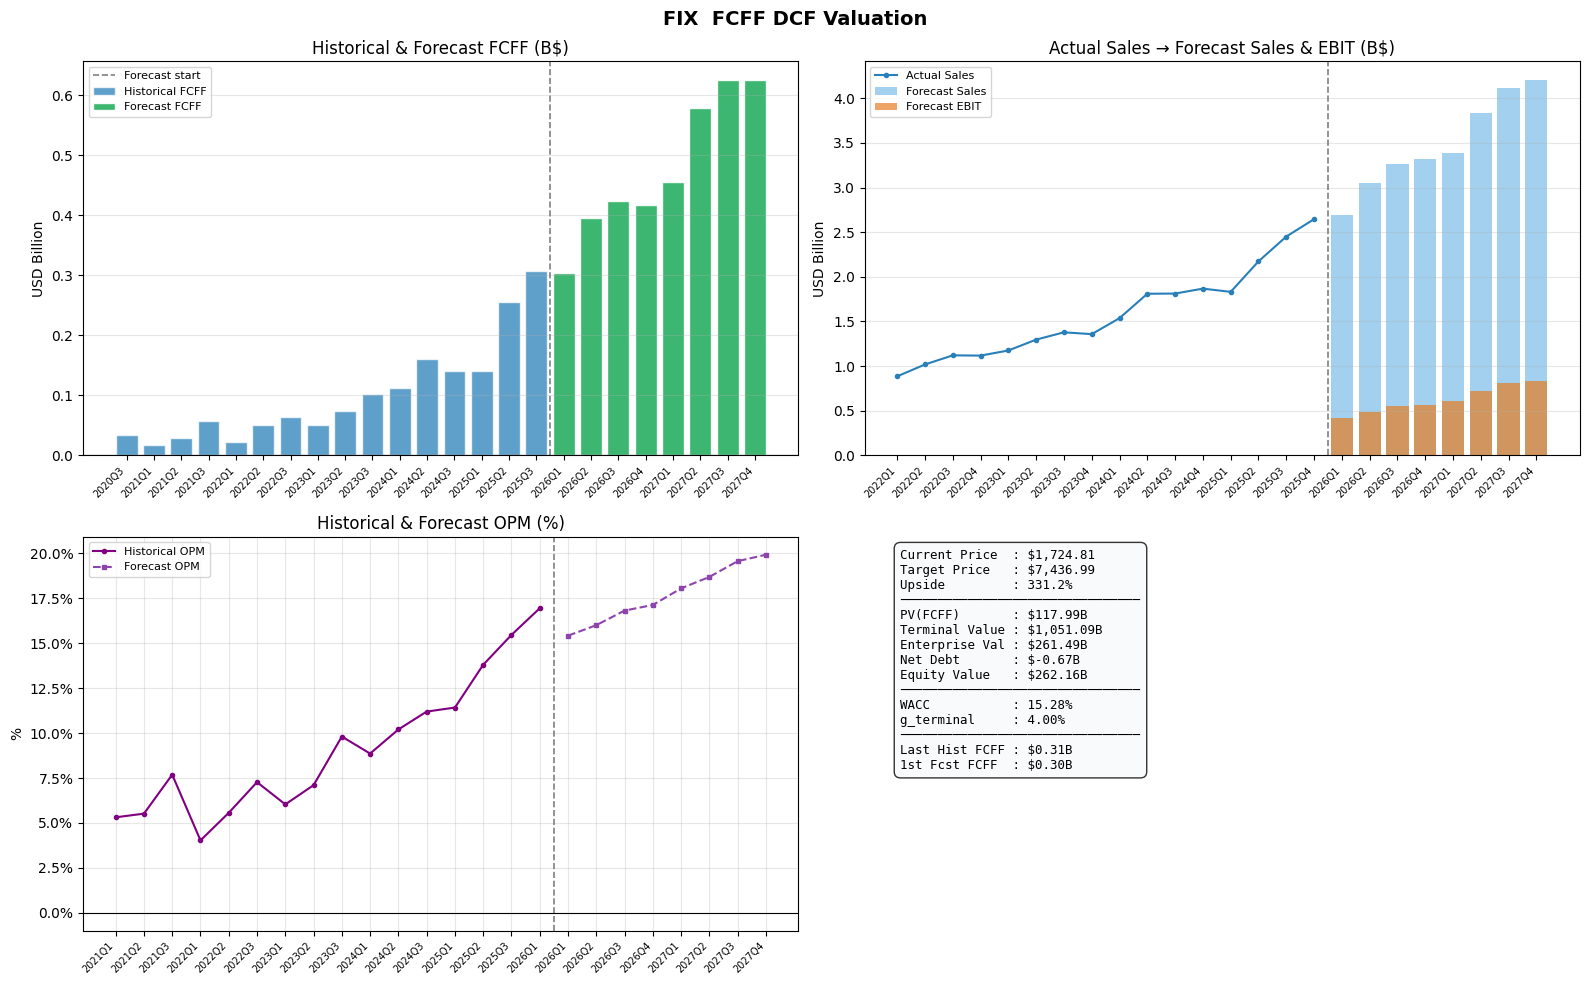

In [11]:
# ═══════════════════════════════════════════════════════════════
#  DCFModel 클래스
# ═══════════════════════════════════════════════════════════════

class DCFModel:
    """
    Sales-driven FCFF DCF Valuation Model

    Parameters
    ----------
    ticker : str
    engine : SQLAlchemy engine  (Sales DB 조회용)
    fmp_api_key : str
    forecast_horizon : int      (예측 분기 수, default 12)
    min_history : int           (OPM 회귀 최소 관측치, default 16)
    discount_mode : str         'wacc' or 're'
    gdp_growth : float          terminal growth 상한 (default 0.04)
    verbose : bool              디버그 출력 여부
    """

    def __init__(
        self,
        ticker: str,
        engine,
        fmp_api_key: str = FMP_API_KEY,
        forecast_horizon: int = FORECAST_HORIZON,
        min_history: int = MIN_HISTORY,
        discount_mode: str = DISCOUNT_MODE,
        gdp_growth: float = GDP_GROWTH,
        verbose: bool = False,
    ):
        self.ticker           = ticker.upper()
        self.engine           = engine
        self.api_key          = fmp_api_key
        self.horizon          = forecast_horizon
        self.min_history      = min_history
        self.discount_mode    = discount_mode
        self.gdp_growth       = gdp_growth
        self.verbose          = verbose

        # 내부 저장소
        self._sales_actual:   Optional[pd.Series] = None
        self._sales_forecast: Optional[pd.Series] = None
        self._inc:            Optional[pd.DataFrame] = None
        self._bs:             Optional[pd.DataFrame] = None
        self._cf:             Optional[pd.DataFrame] = None
        self._fcff_history:   Optional[pd.Series] = None
        self.result_df:       Optional[pd.DataFrame] = None
        self.valuation:       Optional[Dict] = None

    # ─────────────────────────────────────────────────────────────
    # 1. 데이터 로드
    # ─────────────────────────────────────────────────────────────

    def load_sales(self) -> "DCFModel":
        """
        DB (us_revenue_forecast_data) 에서 Sales 로드.
        ★ cursor.execute → fetchall → pd.DataFrame 패턴 (pd.read_sql + pymysql 비호환 방지)
        ★ forecast_date 가 가장 최신인 행만 사용
        ★ forecast: model 우선순위 Ensemble → SARIMA → ETS → Theta
        """
        conn_local = get_conn()
        try:
            # ── actual: data_type='actual' 전체 ────────────────────
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT date, data_type, model, value "
                    f"FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='actual' "
                    f"ORDER BY date",
                    (self.ticker,)
                )
                actual_rows = cur.fetchall()

            # ── forecast: 가장 최신 forecast_date 의 행만 ──────────
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT MAX(forecast_date) AS max_fd "
                    f"FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='forecast'",
                    (self.ticker,)
                )
                row = cur.fetchone()
                max_fd = row["max_fd"] if row else None

            if max_fd is None:
                fc_rows = []
            else:
                with conn_local.cursor() as cur:
                    cur.execute(
                        f"SELECT date, data_type, model, value "
                        f"FROM `{TABLE_SALES}` "
                        f"WHERE ticker=%s AND item='sale' "
                        f"  AND data_type='forecast' "
                        f"  AND forecast_date=%s "
                        f"ORDER BY model, date",
                        (self.ticker, max_fd)
                    )
                    fc_rows = cur.fetchall()
        finally:
            conn_local.close()

        # ── actual 처리 ─────────────────────────────────────────────
        if not actual_rows:
            raise ValueError(f"[{self.ticker}] Sales actual 데이터 없음 — us_revenue_forecast_notebook 먼저 실행")

        act_df = pd.DataFrame(actual_rows)
        act_df["date"]  = pd.to_datetime(act_df["date"])
        act_df["value"] = pd.to_numeric(act_df["value"], errors="coerce")
        actual = (act_df.sort_values("date")
                        .drop_duplicates("date", keep="last")
                        .set_index("date")["value"])

        # ── forecast 처리 ──────────────────────────────────────────
        if not fc_rows:
            raise ValueError(
                f"[{self.ticker}] forecast Sales 없음 "
                f"(forecast_date={max_fd}) — us_revenue_forecast_notebook 먼저 실행"
            )

        fc_df = pd.DataFrame(fc_rows)
        fc_df["date"]  = pd.to_datetime(fc_df["date"])
        fc_df["value"] = pd.to_numeric(fc_df["value"], errors="coerce")

        if self.verbose:
            models_in_db = fc_df["model"].unique().tolist()
            log(self.ticker, f"forecast_date={max_fd}  models={models_in_db}")

        # 우선순위: Ensemble → SARIMA → ETS → Theta → 첫 번째 모델
        priority = ["Ensemble", "SARIMA", "ETS", "Theta"]
        available = fc_df["model"].unique().tolist()
        ordered   = [m for m in priority if m in available] +                     [m for m in available if m not in priority]

        forecast = pd.Series(dtype=float)
        used_model = None
        for model_name in ordered:
            fc = (fc_df[fc_df["model"] == model_name]
                  .sort_values("date")
                  .drop_duplicates("date", keep="last")
                  .set_index("date")["value"]
                  .dropna())
            if len(fc) >= self.horizon:
                forecast  = fc.iloc[:self.horizon]
                used_model = model_name
                break
            elif len(fc) > 0 and len(forecast) == 0:
                # 부족해도 일단 보관 (마지막 fallback)
                forecast   = fc
                used_model = model_name

        if forecast.empty:
            raise ValueError(
                f"[{self.ticker}] 예측 Sales 값이 모두 비어있음 "
                f"(forecast_date={max_fd})"
            )

        # horizon 부족 시 마지막 값으로 forward-fill
        if len(forecast) < self.horizon:
            extra_idx = pd.date_range(
                start=forecast.index[-1] + pd.offsets.QuarterEnd(1),
                periods=self.horizon - len(forecast),
                freq="QE"
            )
            fill_val  = float(forecast.iloc[-1])
            forecast  = pd.concat([
                forecast,
                pd.Series([fill_val] * len(extra_idx), index=extra_idx)
            ])
            if self.verbose:
                log(self.ticker, f"  forecast 부족({len(forecast)-len(extra_idx)}개) → 마지막값 forward-fill")

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:self.horizon]
        if self.verbose:
            log(self.ticker,
                f"Sales 로드 완료  actual={len(actual)}Q  "
                f"forecast={len(self._sales_forecast)}Q  "
                f"model={used_model}  forecast_date={max_fd}")
        return self

    def _fmp_get(self, endpoint: str, period: str = "quarter", limit: int = FMP_LIMIT) -> pd.DataFrame:
        """FMP API GET → DataFrame"""
        url = f"{FMP_BASE}/{endpoint}/{self.ticker}"
        for attempt in range(3):
            try:
                r = requests.get(url, params={"period": period, "limit": limit, "apikey": self.api_key}, timeout=20)
                if r.status_code == 429:
                    time.sleep(1.5 + attempt); continue
                r.raise_for_status()
                data = r.json()
                if isinstance(data, dict) and "Error Message" in data:
                    return pd.DataFrame()
                return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame()
            except Exception as e:
                if attempt == 2:
                    if self.verbose: log(self.ticker, f"FMP {endpoint} 실패: {e}")
                    return pd.DataFrame()
                time.sleep(FMP_SLEEP + attempt * 0.5)
        return pd.DataFrame()

    def _parse_date_col(self, df: pd.DataFrame) -> pd.DataFrame:
        """FMP date 컬럼 파싱 + 분기말 날짜로 통일 (acceptedDate 기반 look-ahead bias 보정)"""
        df = df.copy()
        df["report_date"] = pd.to_datetime(
            df.get("acceptedDate", df.get("fillingDate", pd.NaT)), errors="coerce"
        )
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        # look-ahead bias 보정: acceptedDate 있으면 report_date - 45일 → 회계분기말
        def _qend(row):
            if pd.notna(row.get("report_date")):
                return (row["report_date"] - pd.Timedelta(days=45)).to_period("Q").to_timestamp("Q")
            return row["date"].to_period("Q").to_timestamp("Q")
        df["date"] = df.apply(_qend, axis=1)
        df = df.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)
        return df

    def load_financials(self) -> "DCFModel":
        """FMP API → IS / BS / CF 분기 데이터 로드"""
        time.sleep(FMP_SLEEP)
        inc = self._fmp_get("income-statement")
        time.sleep(FMP_SLEEP)
        bs  = self._fmp_get("balance-sheet-statement")
        time.sleep(FMP_SLEEP)
        cf  = self._fmp_get("cash-flow-statement")

        if inc.empty or bs.empty or cf.empty:
            raise ValueError(f"[{self.ticker}] FMP 재무제표 로드 실패 (IS/BS/CF 중 하나 이상 비어있음)")

        self._inc = self._parse_date_col(inc)
        self._bs  = self._parse_date_col(bs)
        self._cf  = self._parse_date_col(cf)
        if self.verbose:
            log(self.ticker, f"IS={len(self._inc)}Q / BS={len(self._bs)}Q / CF={len(self._cf)}Q")

        # ── v8: FMP 필드 존재/품질 sanity check ───────────────────
        # v7 버그의 근본 원인: 필드명 오타 (currentAssets → totalCurrentAssets)가
        # silent하게 0으로 대체되어 γ가 크게 왜곡되었음. v8은 조기 경고로 방지.
        bs_critical = ["totalCurrentAssets", "totalCurrentLiabilities",
                       "cashAndCashEquivalents", "totalDebt"]
        for f in bs_critical:
            if f not in self._bs.columns:
                if self.verbose:
                    log(self.ticker, f"⚠️  BS에 필드 없음: {f}")
            elif pd.to_numeric(self._bs[f], errors="coerce").abs().sum() == 0:
                if self.verbose:
                    log(self.ticker, f"⚠️  BS 필드가 전부 0: {f}")
        return self

    # ─────────────────────────────────────────────────────────────
    # 2. 변수별 추정
    # ─────────────────────────────────────────────────────────────

    @staticmethod
    def _winsorize(s: pd.Series, limits=WINSORIZE_LIMITS) -> pd.Series:
        lo, hi = s.quantile(limits[0]), s.quantile(limits[1])
        return s.clip(lo, hi)

    @staticmethod
    def _ols_ratio(x: pd.Series, y: pd.Series) -> Tuple[float, float]:
        """y = slope*x 단순회귀. R² 반환"""
        mask = x.notna() & y.notna() & (x != 0)
        if mask.sum() < OLS_MIN_SAMPLES:
            return np.nan, -1.0
        slope, _, r, _, _ = stats.linregress(x[mask], y[mask])
        return slope, r ** 2

    def estimate_tax_rate(self) -> float:
        """실효세율 추정 (pretaxIncome > 0 분기만 사용, 범위 0~40%)"""
        inc = self._inc
        cols_needed = ["pretaxIncome", "incomeTaxExpense"]
        if not all(c in inc.columns for c in cols_needed):
            return 0.21  # 법정세율 fallback
        df = inc[cols_needed].apply(pd.to_numeric, errors="coerce")
        df = df[df["pretaxIncome"] > 0].dropna()
        if df.empty:
            return 0.21
        rates = (df["incomeTaxExpense"] / df["pretaxIncome"]).clip(0, 0.40)
        return float(rates.median())

    def estimate_opm(self, sales_series: pd.Series) -> pd.Series:
        """
        OPM 예측: SARIMA/ETS/Theta Ensemble
        fallback: best single → 최근 8분기 median → 전체 median
        과거 IS에서 OPM = operatingIncome / revenue 계산 후 예측
        """
        inc = self._inc
        if "operatingIncome" not in inc.columns or "revenue" not in inc.columns:
            fallback_opm = 0.10
            if self.verbose: log(self.ticker, "OPM: IS 컬럼 없음 → 10% fallback")
            return pd.Series([fallback_opm] * len(sales_series), index=sales_series.index)

        df = inc[["date","operatingIncome","revenue"]].copy()
        df["operatingIncome"] = pd.to_numeric(df["operatingIncome"], errors="coerce")
        df["revenue"]         = pd.to_numeric(df["revenue"], errors="coerce")
        df = df[(df["revenue"] > 0)].dropna().set_index("date").sort_index()
        df["opm"] = df["operatingIncome"] / df["revenue"]
        df["opm"] = self._winsorize(df["opm"])

        opm_series = df["opm"]
        if len(opm_series) < self.min_history:
            fallback = float(opm_series.median()) if not opm_series.empty else 0.10
            if self.verbose: log(self.ticker, f"OPM: 데이터 부족({len(opm_series)}) → median={fallback:.4f}")
            return pd.Series([fallback] * len(sales_series), index=sales_series.index)

        freq_alias = infer_freq_alias(opm_series.index)
        m = seasonal_periods_from_freq(freq_alias)

        forecasts = {}
        for name, fn in [("SARIMA", lambda y: forecast_sarima(y, self.horizon, seasonal_period=m)),
                         ("ETS",    lambda y: forecast_ets(y, self.horizon, m=m)),
                         ("Theta",  lambda y: forecast_theta(y, self.horizon, m=m))]:
            try:
                res = fn(opm_series)
                if "forecast" in res and "error" not in res:
                    forecasts[name] = np.asarray(res["forecast"])
            except Exception:
                pass

        if forecasts:
            ens = np.mean(list(forecasts.values()), axis=0)
            ens = np.clip(ens, -0.50, 0.80)  # OPM 범위 안정화
            return pd.Series(ens, index=sales_series.index)

        # Fallback: 최근 8분기 median → 전체 median
        fallback = float(opm_series.tail(8).median() if len(opm_series) >= 8
                         else opm_series.median())
        fallback = np.clip(fallback, -0.50, 0.80)
        if self.verbose: log(self.ticker, f"OPM: 예측 실패 → median fallback={fallback:.4f}")
        return pd.Series([fallback] * len(sales_series), index=sales_series.index)

    def estimate_ratio_coef(
        self, cf_col: str, ratio_name: str, take_abs: bool = False
    ) -> Tuple[float, str]:
        """
        D&A / CapEx / NWC 비율 계수 추정.
        OLS slope 우선 → R²<0.30 or 표본부족 or 음수 slope → median ratio fallback
        반환: (coef, method_used)
        """
        # Sales 매칭
        inc = self._inc[["date","revenue"]].copy()
        inc["revenue"] = pd.to_numeric(inc["revenue"], errors="coerce")

        # 데이터 소스 선택 (IS/BS/CF)
        if cf_col in self._cf.columns:
            src = self._cf[["date", cf_col]].copy()
        elif cf_col in self._inc.columns:
            src = self._inc[["date", cf_col]].copy()
        elif cf_col in self._bs.columns:
            src = self._bs[["date", cf_col]].copy()
        else:
            if self.verbose: log(self.ticker, f"{ratio_name}: 컬럼 없음 → 0 반환")
            return 0.0, "missing"

        src[cf_col] = pd.to_numeric(src[cf_col], errors="coerce")
        if take_abs:
            src[cf_col] = src[cf_col].abs()

        merged = inc.merge(src, on="date", how="inner").dropna()
        merged = merged[merged["revenue"] > 0]

        if merged.empty:
            return 0.0, "empty"

        x = merged["revenue"]
        y = merged[cf_col]

        slope, r2 = self._ols_ratio(x, y)

        use_ols = (
            not np.isnan(slope)
            and r2 >= OLS_MIN_R2
            and slope >= 0
            and len(merged) >= OLS_MIN_SAMPLES
        )

        if use_ols:
            if self.verbose: log(self.ticker, f"{ratio_name}: OLS slope={slope:.6f} R²={r2:.3f}")
            return float(slope), "ols"
        else:
            ratios = (y / x).replace([np.inf, -np.inf], np.nan).dropna()
            if ratios.empty:
                return 0.0, "ratio_empty"
            ratios = self._winsorize(ratios)
            med = float(ratios.median())
            if self.verbose: log(self.ticker, f"{ratio_name}: OLS 부적합(R²={r2:.3f}) → median ratio={med:.6f}")
            return max(med, 0.0), "median_ratio"

    # ─────────────────────────────────────────────────────────────
    # v8 변경: FMP 실제 필드명은 `totalCurrentAssets`. v7은 `currentAssets`로
    # 조회하여 KeyError 회피 로직(0으로 대체)에 의해 silent bug 발생.
    # → alias 매핑으로 정확 필드 우선 사용하고, 주요 필드 누락 시 경고 로그 출력.
    # 또한 마지막 실측 NWC(`_last_actual_nwc`)를 저장하여 compute_fcff의
    # ΔNWC 시드로 활용 (예측 1분기 FCFF 과대계상 방지).
    # ─────────────────────────────────────────────────────────────
    NWC_FIELD_ALIASES = {
        "totalCurrentAssets":      ["totalCurrentAssets", "currentAssets"],
        "cashAndCashEquivalents":  ["cashAndCashEquivalents", "cashAndShortTermInvestments"],
        "totalCurrentLiabilities": ["totalCurrentLiabilities"],
        "shortTermDebt":           ["shortTermDebt"],
    }

    def _compute_bs_nwc_series(self) -> pd.DataFrame:
        """BS에서 분기별 NWC 시계열 계산 (v8: alias 기반 정확 필드 매핑)."""
        bs = self._bs.copy()
        for std_name, aliases in self.NWC_FIELD_ALIASES.items():
            if std_name in bs.columns:
                continue
            matched = False
            for alias in aliases:
                if alias in bs.columns:
                    bs[std_name] = bs[alias]
                    matched = True
                    break
            if not matched:
                if self.verbose:
                    log(self.ticker, f"[NWC] 필드 없음 → 0 대체: {std_name}")
                bs[std_name] = 0.0
        for c in self.NWC_FIELD_ALIASES.keys():
            bs[c] = pd.to_numeric(bs[c], errors="coerce").fillna(0)

        bs["nwc"] = (
            (bs["totalCurrentAssets"] - bs["cashAndCashEquivalents"])
            - (bs["totalCurrentLiabilities"] - bs["shortTermDebt"])
        )
        return bs[["date", "nwc"]].sort_values("date").reset_index(drop=True)

    def estimate_nwc_coef(self) -> Tuple[float, str]:
        """
        NWC = (Total Current Assets - Cash) - (Total Current Liabilities - Short-term Debt)
        NWC/Sales 비율 OLS or median. 마지막 실측 NWC는 `_last_actual_nwc`에 저장.
        """
        nwc_df = self._compute_bs_nwc_series()

        # 마지막 실측 NWC 저장 (compute_fcff에서 ΔNWC 시드로 사용)
        self._last_actual_nwc = (float(nwc_df["nwc"].iloc[-1])
                                 if not nwc_df.empty else 0.0)

        inc = self._inc[["date", "revenue"]].copy()
        inc["revenue"] = pd.to_numeric(inc["revenue"], errors="coerce")
        merged = inc.merge(nwc_df, on="date", how="inner").dropna()
        merged = merged[merged["revenue"] > 0]

        if merged.empty:
            return 0.0, "empty"

        slope, r2 = self._ols_ratio(merged["revenue"], merged["nwc"])
        use_ols = (not np.isnan(slope) and r2 >= OLS_MIN_R2
                   and len(merged) >= OLS_MIN_SAMPLES)

        if use_ols:
            if self.verbose:
                log(self.ticker, f"NWC: OLS γ={slope:.4f} R²={r2:.3f}")
            return float(slope), "ols"
        else:
            ratios = (merged["nwc"] / merged["revenue"]).replace([np.inf, -np.inf], np.nan).dropna()
            if ratios.empty:
                return 0.0, "ratio_empty"
            gamma_med = float(self._winsorize(ratios).median())
            if self.verbose:
                log(self.ticker, f"NWC: OLS 부적합(R²={r2:.3f}) → median γ={gamma_med:.4f}")
            return gamma_med, "median_ratio"

    # ─────────────────────────────────────────────────────────────
    # 3. FCFF 계산
    # ─────────────────────────────────────────────────────────────

    def compute_fcff(self) -> "DCFModel":
        """Sales-driven FCFF = NOPAT + D&A - CapEx - ΔNWC"""
        sales_fc = self._sales_forecast
        tax      = self.estimate_tax_rate()
        opm_fc   = self.estimate_opm(sales_fc)

        alpha, _  = self.estimate_ratio_coef("depreciationAndAmortization", "D&A")
        beta, _   = self.estimate_ratio_coef("capitalExpenditure", "CapEx", take_abs=True)
        gamma, _  = self.estimate_nwc_coef()

        # ── v8: ΔNWC 시드값 설정 ───────────────────────────────────
        # v7은 prev_nwc=None으로 시작하여 첫 예측 분기의 ΔNWC가 0이 되었음
        # → 첫 분기 FCFF가 NOPAT+D&A-CapEx 만큼 과대계상되던 문제
        # v8: γ × 마지막 실제 매출 로 초기화하여 이론적 일관성 유지
        last_actual_sales = (float(self._sales_actual.iloc[-1])
                             if (self._sales_actual is not None
                                 and not self._sales_actual.empty)
                             else 0.0)
        prev_nwc = gamma * last_actual_sales

        # 실측 NWC와 괴리 체크 (γ 모델과 BS 실측값의 정합성 진단)
        if self.verbose and abs(last_actual_sales) > 0:
            actual_nwc = getattr(self, "_last_actual_nwc", None)
            if actual_nwc is not None and abs(prev_nwc) > 0:
                ratio_gap = abs(actual_nwc - prev_nwc) / max(abs(actual_nwc), 1)
                if ratio_gap > 0.5:
                    log(self.ticker,
                        f"[NWC seed] γ×sales={prev_nwc:,.0f} vs "
                        f"실측={actual_nwc:,.0f} 괴리 {ratio_gap:.1%}")

        rows = []
        for i, (dt, sales) in enumerate(sales_fc.items()):
            opm    = float(opm_fc.iloc[i])
            ebit   = sales * opm
            nopat  = ebit * (1 - tax)
            da     = alpha * sales
            capex  = beta  * sales
            nwc    = gamma * sales
            delta_nwc = nwc - prev_nwc
            prev_nwc = nwc

            fcff   = nopat + da - capex - delta_nwc
            # ROIC = NOPAT / (CapEx + ΔNWC)  (간략 추정)
            invested = capex + max(delta_nwc, 0)
            roic = nopat / invested if invested > 1e-6 else np.nan
            reinv = capex / nopat if nopat > 1e-6 else np.nan

            rows.append({
                "date":         dt,
                "quarter":      f"{dt.year}Q{dt.quarter}",
                "sales_forecast": sales,
                "opm_forecast": opm,
                "ebit":         ebit,
                "tax_rate":     tax,
                "nopat":        nopat,
                "da":           da,
                "capex":        capex,
                "nwc":          nwc,
                "delta_nwc":    delta_nwc,
                "fcff":         fcff,
                "roic":         roic,
                "reinvestment_rate": reinv,
            })

        self.result_df = pd.DataFrame(rows)

        # 역사적 FCFF (terminal growth CAGR 계산용)
        self._compute_historical_fcff(tax, alpha, beta, gamma)
        return self

    def _compute_historical_fcff(self, tax, alpha, beta, gamma):
        """과거 FCFF 시계열 계산 (terminal growth CAGR용)"""
        sales_act = self._sales_actual
        if sales_act is None or sales_act.empty:
            self._fcff_history = pd.Series(dtype=float)
            return

        inc = self._inc.set_index("date")
        rows = []
        # v8: 첫 분기 ΔNWC도 γ × 첫 sales 기준으로 초기화 (v7은 None이라 0이었음)
        first_sales = float(sales_act.iloc[0]) if not sales_act.empty else 0.0
        prev_nwc = gamma * first_sales
        for dt, sales in sales_act.items():
            opm_row = inc["operatingIncome"].get(dt, np.nan) if "operatingIncome" in inc.columns else np.nan
            rev_row = inc["revenue"].get(dt, np.nan) if "revenue" in inc.columns else np.nan
            opm = (float(opm_row) / float(rev_row)) if (pd.notna(opm_row) and pd.notna(rev_row) and float(rev_row) > 0) else np.nan
            if pd.isna(opm):
                prev_nwc = gamma * sales; continue
            ebit  = sales * opm
            nopat = ebit * (1 - tax)
            da    = alpha * sales
            capex = beta  * sales
            nwc   = gamma * sales
            dnwc  = nwc - prev_nwc
            prev_nwc = nwc
            rows.append({"date": dt, "fcff": nopat + da - capex - dnwc})

        if rows:
            df_h = pd.DataFrame(rows).set_index("date")["fcff"]
            self._fcff_history = df_h
        else:
            self._fcff_history = pd.Series(dtype=float)

    # ─────────────────────────────────────────────────────────────
    # 4. WACC 계산
    # ─────────────────────────────────────────────────────────────

    def _get_re_smooth(self) -> Optional[float]:
        """DB us_rim_spread_data 에서 최신 Re_smooth 조회"""
        sql = text(f"""
            SELECT value FROM `{TABLE_RE}`
            WHERE ticker=:t AND indicator='Re_smooth'
            ORDER BY date DESC LIMIT 1
        """)
        try:
            with self.engine.connect() as conn:
                row = conn.execute(sql, {"t": self.ticker}).fetchone()
            if row:
                return float(row[0])
        except Exception:
            pass
        return None

    def compute_wacc(self) -> float:
        """WACC = Re×E/V + Rd×(1-tax)×D/V"""
        tax = self.estimate_tax_rate()
        re  = self._get_re_smooth()
        if re is None:
            # fallback: CAPM 대략값 (rf 4.5% + β1.0 × ERP 5.5%)
            re = 0.045 + 1.0 * 0.055
            if self.verbose: log(self.ticker, f"Re_smooth 없음 → CAPM fallback Re={re:.4f}")

        if self.discount_mode == "re":
            if self.verbose: log(self.ticker, f"discount_mode=re → WACC={re:.4f}")
            return float(re)

        # 부채 비용
        bs  = self._bs
        inc = self._inc
        rd  = 0.05  # 기본값

        if "totalDebt" in bs.columns and "interestExpense" in inc.columns:
            latest_bs  = bs.sort_values("date").iloc[-1]
            total_debt = pd.to_numeric(latest_bs.get("totalDebt", 0), errors="coerce") or 0

            ie = pd.to_numeric(inc["interestExpense"], errors="coerce").abs()
            total_debt_avg = pd.to_numeric(bs["totalDebt"], errors="coerce")
            total_debt_avg = (total_debt_avg + total_debt_avg.shift(1)) / 2

            valid = (total_debt_avg > 0) & ie.notna()
            if valid.sum() >= 2:
                rd_series = (ie[valid] / total_debt_avg[valid]).clip(0, 0.15)
                rd = float(rd_series.median())

            # 시가총액 (최신)
            mkt_cap = 0.0
            try:
                r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                                  params={"apikey": self.api_key}, timeout=10)
                data = r.json()
                if isinstance(data, list) and data:
                    mkt_cap = float(data[0].get("marketCap", 0) or 0)
            except Exception:
                pass

            V = mkt_cap + total_debt
            if V > 1e6:
                we = mkt_cap / V
                wd = total_debt / V
                wacc = re * we + rd * (1 - tax) * wd
                wacc = float(np.clip(wacc, 0.04, 0.25))
                if self.verbose: log(self.ticker, f"WACC={wacc:.4f}  Re={re:.4f} Rd={rd:.4f} tax={tax:.4f}")
                return wacc

        if self.verbose: log(self.ticker, f"WACC 계산 불완전 → Re fallback={re:.4f}")
        return float(re)

    # ─────────────────────────────────────────────────────────────
    # 5. Terminal Growth
    # ─────────────────────────────────────────────────────────────

    def _compute_eva_spread(self, wacc: float) -> dict:
        """
        EVA spread = ROIC_TTM - WACC 계산
        ─────────────────────────────────────────────────────────────
        ROIC = NOPAT_TTM / Invested_Capital
        NOPAT_TTM  = trailing 4분기 operatingIncome × (1 - tax_rate)
                     (분기 계절성 제거를 위해 반드시 TTM 사용)
        IC         = totalStockholdersEquity + totalDebt - cash  [분기말]
        ─────────────────────────────────────────────────────────────
        반환 dict:
          roic        : float  TTM ROIC
          eva_spread  : float  ROIC - WACC
          ic          : float  Invested Capital (최신 분기)
          n_positive  : int    EVA > 0 유지 분기 수 (최근 20분기 기준)
          eva_series  : list   분기별 EVA spread 시계열
        """
        inc = self._inc.copy()
        bs  = self._bs.copy()

        # ── NOPAT TTM 계산 ─────────────────────────────────────────
        tax   = self.estimate_tax_rate()
        if "operatingIncome" not in inc.columns:
            return {"roic": np.nan, "eva_spread": np.nan,
                    "ic": np.nan, "n_positive": 0, "eva_series": []}

        inc["nopat_q"] = (
            pd.to_numeric(inc["operatingIncome"], errors="coerce") * (1 - tax)
        )
        inc = inc.set_index("date").sort_index()

        # ── Invested Capital (분기말 스냅샷) ──────────────────────
        for col in ["totalStockholdersEquity", "totalDebt", "cashAndCashEquivalents"]:
            bs[col] = pd.to_numeric(bs.get(col, 0), errors="coerce").fillna(0)
        bs["ic"] = (
            bs["totalStockholdersEquity"]
            + bs["totalDebt"]
            - bs["cashAndCashEquivalents"]
        )
        bs = bs.set_index("date")[["ic"]].sort_index()

        # ── 분기별 ROIC & EVA spread 시계열 ──────────────────────
        merged = bs.join(inc[["nopat_q"]], how="inner").dropna()
        if len(merged) < 4:
            return {"roic": np.nan, "eva_spread": np.nan,
                    "ic": np.nan, "n_positive": 0, "eva_series": []}

        eva_series = []
        dates      = sorted(merged.index)
        for i, dt in enumerate(dates):
            if i < 3:
                continue   # TTM 위해 최소 4개 분기 필요
            # TTM NOPAT = 해당 분기 포함 직전 4분기 합산
            nopat_ttm = float(merged["nopat_q"].iloc[i-3:i+1].sum())
            ic_snap   = float(merged["ic"].iloc[i])
            if ic_snap <= 0:
                continue
            roic_q = nopat_ttm / ic_snap
            eva_q  = roic_q - wacc
            eva_series.append({"date": dt, "roic": roic_q,
                               "eva_spread": eva_q, "ic": ic_snap})

        if not eva_series:
            return {"roic": np.nan, "eva_spread": np.nan,
                    "ic": np.nan, "n_positive": 0, "eva_series": []}

        latest       = eva_series[-1]
        recent_20    = eva_series[-20:]
        n_positive   = sum(1 for e in recent_20 if e["eva_spread"] > 0)

        if self.verbose:
            log(self.ticker,
                f"EVA: ROIC={latest['roic']:.2%}  WACC={wacc:.2%}  "
                f"spread={latest['eva_spread']:+.2%}  "
                f"n_pos(20Q)={n_positive}/20")
        return {
            "roic":       latest["roic"],
            "eva_spread": latest["eva_spread"],
            "ic":         latest["ic"],
            "n_positive": n_positive,
            "eva_series": eva_series,
        }

    def _moat_to_rho_and_years(self, eva: dict) -> tuple:
        """
        EVA spread → (ρ, Phase2 기간) 결정
        ─────────────────────────────────────────────────────────────
        학술 근거
          Mauboussin & Johnson (1997) FAJ
            "Competitive Advantage Period" 개념 — 초과수익 지속 기간
            탁월 기업 15~20년, 평균 기업 5~10년
          Damodaran (2002) "Investment Valuation" Ch.12
            extraordinary growth 기업 Phase2 최대 10~15년 실무 권고
          Chan, Karceski, Lakonishok (2003) JF
            S&P500 실증: 상위 10% 성장 기업 중 5년 유지 ~10%, 10년 ~2%
          Wiggins & Ruefli (2002) SMJ
            지속적 경쟁우위(SCA) 평균 지속 기간 약 10년
          Ohlson (1995) / Feltham-Ohlson
            RI(t) = ω·RI(t-1) + ε  →  ω ≡ ρ (지속성 계수)
            EVA spread ≈ Residual Income 의 근사값

        등급 기준 (EVA spread 수준 + 지속성):
          Wide moat  : spread > 15% AND 최근 20Q 중 15Q 이상 양수
                       ρ=0.90  Phase2=15년  (수렴 ~25년 — 학술 최대)
          Narrow moat: spread  8~15% AND 12Q+ 양수
                       ρ=0.83  Phase2=12년  (수렴 ~14년)
          Some moat  : spread  3~8%  AND  8Q+ 양수
                       ρ=0.75  Phase2= 8년  (수렴  ~9년)
          No moat    : spread < 3%  OR   < 8Q 양수
                       ρ=0.60  Phase2= 5년  (수렴  ~6년)
        ─────────────────────────────────────────────────────────────
        반환: (rho, n_phase2_years, moat_label)
        """
        if np.isnan(eva.get("eva_spread", np.nan)):
            # EVA 계산 불가 → 보수적 중간값
            return 0.75, 8, "Unknown (fallback)"

        spread    = eva["eva_spread"]
        n_pos     = eva["n_positive"]

        if spread > 0.15 and n_pos >= 15:
            rho, yrs, label = 0.90, 15, "Wide moat"
        elif spread > 0.08 and n_pos >= 12:
            rho, yrs, label = 0.83, 12, "Narrow moat"
        elif spread > 0.03 and n_pos >= 8:
            rho, yrs, label = 0.75,  8, "Some moat"
        else:
            rho, yrs, label = 0.60,  5, "No moat"

        if self.verbose:
            log(self.ticker,
                f"Moat: [{label}]  spread={spread:+.2%}  n_pos={n_pos}/20  "
                f"→ ρ={rho}  Phase2={yrs}yr")
        return rho, yrs, label

    def _estimate_phase2_growth(self, wacc: float) -> tuple:
        """
        Phase 2 AR(1) 성장 경로 생성
        ─────────────────────────────────────────────────────────────
        1) EVA spread 계산 → 해자 등급 판별
        2) 해자 등급 → (ρ, Phase2 기간) 결정
        3) AR(1): g(t) = g_term + (g(t-1) - g_term) × ρ

        근거:
          3-Stage 구조  — Damodaran (2002) "Investment Valuation"
                          Phase 구분 방식·기간 권고 인용
                          ※ Damodaran 원전의 Phase2 감속 함수는 선형 보간
                            (g_high → g_n 직선). 본 코드는 AR(1)으로 대체.
          AR(1) 감속    — Fama & French (1995) JF
                          수익성(ROE/ROIC)의 평균 회귀 실증 근거
                          수식 형태: Ohlson (1995) / Feltham-Ohlson 잉여이익
                          지속성 계수 ω와 ρ가 수학적으로 동치
          해자→기간 매핑 — Mauboussin & Johnson (1997) FAJ  CAP 프레임
                           Chan, Karceski, Lakonishok (2003) JF 실증
                           Wiggins & Ruefli (2002) 지속적 경쟁우위 연구
        ─────────────────────────────────────────────────────────────
        반환: (g_path, moat_label, rho, n_years)
          g_path     : list[float]  연간 성장률 (Phase2 기간만큼)
          moat_label : str
          rho        : float
          n_years    : int
        """
        G_TERM = self.gdp_growth

        # ── 현재 성장률 g_0 추정 ──────────────────────────────────
        h  = self._fcff_history
        g0 = None
        if h is not None and len(h.dropna()) >= 8:
            h_c = h.dropna()
            f0, fl = float(h_c.iloc[-8]), float(h_c.iloc[-1])
            if f0 > 0 and fl > 0:
                cagr_q = (fl / f0) ** (4.0 / 8) - 1
                g0 = float(np.clip((1 + cagr_q) ** 4 - 1, G_TERM, 0.80))
        if g0 is None:
            fcff_q = self.result_df["fcff"].values
            yr1 = float(np.sum(fcff_q[:4]))
            yr2 = float(np.sum(fcff_q[4:8])) if len(fcff_q) >= 8 else yr1
            g0  = float(np.clip(yr2 / yr1 - 1, G_TERM, 0.80)) if yr1 > 0 else 0.10

        # ── EVA → 해자 등급 → (ρ, 기간) ──────────────────────────
        eva  = self._compute_eva_spread(wacc)
        rho, n_years, moat_label = self._moat_to_rho_and_years(eva)

        # ── ρ OLS 추정으로 보정 (데이터 충분 시) ─────────────────
        if h is not None and len(h.dropna()) >= 12:
            h_c = h.dropna()
            annual_vals = [float(h_c.iloc[y:y+4].sum())
                           for y in range(0, len(h_c) - len(h_c) % 4, 4)]
            if len(annual_vals) >= 4:
                g_hist = [(annual_vals[i]/annual_vals[i-1] - 1)
                          for i in range(1, len(annual_vals))
                          if annual_vals[i-1] > 0 and annual_vals[i] > 0]
                if len(g_hist) >= 3:
                    yt = np.array([g - G_TERM for g in g_hist[1:]])
                    xt = np.array([g - G_TERM for g in g_hist[:-1]])
                    if np.dot(xt, xt) > 1e-10:
                        rho_ols = float(np.clip(
                            np.dot(xt, yt) / np.dot(xt, xt),
                            0.40, 0.92
                        ))
                        # EVA 기반 ρ와 OLS ρ의 가중 평균 (각 50%)
                        rho = float(np.clip(0.5 * rho + 0.5 * rho_ols, 0.40, 0.92))
                        if self.verbose:
                            log(self.ticker,
                                f"ρ 보정: EVA기반={rho:.3f}  OLS={rho_ols:.3f}  "
                                f"→ 혼합={rho:.3f}")

        # ── AR(1) 성장 경로 생성 ──────────────────────────────────
        g = g0
        g_path = []
        for _ in range(n_years):
            g = G_TERM + (g - G_TERM) * rho
            g_path.append(float(np.clip(g, G_TERM, 0.80)))

        if self.verbose:
            log(self.ticker,
                f"Phase2 [{moat_label}] ρ={rho:.3f} {n_years}년  "
                f"g0={g0:.1%} → {g_path[0]:.1%} ... {g_path[-1]:.1%}")

        # EVA 정보를 valuation 딕셔너리에 저장하기 위해 임시 보관
        self._eva_cache = {
            "eva_spread":  eva.get("eva_spread", np.nan),
            "roic":        eva.get("roic",        np.nan),
            "n_positive":  eva.get("n_positive",  0),
            "moat_label":  moat_label,
            "rho":         rho,
            "n_phase2":    n_years,
            "eva_series":  eva.get("eva_series",  []),
        }
        return g_path, moat_label, rho, n_years


    def compute_terminal_growth(self, reinvestment_rate: float, wacc: float) -> float:
        """
        Terminal growth rate (Phase 3 이후)
        g = min(GDP_growth, 0.5*FCFF_CAGR + 0.5*(ROIC*reinv))
        g ∈ [0, GDP_growth]
        ─ Phase 2 에서 이미 고성장→수렴을 처리했으므로
          여기서는 보수적 장기 성장률만 산출
        """
        fcff_cagr = 0.0
        h = self._fcff_history
        if h is not None and len(h) >= 4:
            h20 = h.dropna().tail(20)
            f0, fl = float(h20.iloc[0]), float(h20.iloc[-1])
            n = len(h20)
            if f0 > 0 and fl > 0 and n >= 4:
                fcff_cagr = (fl / f0) ** (4.0 / n) - 1.0
                fcff_cagr = float(np.clip(fcff_cagr, -0.10, 0.20))

        df_hist = self.result_df
        roic_vals = df_hist["roic"].dropna()
        roic_med  = float(roic_vals.median()) if not roic_vals.empty else 0.08
        g_roic    = roic_med * reinvestment_rate

        g = 0.5 * fcff_cagr + 0.5 * g_roic
        g = float(np.clip(g, 0.0, self.gdp_growth))

        if self.verbose:
            log(self.ticker,
                f"g_terminal={g:.4f}  FCFF_CAGR={fcff_cagr:.4f}  g_roic={g_roic:.4f}")
        return g

    # ─────────────────────────────────────────────────────────────
    # 6. Valuation — 3-Stage DCF
    # ─────────────────────────────────────────────────────────────

    def compute_valuation(self) -> "DCFModel":
        """
        3-Stage DCF Valuation
        ─────────────────────────────────────────────────────────────
        Phase 1 (Year 1-2) : DB 예측 FCFF → 분기 합산 연간화
        Phase 2 (Year 3-7) : 중간 성장 수렴 (_estimate_phase2_growth)
                             방법A(분석가) → B(CAGR감속) → C(ROIC fallback)
        Phase 3 (Year 8~)  : Terminal Value (g_terminal, 보수적)
        할인 기준           : 연간 WACC (연간 FCFF에 적용)
        ─────────────────────────────────────────────────────────────
        """
        wacc = self.compute_wacc()
        df   = self.result_df.copy()

        # ── reinvestment_rate median ──────────────────────────────
        pos = df[df["nopat"] > 0]["reinvestment_rate"].dropna()
        reinv_med = float(self._winsorize(pos).median()) if not pos.empty else 0.3

        # ── Phase 1: 분기 FCFF → 연간 합산 ────────────────────────
        fcff_q   = df["fcff"].values
        n_q      = len(fcff_q)
        ph1_annual = []
        for yr in range(0, n_q, 4):
            ph1_annual.append(float(np.sum(fcff_q[yr: yr + 4])))
        ph1_annual = np.array(ph1_annual)   # shape: (2,)  Year 1-2
        T_ph1 = len(ph1_annual)

        # ── Phase 2: 중간 성장 (Year 3-7) ─────────────────────────
        _ph2_result  = self._estimate_phase2_growth(wacc)
        ph2_growth, _moat_lbl, _rho, _n_ph2 = _ph2_result
        ph2_annual = []
        last_fcff  = float(ph1_annual[-1])
        for g_ph2 in ph2_growth:
            last_fcff = last_fcff * (1 + g_ph2)
            ph2_annual.append(last_fcff)
        ph2_annual = np.array(ph2_annual)   # shape: (5,)  Year 3-7

        # ── Phase 3: Terminal Value ────────────────────────────────
        g_terminal = self.compute_terminal_growth(reinv_med, wacc)
        # TV 분모 안정성
        if wacc - g_terminal < 0.01:
            g_terminal = wacc - 0.01

        fcff_last_annual = float(ph2_annual[-1])
        tv    = fcff_last_annual * (1 + g_terminal) / (wacc - g_terminal)

        # ── PV 계산 (연간 WACC, 연도별 할인) ──────────────────────
        all_annual = np.concatenate([ph1_annual, ph2_annual])
        T_total    = len(all_annual)

        pv_fcff = float(sum(
            all_annual[t] / (1 + wacc) ** (t + 1)
            for t in range(T_total)
        ))
        pv_tv = tv / (1 + wacc) ** T_total

        ev = pv_fcff + pv_tv

        # ── Net Debt ───────────────────────────────────────────────
        net_debt = 0.0
        if not self._bs.empty:
            latest = self._bs.sort_values("date").iloc[-1]
            td   = pd.to_numeric(latest.get("totalDebt", 0),   errors="coerce") or 0
            cash = pd.to_numeric(latest.get("cashAndCashEquivalents", 0), errors="coerce") or 0
            net_debt = float(td - cash)

        equity_val = ev - net_debt

        # ── Shares ─────────────────────────────────────────────────
        shares = np.nan
        if "weightedAverageShsOutDil" in self._inc.columns:
            s = pd.to_numeric(self._inc["weightedAverageShsOutDil"].iloc[-1], errors="coerce")
            if pd.notna(s) and s > 0:
                shares = float(s)
        if np.isnan(shares) and "weightedAverageShsOut" in self._inc.columns:
            s = pd.to_numeric(self._inc["weightedAverageShsOut"].iloc[-1], errors="coerce")
            if pd.notna(s) and s > 0:
                shares = float(s)

        target_price = equity_val / shares if (not np.isnan(shares) and shares > 0) else np.nan

        # ── 현재 주가 ──────────────────────────────────────────────
        current_price = np.nan
        try:
            r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                             params={"apikey": self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                current_price = float(data[0].get("price", np.nan) or np.nan)
        except Exception:
            pass

        upside = (
            ((target_price / current_price) - 1) * 100
            if (not np.isnan(target_price) and not np.isnan(current_price)
                and current_price > 0)
            else np.nan
        )

        tv_weight = pv_tv / ev * 100 if ev != 0 else np.nan

        self.valuation = {
            "ticker":             self.ticker,
            "wacc":               wacc,
            "g_terminal":         g_terminal,
            "reinvestment_rate":  reinv_med,
            "pv_fcff":            pv_fcff,
            "terminal_value":     tv,
            "pv_tv":              pv_tv,
            "tv_weight_pct":      tv_weight,
            "enterprise_value":   ev,
            "net_debt":           net_debt,
            "equity_value":       equity_val,
            "shares":             shares,
            "target_price":       target_price,
            "current_price":      current_price,
            "upside_pct":         upside,
            # 단계별 진단용
            "ph1_annual":         ph1_annual.tolist(),
            "ph2_annual":         ph2_annual.tolist(),
            "ph2_growth":         ph2_growth,
            "all_annual":         all_annual.tolist(),
            "t_total":            T_total,
            "fcff_last_annual":   fcff_last_annual,
            # 구버전 호환 키
            "annual_fcff":        all_annual.tolist(),
            # EVA / Moat 정보
            "moat_label":         getattr(self, "_eva_cache", {}).get("moat_label", "N/A"),
            "eva_spread":         getattr(self, "_eva_cache", {}).get("eva_spread", np.nan),
            "roic":               getattr(self, "_eva_cache", {}).get("roic", np.nan),
            "moat_rho":           getattr(self, "_eva_cache", {}).get("rho", np.nan),
            "n_phase2":           getattr(self, "_eva_cache", {}).get("n_phase2", 0),
            "eva_series":         getattr(self, "_eva_cache", {}).get("eva_series", []),
            "t_years":            T_total,
        }

        if self.verbose:
            log(self.ticker,
                f"3-Stage DCF  "
                f"Ph1={T_ph1}yr Ph2={len(ph2_annual)}yr TV  |  "
                f"EV=${ev/1e9:.2f}B  TP=${target_price:.2f}  "
                f"Upside={upside:.1f}%  TV비중={tv_weight:.1f}%")
        return self


    # ─────────────────────────────────────────────────────────────
    # 7. DB 저장
    # ─────────────────────────────────────────────────────────────

    def save_to_db(self, run_date: str = None) -> int:
        """result_df + valuation → us_fcff_dcf_valuation 저장"""
        if self.result_df is None or self.valuation is None:
            return 0
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v = self.valuation
        df = self.result_df.copy()

        rows = []
        for _, row in df.iterrows():
            rows.append({
                "date":             run_date,
                "ticker":           self.ticker,
                "quarter":          row.get("quarter"),
                "sales_forecast":   row.get("sales_forecast"),
                "opm_forecast":     row.get("opm_forecast"),
                "ebit":             row.get("ebit"),
                "tax_rate":         row.get("tax_rate"),
                "nopat":            row.get("nopat"),
                "da":               row.get("da"),
                "capex":            row.get("capex"),
                "nwc":              row.get("nwc"),
                "delta_nwc":        row.get("delta_nwc"),
                "fcff":             row.get("fcff"),
                "roic":             row.get("roic"),
                "reinvestment_rate":v["reinvestment_rate"],
                "g_terminal":       v["g_terminal"],
                "discount_rate":    v["wacc"],
                "enterprise_value": v["enterprise_value"],
                "net_debt":         v["net_debt"],
                "equity_value":     v["equity_value"],
                "shares":           v["shares"],
                "target_price":     v["target_price"],
                "current_price":    v["current_price"],
                "upside_pct":       v["upside_pct"],
            })

        save_df = pd.DataFrame(rows)
        # NaN → None 변환
        save_df = save_df.where(pd.notnull(save_df), None)

        sql = f"""
            INSERT INTO `{TABLE_RESULT}`
            (date, ticker, quarter, sales_forecast, opm_forecast, ebit, tax_rate,
             nopat, da, capex, nwc, delta_nwc, fcff, roic, reinvestment_rate,
             g_terminal, discount_rate, enterprise_value, net_debt, equity_value,
             shares, target_price, current_price, upside_pct)
            VALUES
            (%(date)s, %(ticker)s, %(quarter)s, %(sales_forecast)s, %(opm_forecast)s,
             %(ebit)s, %(tax_rate)s, %(nopat)s, %(da)s, %(capex)s, %(nwc)s,
             %(delta_nwc)s, %(fcff)s, %(roic)s, %(reinvestment_rate)s,
             %(g_terminal)s, %(discount_rate)s, %(enterprise_value)s, %(net_debt)s,
             %(equity_value)s, %(shares)s, %(target_price)s, %(current_price)s,
             %(upside_pct)s)
            ON DUPLICATE KEY UPDATE
                fcff=VALUES(fcff), target_price=VALUES(target_price),
                upside_pct=VALUES(upside_pct), enterprise_value=VALUES(enterprise_value)
        """
        conn = get_conn()
        try:
            with conn.cursor() as cur:
                cur.executemany(sql, save_df.to_dict("records"))
            conn.commit()
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()
        return len(rows)

    # ─────────────────────────────────────────────────────────────
    # 8. 시각화
    # ─────────────────────────────────────────────────────────────

    def plot(self) -> None:
        """과거 FCFF(실선) + 예측 FCFF(막대) 연속 시각화 + 밸류에이션 요약"""
        if self.result_df is None:
            print("[WARN] result_df 없음 — compute_fcff() 먼저 실행하세요")
            return

        df  = self.result_df.copy()
        v   = self.valuation or {}
        h   = self._fcff_history  # 과거 FCFF (pd.Series, index=date)

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f"{self.ticker}  FCFF DCF Valuation", fontsize=14, fontweight="bold")

        # ── ① 과거+예측 FCFF 연속 차트 ──────────────────────────────
        ax = axes[0, 0]

        # 과거 FCFF (최근 16분기)
        if h is not None and not h.empty:
            h_plot = h.dropna().tail(16).copy()
            h_labels = [f"{d.year}Q{d.quarter}" for d in h_plot.index]
            ax.bar(
                range(len(h_plot)),
                h_plot.values / 1e9,
                color=["#2980b9" if v_ >= 0 else "#c0392b" for v_ in h_plot.values],
                alpha=0.75,
                label="Historical FCFF",
                edgecolor="white",
            )
            # 구분선
            split_x = len(h_plot) - 0.5
            ax.axvline(split_x, color="gray", lw=1.2, ls="--", label="Forecast start")
            xtick_pos  = list(range(len(h_plot)))
            xtick_labs = h_labels
            offset = len(h_plot)
        else:
            split_x    = -0.5
            xtick_pos  = []
            xtick_labs = []
            offset     = 0

        # 예측 FCFF
        fc_colors = ["#27ae60" if f >= 0 else "#e74c3c" for f in df["fcff"]]
        ax.bar(
            range(offset, offset + len(df)),
            df["fcff"].values / 1e9,
            color=fc_colors,
            alpha=0.90,
            label="Forecast FCFF",
            edgecolor="white",
        )
        xtick_pos  += list(range(offset, offset + len(df)))
        xtick_labs += df["quarter"].tolist()

        ax.axhline(0, color="black", lw=0.8)
        ax.set_xticks(xtick_pos)
        ax.set_xticklabels(xtick_labs, rotation=45, ha="right", fontsize=7)
        ax.set_title("Historical & Forecast FCFF (B$)")
        ax.set_ylabel("USD Billion")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

        # ── ② 과거 Sales(실선) + 예측 Sales·EBIT(막대) ──────────────
        ax = axes[0, 1]
        act_sales = self._sales_actual
        if act_sales is not None and not act_sales.empty:
            act_plot   = act_sales.tail(16)
            act_labels = [f"{d.year}Q{d.quarter}" for d in act_plot.index]
            ax.plot(
                range(len(act_plot)),
                act_plot.values / 1e9,
                marker="o", ms=3, lw=1.5,
                color="#2980b9", label="Actual Sales", zorder=3,
            )
            ax.axvline(len(act_plot) - 0.5, color="gray", lw=1.2, ls="--")
            s_offset  = len(act_plot)
            s_xticks  = list(range(len(act_plot)))
            s_xlabels = act_labels
        else:
            s_offset  = 0
            s_xticks  = []
            s_xlabels = []

        ax.bar(
            range(s_offset, s_offset + len(df)),
            df["sales_forecast"].values / 1e9,
            alpha=0.45, label="Forecast Sales", color="#3498db",
        )
        ax.bar(
            range(s_offset, s_offset + len(df)),
            df["ebit"].values / 1e9,
            alpha=0.70, label="Forecast EBIT", color="#e67e22",
        )
        s_xticks  += list(range(s_offset, s_offset + len(df)))
        s_xlabels += df["quarter"].tolist()
        ax.set_xticks(s_xticks)
        ax.set_xticklabels(s_xlabels, rotation=45, ha="right", fontsize=7)
        ax.set_title("Actual Sales → Forecast Sales & EBIT (B$)")
        ax.set_ylabel("USD Billion")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

        # ── ③ 과거 OPM(실선) + 예측 OPM(점선) ──────────────────────
        ax = axes[1, 0]
        if self._inc is not None and "operatingIncome" in self._inc.columns:
            inc_tmp = self._inc.copy()
            inc_tmp["opm_hist"] = (
                pd.to_numeric(inc_tmp["operatingIncome"], errors="coerce")
                / pd.to_numeric(inc_tmp["revenue"], errors="coerce")
            )
            opm_hist = inc_tmp.set_index("date")["opm_hist"].dropna().tail(16)
            ax.plot(
                range(len(opm_hist)),
                opm_hist.values * 100,
                marker="o", ms=3, lw=1.5,
                color="purple", label="Historical OPM",
            )
            ax.axvline(len(opm_hist) - 0.5, color="gray", lw=1.2, ls="--")
            o_offset  = len(opm_hist)
            o_xticks  = list(range(len(opm_hist)))
            o_xlabels = [f"{d.year}Q{d.quarter}" for d in opm_hist.index]
        else:
            o_offset  = 0
            o_xticks  = []
            o_xlabels = []

        ax.plot(
            range(o_offset, o_offset + len(df)),
            df["opm_forecast"].values * 100,
            marker="s", ms=3, lw=1.5, ls="--",
            color="#8e44ad", label="Forecast OPM",
        )
        o_xticks  += list(range(o_offset, o_offset + len(df)))
        o_xlabels += df["quarter"].tolist()
        ax.set_xticks(o_xticks)
        ax.set_xticklabels(o_xlabels, rotation=45, ha="right", fontsize=7)
        ax.axhline(0, color="black", lw=0.8)
        ax.set_title("Historical & Forecast OPM (%)")
        ax.set_ylabel("%")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # ── ④ 밸류에이션 요약 ────────────────────────────────────────
        ax = axes[1, 1]
        ax.axis("off")
        tp   = v.get("target_price",    np.nan)
        cp   = v.get("current_price",   np.nan)
        upsd = v.get("upside_pct",      np.nan)
        ev   = v.get("enterprise_value",np.nan)
        wacc = v.get("wacc",            np.nan)
        g    = v.get("g_terminal",      np.nan)
        nd   = v.get("net_debt",        np.nan)
        eqv  = v.get("equity_value",    np.nan)
        pv_f = v.get("pv_fcff",         np.nan)
        tv_  = v.get("terminal_value",  np.nan)

        def _fmt(x, unit="B", d=2):
            if pd.isna(x) or (isinstance(x, float) and np.isnan(x)):
                return "N/A"
            if unit == "B":  return f"${x/1e9:,.{d}f}B"
            if unit == "%":  return f"{x*100:.{d}f}%"
            return f"${x:,.{d}f}"

        # 과거 FCFF 마지막값
        fcff_last_hist = float(h.dropna().iloc[-1]) if (h is not None and not h.empty) else np.nan
        fcff_first_fc  = float(df["fcff"].iloc[0])  if not df.empty else np.nan

        lines = [
            f"Current Price  : {_fmt(cp, '$')}",
            f"Target Price   : {_fmt(tp, '$')}",
            f"Upside         : {upsd:.1f}%" if not np.isnan(upsd) else "Upside : N/A",
            "─" * 32,
            f"PV(FCFF)       : {_fmt(pv_f)}",
            f"Terminal Value : {_fmt(tv_)}",
            f"Enterprise Val : {_fmt(ev)}",
            f"Net Debt       : {_fmt(nd)}",
            f"Equity Value   : {_fmt(eqv)}",
            "─" * 32,
            f"WACC           : {_fmt(wacc, '%')}",
            f"g_terminal     : {_fmt(g, '%')}",
            "─" * 32,
            f"Last Hist FCFF : {_fmt(fcff_last_hist)}",
            f"1st Fcst FCFF  : {_fmt(fcff_first_fc)}",
        ]
        ax.text(
            0.05, 0.97, "\n".join(lines),
            transform=ax.transAxes,
            fontsize=9, verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", alpha=0.8),
        )

        plt.tight_layout()
        plt.show()


    # ─────────────────────────────────────────────────────────────
    # 9. 편의 메서드: 전체 실행
    # ─────────────────────────────────────────────────────────────

    def run(self) -> "DCFModel":
        """load → compute_fcff → compute_valuation 순서 실행"""
        self.load_sales()
        self.load_financials()
        self.compute_fcff()
        self.compute_valuation()
        return self


# ── 단일 티커 처리 래퍼 ──────────────────────────────────────────
def process_one_ticker(
    ticker: str,
    engine,
    verbose: bool = False,
    run_date: str = None,
    save_db: bool = True,
) -> Dict[str, Any]:
    """
    DCFModel 실행 래퍼.
    반환: {status, ticker, target_price, upside_pct, rows_saved, msg}
    """
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        model = DCFModel(ticker=ticker, engine=engine, verbose=verbose)
        model.run()

        rows = model.save_to_db(run_date) if save_db else 0
        v    = model.valuation
        return {
            "status":       "ok",
            "ticker":       ticker,
            "target_price": v.get("target_price", np.nan),
            "upside_pct":   v.get("upside_pct", np.nan),
            "wacc":         v.get("wacc", np.nan),
            "g_terminal":   v.get("g_terminal", np.nan),
            "rows_saved":   rows,
            "msg":          f"TP={v.get('target_price', np.nan):.2f}",
        }
    except Exception as e:
        return {
            "status": "fail",
            "ticker": ticker,
            "target_price": np.nan,
            "upside_pct":   np.nan,
            "wacc":         np.nan,
            "g_terminal":   np.nan,
            "rows_saved":   0,
            "msg":          str(e)[:120],
        }
    finally:
        clear_memory()


print("[OK] DCFModel 클래스 & process_one_ticker 정의 완료")

# ── 단일 티커 테스트 ─────────────────────────────────────────────
TEST_TICKER = "FIX"
print(f"\n[테스트] {TEST_TICKER} 단일 실행 ...")
_res = process_one_ticker(TEST_TICKER, engine, verbose=True)
print(f"  status={_res['status']}  msg={_res['msg']}")
if _res["status"] == "ok":
    _model = DCFModel(ticker=TEST_TICKER, engine=engine, verbose=True).run()
    _model.plot()


## Cell 4.5 · 3-Stage DCF Decomposition & EVA Diagnostics

> Set `DIAG_TICKER` to the ticker you want to inspect.  
> Step-by-step breakdown of Phase 1 / Phase 2 / Terminal Value, EVA spread time-series, and moat classification.


[Diagnostics] Running DCFModel for FIX ...
[01:23:57][FIX] forecast_date=2026-04-03  models=['Ensemble', 'ETS', 'LSTM', 'Prophet', 'SARIMA', 'Theta']
[01:23:57][FIX] Sales 로드 완료  actual=44Q  forecast=8Q  model=Ensemble  forecast_date=2026-04-03
[01:24:00][FIX] IS=30Q / BS=30Q / CF=30Q
[메모리] forecast_sarima 실행 전: 482.77 MB
[메모리] find_best_sarima_params 실행 전: 482.77 MB
[메모리] find_best_sarima_params 실행 후: 476.80 MB (변화: -5.97 MB)
[메모리] forecast_sarima 실행 후: 476.80 MB (변화: -5.97 MB)
[메모리] forecast_ets 실행 전: 476.80 MB
[메모리] forecast_ets 실행 후: 476.80 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 476.80 MB
[메모리] forecast_theta 실행 후: 476.80 MB (변화: +0.00 MB)
[01:24:11][FIX] D&A: OLS 부적합(R²=0.185) → median ratio=0.019732
[01:24:11][FIX] CapEx: OLS slope=0.030872 R²=0.592
[01:24:11][FIX] NWC: OLS γ=-0.1254 R²=0.475
[01:24:11][FIX] [NWC seed] γ×sales=-331,865,587 vs 실측=-140,524,000 괴리 136.2%
[01:24:12][FIX] WACC=0.1528  Re=0.1538 Rd=0.0073 tax=0.2100
[01:24:12][FIX] EVA: ROIC=50.61%  WACC=15.28%  

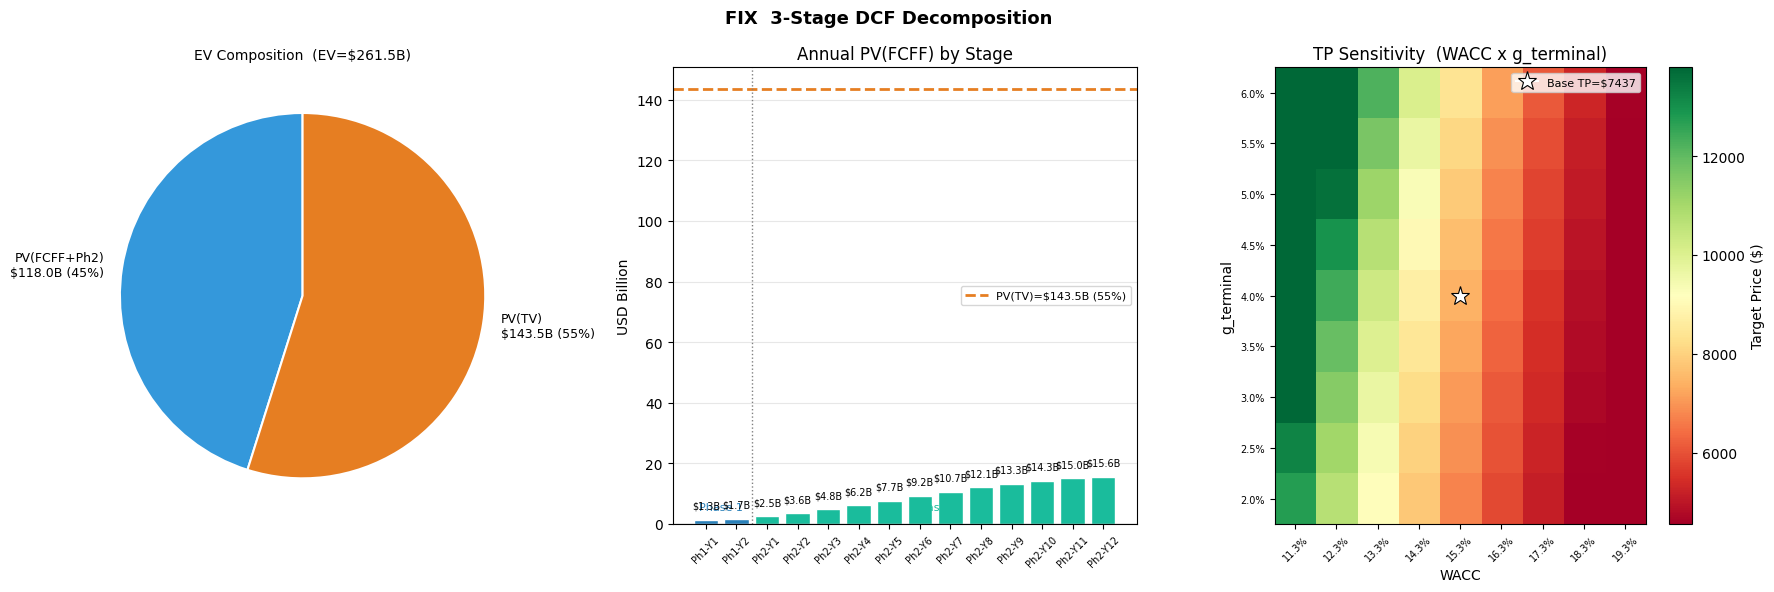

[Moat Analysis]
    ROIC (TTM)    : 50.61%
    WACC          : 15.28%
    EVA spread    : +35.33%
    Moat grade    : Narrow moat
    AR(1) rho     : 0.875
    Phase2 period : 12 yr


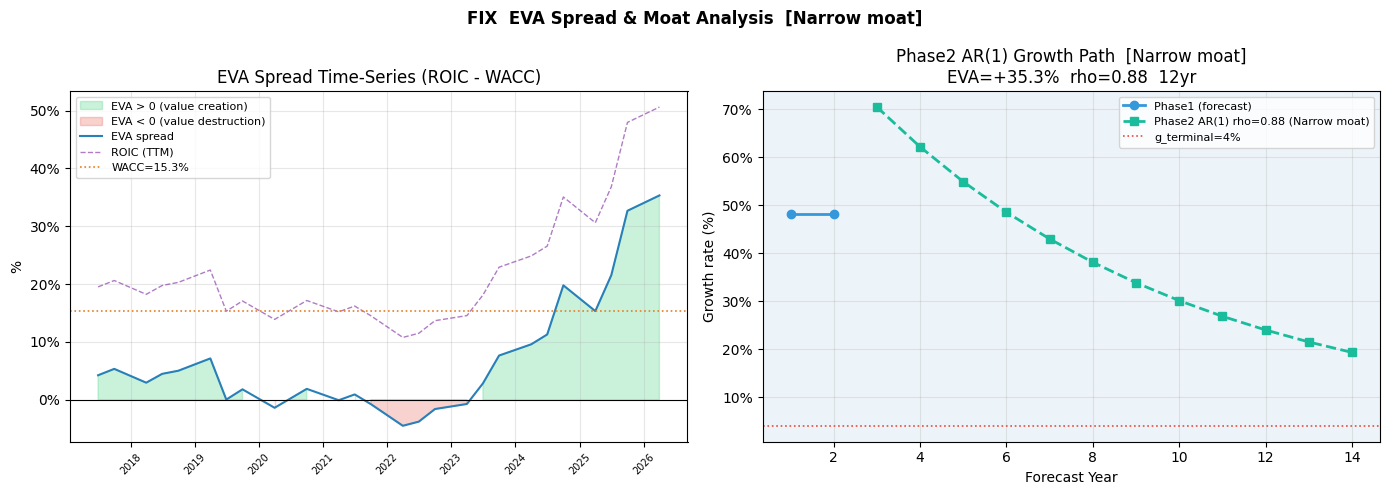

In [12]:
# ═══════════════════════════════════════════════════════════════
#  Cell 4.5 · 3-Stage DCF Decomposition & EVA Diagnostics
# ═══════════════════════════════════════════════════════════════

DIAG_TICKER = TEST_TICKER   # <- change ticker here

print(f"[Diagnostics] Running DCFModel for {DIAG_TICKER} ...")
_dm = DCFModel(ticker=DIAG_TICKER, engine=engine, verbose=True)
_dm.run()

v  = _dm.valuation
df = _dm.result_df.copy()
h  = _dm._fcff_history

wacc      = v["wacc"]
g_term    = v["g_terminal"]
ph1       = np.array(v["ph1_annual"])
ph2       = np.array(v["ph2_annual"])
g_ph2     = v["ph2_growth"]
all_ann   = np.array(v["all_annual"])
T_total   = v["t_total"]
fcff_last = v["fcff_last_annual"]
pv_fcff   = v["pv_fcff"]
tv        = v["terminal_value"]
pv_tv     = v["pv_tv"]
tv_wt     = v["tv_weight_pct"]
ev        = v["enterprise_value"]
net_debt  = v["net_debt"]
eq_val    = v["equity_value"]
shares    = v["shares"]
tp        = v["target_price"]
cp        = v["current_price"]

SEP = "=" * 66
print(f"\n{SEP}")
print(f"  {DIAG_TICKER}  3-Stage DCF Decomposition")
print(SEP)

print(f"\n[1] Discount rate")
print(f"    WACC          : {wacc*100:.4f}%")
print(f"    g_terminal    : {g_term*100:.4f}%")
print(f"    WACC - g      : {(wacc-g_term)*100:.4f}%")

print(f"\n[2] Phase 1 - Forecast FCFF (Year 1~{len(ph1)})")
cum = 0.0
for t, f in enumerate(ph1, 1):
    pv = f / (1+wacc)**t; cum += pv
    q0 = df["quarter"].iloc[(t-1)*4] if (t-1)*4 < len(df) else "?"
    q1 = df["quarter"].iloc[min(t*4-1, len(df)-1)]
    print(f"    Year {t} ({q0}~{q1})  FCFF={f/1e9:>8.3f}B  PV={pv/1e9:>8.3f}B  Cum={cum/1e9:>8.3f}B")

print(f"\n[3] Phase 2 - Growth convergence (Year {len(ph1)+1}~{len(ph1)+len(ph2)})")
for t_off, (f, g) in enumerate(zip(ph2, g_ph2), 1):
    yr = len(ph1) + t_off
    pv = f / (1+wacc)**yr; cum += pv
    print(f"    Year {yr}  g={g*100:>5.1f}%  FCFF={f/1e9:>8.3f}B  PV={pv/1e9:>8.3f}B  Cum={cum/1e9:>8.3f}B")

print(f"\n[4] Phase 3 - Terminal Value")
print(f"    Last annual FCFF : ${fcff_last/1e9:.3f}B")
print(f"    TV = {fcff_last/1e9:.3f}B x {1+g_term:.4f} / {wacc-g_term:.4f} = ${tv/1e9:.3f}B")
print(f"    PV(TV) = TV / (1+WACC)^{T_total} = ${pv_tv/1e9:.3f}B")

fcff_wt = pv_fcff / ev * 100 if ev != 0 else float("nan")
print(f"\n[5] EV Breakdown")
print(f"    PV(Phase1+2 FCFF) = ${pv_fcff/1e9:.3f}B  ({fcff_wt:.1f}%)")
print(f"    PV(TV)            = ${pv_tv/1e9:.3f}B  ({tv_wt:.1f}%)")
print(f"    Enterprise Value  = ${ev/1e9:.3f}B")

print(f"\n[6] Equity Bridge")
print(f"    EV ${ev/1e9:.3f}B  -  Net Debt ${net_debt/1e9:.3f}B  =  Equity ${eq_val/1e9:.3f}B")
tp_str = f"${tp:.2f}" if not np.isnan(tp) else "N/A"
up_str = f"{v['upside_pct']:.1f}%" if not np.isnan(v.get('upside_pct', float('nan'))) else "N/A"
print(f"    / {shares/1e6:.0f}M shares  =  TP {tp_str}  (Current ${cp:.2f}, Upside {up_str})")

print(f"\n{SEP}\n")

# ════════════════════════════════════════════════════════════════
# Visualisation  (1 x 3)
# ════════════════════════════════════════════════════════════════
_ev_positive = ev > 0 and pv_fcff > 0 and pv_tv > 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"{DIAG_TICKER}  3-Stage DCF Decomposition", fontsize=13, fontweight="bold")

# ── A: EV composition pie ────────────────────────────────────────
ax = axes[0]
if _ev_positive:
    ax.pie(
        [pv_fcff, pv_tv],
        labels=[f"PV(FCFF+Ph2)\n${pv_fcff/1e9:.1f}B ({fcff_wt:.0f}%)",
                f"PV(TV)\n${pv_tv/1e9:.1f}B ({tv_wt:.0f}%)"],
        colors=["#3498db", "#e67e22"],
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
        textprops=dict(fontsize=9),
    )
    ax.set_title(f"EV Composition  (EV=${ev/1e9:.1f}B)", fontsize=10)
else:
    ax.axis("off")
    msg  = f"EV = ${ev/1e9:.1f}B\n"
    msg += f"PV(FCFF) = ${pv_fcff/1e9:.1f}B\n"
    msg += f"PV(TV)   = ${pv_tv/1e9:.1f}B\n\n"
    msg += "Negative EV: pie chart\nnot applicable."
    ax.text(0.5, 0.5, msg, transform=ax.transAxes,
            ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#ffeeba", alpha=0.9))
    ax.set_title("EV Composition  (negative — chart skipped)", fontsize=10)

# ── B: Annual PV(FCFF) bar + PV(TV) line ────────────────────────
ax = axes[1]
yr_labels  = [f"Ph1-Y{i+1}" for i in range(len(ph1))] +              [f"Ph2-Y{i+1}" for i in range(len(ph2))]
pv_yr      = [f / (1+wacc)**(t+1) for t, f in enumerate(all_ann)]
colors_yr  = (["#2980b9"] * len(ph1)) + (["#1abc9c"] * len(ph2))

ax.bar(yr_labels, [v_ / 1e9 for v_ in pv_yr], color=colors_yr, edgecolor="white")
ax.axhline(pv_tv / 1e9, color="#e67e22", lw=2.0, ls="--",
           label=f"PV(TV)=${pv_tv/1e9:.1f}B ({tv_wt:.0f}%)")
ax.axvline(len(ph1) - 0.5, color="gray", lw=1, ls=":")

_ylim = ax.get_ylim()
_y_txt = _ylim[0] + (_ylim[1] - _ylim[0]) * 0.03
ax.text(len(ph1)/2 - 0.5, _y_txt, "Phase 1", ha="center", fontsize=8, color="#2980b9")
ax.text(len(ph1) + len(ph2)/2 - 0.5, _y_txt, "Phase 2", ha="center", fontsize=8, color="#1abc9c")

for i, val in enumerate(pv_yr):
    offset = abs(_ylim[1] - _ylim[0]) * 0.02
    va = "bottom" if val >= 0 else "top"
    y_pos = val/1e9 + (offset if val >= 0 else -offset)
    ax.text(i, y_pos, f"${val/1e9:.1f}B", ha="center", va=va, fontsize=7)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Annual PV(FCFF) by Stage")
ax.set_ylabel("USD Billion")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── C: WACC x g sensitivity heatmap ─────────────────────────────
ax = axes[2]
wacc_range = np.arange(max(wacc - 0.04, 0.04), wacc + 0.045, 0.01)
g_range    = np.arange(max(g_term - 0.02, 0.0), g_term + 0.025, 0.005)

tp_mat = np.full((len(g_range), len(wacc_range)), np.nan)
for ri, g_ in enumerate(g_range):
    for ci, w_ in enumerate(wacc_range):
        if w_ - g_ < 0.005:
            continue
        pv_f = sum(all_ann[t] / (1+w_)**(t+1) for t in range(T_total))
        tv_  = fcff_last * (1+g_) / (w_ - g_)
        ev_  = pv_f + tv_ / (1+w_)**T_total
        if shares > 0:
            tp_mat[ri, ci] = (ev_ - net_debt) / shares

_valid = tp_mat[~np.isnan(tp_mat)]
if len(_valid) > 0:
    im = ax.imshow(tp_mat, aspect="auto", cmap="RdYlGn",
                   vmin=np.nanpercentile(tp_mat, 10),
                   vmax=np.nanpercentile(tp_mat, 90),
                   origin="lower")
    plt.colorbar(im, ax=ax, label="Target Price ($)")
    ax.set_xticks(range(len(wacc_range)))
    ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_range], rotation=45, fontsize=7)
    ax.set_yticks(range(len(g_range)))
    ax.set_yticklabels([f"{g_*100:.1f}%" for g_ in g_range], fontsize=7)
    ax.set_xlabel("WACC")
    ax.set_ylabel("g_terminal")
    ax.set_title("TP Sensitivity  (WACC x g_terminal)")
    ci_cur = np.argmin(np.abs(wacc_range - wacc))
    ri_cur = np.argmin(np.abs(g_range    - g_term))
    tp_str2 = f"${tp:.0f}" if not np.isnan(tp) else "N/A"
    ax.plot(ci_cur, ri_cur, marker="*", ms=14, color="white",
            markeredgecolor="black", markeredgewidth=0.8,
            label=f"Base TP={tp_str2}")
    ax.legend(fontsize=8)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "All TP values invalid\n(negative FCFF / EV)",
            transform=ax.transAxes, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#ffeeba", alpha=0.9))
    ax.set_title("TP Sensitivity  (skipped)")

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# EVA spread time-series + Moat diagnostics
# ════════════════════════════════════════════════════════════════
eva_series = v.get("eva_series", [])
moat_label = v.get("moat_label", "N/A")
eva_spread = v.get("eva_spread", np.nan)
roic_val   = v.get("roic",       np.nan)
moat_rho   = v.get("moat_rho",   np.nan)
n_ph2      = v.get("n_phase2",   0)

print("[Moat Analysis]")
print(f"    ROIC (TTM)    : {roic_val*100:.2f}%" if not np.isnan(roic_val) else "    ROIC      : N/A")
print(f"    WACC          : {wacc*100:.2f}%")
print(f"    EVA spread    : {eva_spread*100:+.2f}%" if not np.isnan(eva_spread) else "    EVA spread : N/A")
print(f"    Moat grade    : {moat_label}")
print(f"    AR(1) rho     : {moat_rho:.3f}" if not np.isnan(moat_rho) else "    rho       : N/A")
print(f"    Phase2 period : {n_ph2} yr")

if eva_series:
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    fig2.suptitle(f"{DIAG_TICKER}  EVA Spread & Moat Analysis  [{moat_label}]",
                  fontsize=12, fontweight="bold")

    # ── EVA spread time-series ────────────────────────────────────
    ax = axes2[0]
    dates_e = [e["date"] for e in eva_series]
    spreads = [e["eva_spread"] * 100 for e in eva_series]
    roics   = [e["roic"]       * 100 for e in eva_series]

    ax.fill_between(dates_e, spreads, 0,
                    where=[s > 0 for s in spreads],
                    color="#2ecc71", alpha=0.25, label="EVA > 0 (value creation)")
    ax.fill_between(dates_e, spreads, 0,
                    where=[s <= 0 for s in spreads],
                    color="#e74c3c", alpha=0.25, label="EVA < 0 (value destruction)")
    ax.plot(dates_e, spreads, color="#2980b9", lw=1.5, label="EVA spread")
    ax.plot(dates_e, roics,   color="#8e44ad", lw=1.0, ls="--", alpha=0.7, label="ROIC (TTM)")
    ax.axhline(0,           color="black",   lw=0.8)
    ax.axhline(wacc * 100,  color="#e67e22", lw=1.2, ls=":", label=f"WACC={wacc*100:.1f}%")
    ax.set_title("EVA Spread Time-Series (ROIC - WACC)")
    ax.set_ylabel("%")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Moat grade + AR(1) growth path ───────────────────────────
    ax = axes2[1]

    # Phase 1 implied growth: Year2 FCFF / Year1 FCFF - 1
    if len(ph1) >= 2 and ph1[0] > 0:
        _g0 = float(np.clip(ph1[1] / ph1[0] - 1, -0.50, 0.80))
    else:
        _g0 = 0.10

    yrs_ph2 = list(range(3, 3 + n_ph2))

    # ★ FIX: ph2(FCFF 달러) 가 아니라 g_ph2(성장률) 를 사용해야 함
    g_ph2_arr = np.asarray(g_ph2, dtype=float)
    if len(g_ph2_arr) >= n_ph2:
        ph2_pct = [g * 100 for g in g_ph2_arr[:n_ph2]]
    else:
        ph2_pct = [_g0 * 100] * n_ph2

    ax.plot([1, 2], [_g0 * 100, _g0 * 100],
            "o-", color="#3498db", lw=2, label="Phase1 (forecast)")
    if yrs_ph2 and ph2_pct:
        ax.plot(yrs_ph2, ph2_pct, "s--", color="#1abc9c", lw=2,
                label=f"Phase2 AR(1) rho={moat_rho:.2f} ({moat_label})" if not np.isnan(moat_rho) else "Phase2")
    ax.axhline(GDP_GROWTH * 100, color="#e74c3c", lw=1.2, ls=":",
               label=f"g_terminal={GDP_GROWTH*100:.0f}%")

    moat_colors = {"Wide moat":   "#27ae60", "Narrow moat": "#2980b9",
                   "Some moat":   "#f39c12", "No moat":     "#e74c3c"}
    ax.set_facecolor(moat_colors.get(moat_label, "#95a5a6") + "15")

    eva_str = f"{eva_spread*100:+.1f}%" if not np.isnan(eva_spread) else "N/A"
    rho_str = f"{moat_rho:.2f}"         if not np.isnan(moat_rho)   else "N/A"
    ax.set_title(f"Phase2 AR(1) Growth Path  [{moat_label}]\n"
                 f"EVA={eva_str}  rho={rho_str}  {n_ph2}yr")
    ax.set_xlabel("Forecast Year")
    ax.set_ylabel("Growth rate (%)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("  [No EVA series — insufficient IS/BS data]")


## Cell 4.6 (NEW) · DCFModel 패치 적용 — V10 Excel Export 기능 주입

이 셀은 **한 번만 실행하면 됩니다** (커널 재시작 전까지 유효).

### 주입되는 메서드
1. `_estimate_phase2_growth` — 음수 g₀ 처리 개선 (사이클릭 침체 종목 대응)
2. `_fetch_v10_extras` — 10Y monthly close + FMP profile fetch
3. `export_v10_excel` — 9-sheet Excel workbook 생성

### 동작 방식
원본 `DCFModel` 클래스를 수정하지 않고 **monkey-patch** 방식으로 메서드를 추가합니다.
이 셀을 실행한 후의 모든 `DCFModel` 인스턴스는 새 메서드를 사용할 수 있습니다.


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 8.5 (NEW)  ·  DCFModel V10 Excel Export Patch
# ═══════════════════════════════════════════════════════════════════════
#  V9 DCF 노트북의 Cell 8 (DCFModel 클래스 정의) 바로 다음에 새 셀로 추가
#  하세요. 기존 Cell 8 을 수정하지 않고 monkey-patch 방식으로 3가지 기능을
#  DCFModel 에 주입합니다.
#
#  주입 내역
#    ① _estimate_phase2_growth  — 음수 g₀ + min(forecast,hist) 처리 (v9 → v9.2)
#    ② _fetch_v10_extras        — 10Y monthly close + profile fetch
#    ③ export_v10_excel         — 9-sheet workbook 빌드 & 저장
#
#  사용 예
#    model = DCFModel(ticker="NVDA", engine=engine, verbose=True).run()
#    out_path = model.export_v10_excel(out_dir="C:/reports")
# ═══════════════════════════════════════════════════════════════════════

import os, time
import requests
import numpy as np
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from datetime import datetime, timedelta
from pathlib import Path


# ════════════════════════════════════════════════════════════════════
#  Patch ①  ·  _estimate_phase2_growth  (음수 g₀ + min(forecast,hist), v9.2)
# ════════════════════════════════════════════════════════════════════
#  v9.1 → v9.2 변경 (NFLX 과대평가 이슈 대응)
#    · 과거 시계열 (g0_hist) 와 forecast (g0_fc) 를 모두 계산
#    · 양수 케이스: min(g0_hist, g0_fc) 채택 — forecast 가 상한 역할
#    · 음수 케이스: forecast 가 음수면 forecast 우선 — 사이클 신호 신뢰
#    · 부호 불일치: 더 보수적인 (작은) 값 채택
#
#  v9 → v9.1 (이전 변경, 그대로 유지)
#    1) g₀ 하한을 G_TERM(4%) → G_FLOOR_MIN(-20%) 으로 완화
#    2) Method 2 (12Q rolling TTM vs TTM-2) 추가 — 부호 반전 명시 처리
#    3) Method 3 (Phase 1 yr1/yr2) 도 부호 반전 케이스 분리
#    4) 최후 fallback 을 임의의 0.10 → G_TERM 으로 변경
#    5) AR(1) clip 하한을 G_TERM → G_FLOOR_MIN 으로 완화
#       → 음수 g₀ 가 g_term 으로 자연스럽게 회복되는 곡선 표현
#    6) ρ OLS 보정 시 양수 조건 제거 — 음수 annual 도 회귀에 포함
# ════════════════════════════════════════════════════════════════════

def _estimate_phase2_growth_v91(self, wacc: float) -> tuple:
    """
    Phase 2 AR(1) 성장 경로 — 음수 g₀ 허용 + 다중 fallback 체인 (v9.2)
    ─────────────────────────────────────────────────────────────
    v9.2 변경 (NFLX 과대평가 이슈 대응):
      · 과거 시계열 (g0_hist) 와 forecast (g0_fc) 를 모두 계산
      · 양수 케이스: min(g0_hist, g0_fc) 로 보수적 채택
        → 8Q-CAGR 가 비현실적으로 높을 때 forecast 가 상한 역할
      · 음수 케이스: forecast 가 음수면 forecast 우선
        → 사이클 침체를 모델이 정확히 잡았다는 신호로 신뢰
      · 부호 불일치: 더 보수적인 (작은) 값 채택

    반환: (g_path, moat_label, rho, n_years)
    """
    G_TERM       = self.gdp_growth
    G_FLOOR_MIN  = -0.20    # 사이클릭 침체 -20% 까지 허용
    G_CEIL       = 0.80

    h  = self._fcff_history

    # ════════════════════════════════════════════════════════
    # 1단계: 과거 시계열 기반 g₀ (g0_hist)
    #        Method 1 (8Q-CAGR) → Method 2 (12Q-TTM) 순서로 시도
    # ════════════════════════════════════════════════════════
    g0_hist = None
    g0_hist_method = None

    # ── Method 1: 8Q CAGR ─────────────────────────────────────
    if h is not None and len(h.dropna()) >= 8:
        h_c = h.dropna()
        f0, fl = float(h_c.iloc[-8]), float(h_c.iloc[-1])
        if f0 > 0 and fl > 0:
            cagr_q = (fl / f0) ** (4.0 / 8) - 1
            g0_hist = float(np.clip((1 + cagr_q) ** 4 - 1, G_FLOOR_MIN, G_CEIL))
            g0_hist_method = "8Q-CAGR"

    # ── Method 2: 12Q rolling TTM vs TTM-2 ──────────────────
    if g0_hist is None and h is not None and len(h.dropna()) >= 12:
        h_c = h.dropna()
        ttm_recent = float(h_c.iloc[-4:].sum())
        ttm_prior  = float(h_c.iloc[-8:-4].sum())
        if abs(ttm_prior) > 1e-6:
            if ttm_prior > 0 and ttm_recent > 0:
                g0_hist = ttm_recent / ttm_prior - 1
            elif ttm_prior > 0 and ttm_recent <= 0:
                g0_hist = ttm_recent / ttm_prior - 1
            elif ttm_prior < 0 and ttm_recent < 0:
                g0_hist = (ttm_recent - ttm_prior) / abs(ttm_prior)
            else:                                          # 적자→흑자
                g0_hist = G_TERM                           # 보수적
            g0_hist = float(np.clip(g0_hist, G_FLOOR_MIN, G_CEIL))
            g0_hist_method = "12Q-TTM"

    # ════════════════════════════════════════════════════════
    # 2단계: Phase 1 forecast 기반 g₀ (g0_fc) — 항상 계산 ★
    #        과거 method 가 성공해도 forecast 와 비교하기 위해
    # ════════════════════════════════════════════════════════
    g0_fc = None
    g0_fc_method = None

    if self.result_df is not None and not self.result_df.empty:
        fcff_q = self.result_df["fcff"].values
        if len(fcff_q) >= 4:
            yr1 = float(np.sum(fcff_q[:4]))
            yr2 = float(np.sum(fcff_q[4:8])) if len(fcff_q) >= 8 else yr1
            if abs(yr1) > 1e-6:
                if yr1 > 0 and yr2 > 0:
                    g0_fc = yr2 / yr1 - 1
                elif yr1 > 0 and yr2 <= 0:
                    g0_fc = yr2 / yr1 - 1                  # 자연스럽게 음수
                elif yr1 < 0 and yr2 < 0:
                    g0_fc = (yr2 - yr1) / abs(yr1)
                else:                                       # 적자→흑자
                    g0_fc = G_TERM
                g0_fc = float(np.clip(g0_fc, G_FLOOR_MIN, G_CEIL))
                g0_fc_method = "FC-yr1-yr2"

    # ════════════════════════════════════════════════════════
    # 3단계: g0_hist 와 g0_fc 결합 (★ v9.2 핵심 로직)
    # ════════════════════════════════════════════════════════
    if g0_hist is not None and g0_fc is not None:
        # 두 값 모두 양수 → min 채택 (옵션 1)
        if g0_hist > 0 and g0_fc > 0:
            if g0_hist > g0_fc:
                g0 = g0_fc
                g0_method = f"min({g0_hist_method}={g0_hist*100:.1f}%, FC={g0_fc*100:.1f}%) → FC"
            else:
                g0 = g0_hist
                g0_method = f"min({g0_hist_method}={g0_hist*100:.1f}%, FC={g0_fc*100:.1f}%) → {g0_hist_method}"
        # forecast 가 음수 → forecast 우선 (옵션 2)
        elif g0_fc <= 0:
            g0 = g0_fc
            g0_method = f"FC-priority (FC={g0_fc*100:.1f}% ≤ 0, hist={g0_hist*100:.1f}%)"
        # forecast 가 양수, hist 가 음수 → 더 보수적인 (작은) 값
        else:
            g0 = min(g0_hist, g0_fc)
            g0_method = f"min(hist={g0_hist*100:.1f}%, FC={g0_fc*100:.1f}%) → 부호 불일치 보수"
    elif g0_hist is not None:
        g0 = g0_hist
        g0_method = g0_hist_method
    elif g0_fc is not None:
        g0 = g0_fc
        g0_method = g0_fc_method
    else:
        # ── 최후 fallback ───────────────────────────────
        g0 = G_TERM
        g0_method = "default-G_TERM"

    # ── EVA → 해자 등급 → (ρ, 기간) ────────────────────────────
    eva  = self._compute_eva_spread(wacc)
    rho, n_years, moat_label = self._moat_to_rho_and_years(eva)

    # ── ρ OLS 보정 (★ 양수 조건 제거 — 음수 annual 도 포함) ──
    if h is not None and len(h.dropna()) >= 12:
        h_c = h.dropna()
        annual_vals = [float(h_c.iloc[y:y+4].sum())
                       for y in range(0, len(h_c) - len(h_c) % 4, 4)]
        if len(annual_vals) >= 4:
            g_hist = [(annual_vals[i] / annual_vals[i-1] - 1)
                      if abs(annual_vals[i-1]) > 1e-6 else 0.0
                      for i in range(1, len(annual_vals))]
            if len(g_hist) >= 3:
                yt = np.array([g - G_TERM for g in g_hist[1:]])
                xt = np.array([g - G_TERM for g in g_hist[:-1]])
                if np.dot(xt, xt) > 1e-10:
                    rho_ols = float(np.clip(
                        np.dot(xt, yt) / np.dot(xt, xt),
                        0.40, 0.92
                    ))
                    rho = float(np.clip(0.5 * rho + 0.5 * rho_ols, 0.40, 0.92))
                    if self.verbose:
                        log(self.ticker,
                            f"ρ 보정: EVA기반={rho:.3f}  OLS={rho_ols:.3f}  "
                            f"→ 혼합={rho:.3f}")

    # ── AR(1) 성장 경로 — clip 하한 완화 ──────────────────────
    g = g0
    g_path = []
    for _ in range(n_years):
        g = G_TERM + (g - G_TERM) * rho
        g_path.append(float(np.clip(g, G_FLOOR_MIN, G_CEIL)))

    if self.verbose:
        log(self.ticker,
            f"Phase2 [{moat_label}] ρ={rho:.3f} {n_years}년  "
            f"g0={g0:.1%} ({g0_method}) → {g_path[0]:.1%} ... {g_path[-1]:.1%}")

    self._eva_cache = {
        "eva_spread":   eva.get("eva_spread", np.nan),
        "roic":         eva.get("roic",        np.nan),
        "n_positive":   eva.get("n_positive",  0),
        "moat_label":   moat_label,
        "rho":          rho,
        "n_phase2":     n_years,
        "eva_series":   eva.get("eva_series",  []),
        "g0":           g0,           # 최종 채택된 g₀
        "g0_method":    g0_method,
        "g0_hist":      g0_hist,      # ★ 추가: 과거 시계열 기반
        "g0_hist_method": g0_hist_method,
        "g0_fc":        g0_fc,        # ★ 추가: forecast 기반
        "g0_fc_method": g0_fc_method,
    }
    return g_path, moat_label, rho, n_years


DCFModel._estimate_phase2_growth = _estimate_phase2_growth_v91


# ════════════════════════════════════════════════════════════════════
#  Patch ②  ·  _fetch_v10_extras  (Beta_Regression / Cost_of_Capital 용)
# ════════════════════════════════════════════════════════════════════

def _fetch_v10_extras(self, years: int = 10) -> None:
    """
    Excel export 에 필요한 추가 FMP 데이터 fetch.
    설정 후 self._monthly_prices, self._monthly_returns, self._profile 에 저장.
    """
    # 10Y monthly close — TICKER + ^GSPC
    end_dt   = datetime.today()
    start_dt = end_dt - timedelta(days=years * 365 + 30)

    def _hist_monthly(symbol: str) -> pd.Series:
        url = f"{FMP_BASE}/historical-price-full/{symbol}"
        params = {"apikey": self.api_key,
                  "from": start_dt.strftime("%Y-%m-%d"),
                  "to":   end_dt.strftime("%Y-%m-%d")}
        for attempt in range(3):
            try:
                r = requests.get(url, params=params, timeout=60)
                if r.status_code == 429:
                    time.sleep(2 + attempt); continue
                r.raise_for_status()
                hist = r.json().get("historical", [])
                if not hist:
                    return pd.Series(dtype=float)
                df = pd.DataFrame(hist)
                df["date"] = pd.to_datetime(df["date"])
                return (df.sort_values("date")
                          .set_index("date")["close"]
                          .resample("ME").last().dropna()
                          .tail(years * 12))
            except Exception as e:
                if attempt == 2:
                    if self.verbose:
                        log(self.ticker, f"monthly price fetch fail [{symbol}]: {e}")
                    return pd.Series(dtype=float)
                time.sleep(0.5 + attempt * 0.5)
        return pd.Series(dtype=float)

    ticker_monthly = _hist_monthly(self.ticker)
    sp500_monthly  = _hist_monthly("%5EGSPC")
    self._monthly_prices  = pd.DataFrame(
        {self.ticker: ticker_monthly, "SP500": sp500_monthly}
    ).dropna()
    self._monthly_returns = self._monthly_prices.pct_change().dropna()

    # Profile (현재 주가 + shares 도출용)
    self._profile = {}
    try:
        r = requests.get(f"{FMP_BASE}/profile/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=20)
        r.raise_for_status()
        data = r.json()
        if isinstance(data, list) and data:
            self._profile = data[0]
    except Exception as e:
        if self.verbose:
            log(self.ticker, f"profile fetch fail: {e}")

    if self.verbose:
        log(self.ticker,
            f"V10 extras: {len(self._monthly_returns)}개월 returns, "
            f"profile={'OK' if self._profile else 'N/A'}")


DCFModel._fetch_v10_extras = _fetch_v10_extras


# ════════════════════════════════════════════════════════════════════
#  Patch ③  ·  export_v10_excel  (9-sheet workbook 빌드)
# ════════════════════════════════════════════════════════════════════
#  V10 Extractor 의 sheet 구성을 그대로 따른다:
#    1. {TICKER}_FCFF       40Q hist + 8Q forecast (수식 기반)
#    2. Verification        YoY 성장률 교차검증
#    3. Phase2_LongTerm     Year 1-22 AR(1) decay
#    4. Moat_Comparison     4 등급 ρ 비교
#    5. Beta_Regression     10Y monthly returns + SLOPE/INTERCEPT/RSQ
#    6. Cost_of_Capital     CAPM Re + Rd + WACC
#    7. DCF_Valuation       Y1-17 PV + TV → Target Price
#    8. Sensitivity_TP      WACC×g, Beta×g, Re×g
#    9. Notes               방법론 / 가정 / 출처
# ════════════════════════════════════════════════════════════════════

# ── 색상 팔레트 (V10 LD1 과 동일) ────────────────────────────────
_NAVY, _TEAL, _GOLD       = "0D1B2A", "0E7C7B", "F4A261"
_ZEBRA, _FCST_BG, _ASSUMP = "F5F7FA", "FFF4D6", "FFF9C4"
_GREY, _BLUE              = "D9D9D9", "0000FF"
_PHASE1_BG, _PHASE2_BG, _PHASE3_BG = "E8F4F8", "FFF4D6", "F0E5C8"
_LINK_BG = "E0F0FF"

_FMT_INT, _FMT_PCT, _FMT_PCT3, _FMT_DEC, _FMT_PRICE = (
    "#,##0;[Red](#,##0);-", "0.00%", "0.000%", "0.0000", "$#,##0.00"
)
_THIN   = Side(style="thin", color=_GREY)
_BORDER = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)

# ── CAPM 가정값 (DCFModel 에는 없으므로 default) ─────────────────
_RF_DEFAULT, _RM_DEFAULT  = 0.045, 0.100
_BLUME_W_RAW, _BLUME_W_MARKET = 0.67, 0.33


# ── Style helpers ───────────────────────────────────────────────
def _set_label(cell, text, bold=False, italic=False, size=10, color="000000"):
    cell.value = text
    cell.font  = Font(name="Calibri", size=size, bold=bold, italic=italic, color=color)
    cell.alignment = Alignment(horizontal="left")
    cell.border = _BORDER

def _set_input(cell, value, fmt):
    cell.value = value
    cell.number_format = fmt
    cell.fill = PatternFill("solid", start_color=_ASSUMP)
    cell.font = Font(name="Calibri", size=10, color=_BLUE, bold=True)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _set_computed(cell, value, fmt, highlight=False, final=False):
    cell.value = value
    cell.number_format = fmt
    if final:
        cell.fill = PatternFill("solid", start_color=_NAVY)
        cell.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    elif highlight:
        cell.fill = PatternFill("solid", start_color=_GOLD)
        cell.font = Font(name="Calibri", size=11, bold=True)
    else:
        cell.fill = PatternFill("solid", start_color=_LINK_BG)
        cell.font = Font(name="Calibri", size=10)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _section_header(ws, row, text, span=6, color=_TEAL):
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=span)
    h = ws.cell(row=row, column=1, value=text)
    h.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    h.fill = PatternFill("solid", start_color=color)
    h.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[row].height = 24


# ── 과거 FCFF 구성요소 (Sales/OPM/EBIT/.../FCFF) — 40Q rebuild ────
def _build_hist_components(model, n_qtrs: int = 40) -> pd.DataFrame:
    """
    DCFModel._compute_historical_fcff 와 동일 로직이지만 모든 구성요소
    (Sales, OPM, EBIT, NOPAT, DA, CapEx, NWC, ΔNWC, FCFF) 를 캡처해서
    DataFrame 으로 반환. V10 main sheet 채우기용.
    """
    sales_act = model._sales_actual
    if sales_act is None or sales_act.empty:
        return pd.DataFrame()

    # tax/alpha/beta/gamma 재계산 (idempotent)
    tax = model.estimate_tax_rate()
    alpha, _ = model.estimate_ratio_coef("depreciationAndAmortization", "D&A")
    beta,  _ = model.estimate_ratio_coef("capitalExpenditure", "CapEx", take_abs=True)
    gamma, _ = model.estimate_nwc_coef()

    inc = model._inc.set_index("date")
    rows = []
    first_sales = float(sales_act.iloc[0])
    prev_nwc = gamma * first_sales

    for dt, sales in sales_act.items():
        if pd.isna(sales) or sales <= 0:
            prev_nwc = gamma * sales if pd.notna(sales) else prev_nwc
            continue
        op_v  = inc["operatingIncome"].get(dt, np.nan) if "operatingIncome" in inc.columns else np.nan
        rev_v = inc["revenue"].get(dt, np.nan) if "revenue" in inc.columns else np.nan
        opm = (float(op_v) / float(rev_v)
               if (pd.notna(op_v) and pd.notna(rev_v) and float(rev_v) > 0) else np.nan)
        if pd.isna(opm):
            prev_nwc = gamma * sales; continue
        ebit  = sales * opm
        nopat = ebit * (1 - tax)
        da    = alpha * sales
        capex = beta * sales
        nwc   = gamma * sales
        dnwc  = nwc - prev_nwc
        prev_nwc = nwc
        fcff = nopat + da - capex - dnwc
        rows.append({
            "date": dt,
            "quarter": f"{dt.year}Q{dt.quarter}",
            "Sales": sales, "OPM": opm, "EBIT": ebit, "NOPAT": nopat,
            "DA": da, "CapEx": capex, "NWC": nwc, "ΔNWC": dnwc, "FCFF": fcff,
        })
    if not rows:
        return pd.DataFrame()
    out = pd.DataFrame(rows).tail(n_qtrs).reset_index(drop=True)
    return out


# ── Sheet builders (model 인스턴스를 인자로 받음) ─────────────────

def _build_main(model, wb, hist_df, fc_df, ticker):
    ws = wb.active
    ws.title = f"{ticker}_FCFF"

    ws.merge_cells("A1:J1")
    t = ws["A1"]
    t.value = f"{ticker} — Quarterly FCFF Components & 8-Quarter Forecast"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    headers = ["Quarter","Sales","OPM","EBIT","NOPAT","D&A","CapEx","NWC","ΔNWC","FCFF"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    N_HIST = len(hist_df)

    # 과거 (rows 3..2+N_HIST)
    for i in range(N_HIST):
        rd = hist_df.iloc[i]
        r = i + 3
        ws.cell(row=r, column=1, value=rd["quarter"]).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=float(rd["Sales"])).number_format = _FMT_INT
        ws.cell(row=r, column=3, value=float(rd["OPM"])).number_format  = _FMT_PCT
        ws.cell(row=r, column=4, value=float(rd["EBIT"])).number_format = _FMT_INT
        ws.cell(row=r, column=5, value=float(rd["NOPAT"])).number_format= _FMT_INT
        ws.cell(row=r, column=6, value=float(rd["DA"])).number_format   = _FMT_INT
        ws.cell(row=r, column=7, value=float(rd["CapEx"])).number_format= _FMT_INT
        ws.cell(row=r, column=8, value=float(rd["NWC"])).number_format  = _FMT_INT
        if i == 0:
            for c_idx in (9, 10):
                cc = ws.cell(row=r, column=c_idx, value="–")
                cc.alignment = Alignment(horizontal="center")
        else:
            ws.cell(row=r, column=9,  value=f"=H{r}-H{r-1}").number_format = _FMT_INT
            ws.cell(row=r, column=10, value=f"=E{r}+F{r}-G{r}-I{r}").number_format = _FMT_INT
        fill = PatternFill("solid", start_color=_ZEBRA) if i % 2 == 0 else None
        for col in range(1, 11):
            cc = ws.cell(row=r, column=col)
            cc.border = _BORDER
            cc.font = Font(name="Calibri", size=10)
            if fill: cc.fill = fill

    # 향후 8Q (수식 — 가정셀 참조)
    fcst_top  = Side(style="medium", color=_GOLD)
    fcst_fill = PatternFill("solid", start_color=_FCST_BG)
    fcst_start_row = 3 + N_HIST

    for j in range(min(8, len(fc_df))):
        fc_label = fc_df.iloc[j].get("quarter", f"F{j+1}")
        try:
            fq_num = int(str(fc_label)[-1])
        except Exception:
            fq_num = ((j % 4) + 1)
        r = fcst_start_row + j
        prev_yr_row = r - 4
        growth_row  = 3 + fq_num   # Q1→4, Q2→5, Q3→6, Q4→7

        ws.cell(row=r, column=1, value=str(fc_label)).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=f"=B{prev_yr_row}*(1+$N${growth_row})").number_format = _FMT_INT
        ws.cell(row=r, column=3, value="=$M$11").number_format = _FMT_PCT
        ws.cell(row=r, column=4, value=f"=B{r}*C{r}").number_format = _FMT_INT
        ws.cell(row=r, column=5, value=f"=D{r}*(1-$M$12)").number_format = _FMT_INT
        ws.cell(row=r, column=6, value=f"=B{r}*$M$13").number_format = _FMT_INT
        ws.cell(row=r, column=7, value=f"=B{r}*$M$14").number_format = _FMT_INT
        ws.cell(row=r, column=8, value=f"=B{r}*$M$15").number_format = _FMT_INT
        ws.cell(row=r, column=9, value=f"=H{r}-H{r-1}").number_format = _FMT_INT
        ws.cell(row=r, column=10, value=f"=E{r}+F{r}-G{r}-I{r}").number_format = _FMT_INT

        for col in range(1, 11):
            cc = ws.cell(row=r, column=col)
            cc.border = Border(left=_THIN, right=_THIN, bottom=_THIN,
                               top=fcst_top if j == 0 else _THIN)
            cc.fill = fcst_fill
            cc.font = Font(name="Calibri", size=10)

    # ── 가정셀 (M11:M15) + Q별 성장률 (N4:N7) ──────────────────
    # YoY geometric mean by quarter number
    def _quarterly_yoy(df):
        g = {1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}
        df = df.copy()
        df["q_num"] = df["quarter"].astype(str).str[-1].astype(int)
        for q in [1, 2, 3, 4]:
            sq = df.loc[df["q_num"] == q].sort_values("quarter")["Sales"].values
            if len(sq) >= 2:
                yoy = sq[1:] / sq[:-1] - 1
                g[q] = float(np.prod(1 + yoy)) ** (1.0 / len(yoy)) - 1
        return g

    growth = _quarterly_yoy(hist_df)

    # M열 가정값 (오른쪽에 노란 input 셀)
    _set_label(ws.cell(row=10, column=12), "Forecast Assumptions (editable)", bold=True)
    ws.cell(row=10, column=12).fill = PatternFill("solid", start_color=_TEAL)
    ws.cell(row=10, column=12).font = Font(bold=True, color="FFFFFF")

    fc_assumptions = {
        "OPM":       float(fc_df["opm_forecast"].mean()) if "opm_forecast" in fc_df.columns else 0.10,
        "Tax rate":  float(fc_df["tax_rate"].iloc[0])    if "tax_rate"     in fc_df.columns else 0.21,
        "D&A / Sales":   float(fc_df["da"].mean()    / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.05,
        "CapEx / Sales": float(fc_df["capex"].mean()  / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.07,
        "NWC / Sales":   float(fc_df["nwc"].mean()    / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.15,
    }
    for i, (k, v) in enumerate(fc_assumptions.items(), start=11):
        _set_label(ws.cell(row=i, column=12), k)
        _set_input(ws.cell(row=i, column=13), v, _FMT_PCT)

    # N열 분기별 성장률
    _set_label(ws.cell(row=2, column=14), "Quarterly YoY Growth (geo)", bold=True)
    ws.cell(row=2, column=14).fill = PatternFill("solid", start_color=_TEAL)
    ws.cell(row=2, column=14).font = Font(bold=True, color="FFFFFF")
    ws.merge_cells("N2:N3")
    for q in [1, 2, 3, 4]:
        _set_label(ws.cell(row=3 + q, column=13), f"Q{q}")
        _set_input(ws.cell(row=3 + q, column=14),
                   growth[q] if not np.isnan(growth[q]) else 0.0, _FMT_PCT3)

    # 컬럼 폭
    ws.column_dimensions["A"].width = 12
    for col in "BCDEFGHIJ":
        ws.column_dimensions[col].width = 14
    ws.column_dimensions["L"].width = 22
    ws.column_dimensions["M"].width = 14
    ws.column_dimensions["N"].width = 14
    ws.freeze_panes = "B3"


def _build_verification(wb, hist_df, ticker):
    ws = wb.create_sheet("Verification")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — YoY Growth Cross-Check (geo mean by quarter)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    headers = ["Quarter Number", "# Observations", "Geo. Mean YoY", "Arith. Mean YoY"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=3, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    df = hist_df.copy()
    df["q_num"] = df["quarter"].astype(str).str[-1].astype(int)
    for q in [1, 2, 3, 4]:
        sq = df.loc[df["q_num"] == q].sort_values("quarter")["Sales"].values
        r = 3 + q
        if len(sq) >= 2:
            yoy = sq[1:] / sq[:-1] - 1
            arith = float(np.mean(yoy))
            geo   = float(np.prod(1 + yoy)) ** (1.0 / len(yoy)) - 1
            n = len(yoy)
        else:
            arith, geo, n = np.nan, np.nan, 0
        _set_label(ws.cell(row=r, column=1), f"Q{q}")
        ws.cell(row=r, column=2, value=n).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2).border = _BORDER
        if n > 0:
            _set_computed(ws.cell(row=r, column=3), geo,   _FMT_PCT3)
            _set_computed(ws.cell(row=r, column=4), arith, _FMT_PCT3)
        else:
            ws.cell(row=r, column=3, value="N/A").alignment = Alignment(horizontal="center")
            ws.cell(row=r, column=4, value="N/A").alignment = Alignment(horizontal="center")

    for col in "ABCD":
        ws.column_dimensions[col].width = 22


def _build_phase2(wb, model, ticker):
    """Phase2_LongTerm — Year 1-22 (Phase 1 + 2 + 3 padding)."""
    ws = wb.create_sheet("Phase2_LongTerm")

    val = model.valuation
    ph1 = val.get("ph1_annual", [])
    ph2 = val.get("ph2_annual", [])
    g_path = val.get("ph2_growth", [])
    rho     = val.get("moat_rho", 0.83)
    g_term  = val.get("g_terminal", 0.04)
    g0      = getattr(model, "_eva_cache", {}).get("g0", np.nan)
    g0_method = getattr(model, "_eva_cache", {}).get("g0_method", "n/a")
    moat = val.get("moat_label", "N/A")
    n_ph2 = len(ph2)

    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — Phase 2 Long-Term FCFF (AR(1) decay → g_term)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    # Inputs
    _section_header(ws, 3, "Inputs (editable)", 6, _TEAL)
    _set_label(ws.cell(row=4, column=1), "ρ (AR(1) persistence)")
    _set_input(ws.cell(row=4, column=2), float(rho), _FMT_DEC)
    _set_label(ws.cell(row=5, column=1), "g₀ (initial growth)")
    _set_input(ws.cell(row=5, column=2),
               float(g0) if not np.isnan(g0) else 0.0, _FMT_PCT)
    _set_label(ws.cell(row=6, column=1), "g_term (terminal growth)")
    _set_input(ws.cell(row=6, column=2), float(g_term), _FMT_PCT)
    _set_label(ws.cell(row=7, column=1), "Phase 2 horizon (years)")
    _set_input(ws.cell(row=7, column=2), int(n_ph2), "0")

    _set_label(ws.cell(row=9, column=1), f"Moat:  {moat}    g₀ method:  {g0_method}",
               italic=True, color="595959")

    # Year-by-Year table
    _section_header(ws, 12, "Year-by-Year FCFF Schedule (Year 1-22)", 6, _TEAL)
    for c, h in enumerate(["Year","Cal. Year","Phase","g(t)","FCFF","Notes"], 1):
        cell = ws.cell(row=13, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    # 시작 연도 — 예측 첫 분기에서 추출
    try:
        BASE_YEAR = int(str(model.result_df["quarter"].iloc[0])[:4])
    except Exception:
        BASE_YEAR = datetime.now().year

    ph1_growth = []
    if len(ph1) >= 2 and ph1[0] != 0:
        ph1_growth = [np.nan, ph1[1]/ph1[0] - 1]
    elif len(ph1) >= 1:
        ph1_growth = [np.nan]

    # Year 1-2: Phase 1 (DB forecast)
    for y in range(min(2, len(ph1))):
        r = 14 + y
        ws.cell(row=r, column=1, value=y+1).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=BASE_YEAR + y).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=3, value="Phase 1").alignment = Alignment(horizontal="center")
        if y < len(ph1_growth) and not np.isnan(ph1_growth[y]):
            _set_computed(ws.cell(row=r, column=4), float(ph1_growth[y]), _FMT_PCT)
        else:
            ws.cell(row=r, column=4, value="—").alignment = Alignment(horizontal="center")
        _set_computed(ws.cell(row=r, column=5), float(ph1[y]), _FMT_INT)
        ws.cell(row=r, column=6, value="Forecast 8Q sum").font = Font(italic=True, size=9, color="595959")
        for col in range(1, 7):
            ws.cell(row=r, column=col).fill = PatternFill("solid", start_color=_PHASE1_BG)
            ws.cell(row=r, column=col).border = _BORDER

    # Year 3 ~ Year (2+n_ph2): Phase 2 (AR(1))
    last_fcff = float(ph1[-1]) if ph1 else 1.0
    for j in range(n_ph2):
        y_idx = 2 + j
        r = 14 + y_idx
        ws.cell(row=r, column=1, value=y_idx+1).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=BASE_YEAR + y_idx).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=3, value="Phase 2").alignment = Alignment(horizontal="center")
        _set_computed(ws.cell(row=r, column=4), float(g_path[j]) if j < len(g_path) else np.nan, _FMT_PCT)
        _set_computed(ws.cell(row=r, column=5), float(ph2[j]),     _FMT_INT)
        ws.cell(row=r, column=6, value=f"AR(1) decay  ρ={rho:.3f}").font = Font(italic=True, size=9, color="595959")
        for col in range(1, 7):
            ws.cell(row=r, column=col).fill = PatternFill("solid", start_color=_PHASE2_BG)
            ws.cell(row=r, column=col).border = _BORDER
        last_fcff = float(ph2[j])

    # Phase 3 padding (다음해 ~ Year 22) — TV growth 적용
    last_year_done = 2 + n_ph2
    for y_idx in range(last_year_done, 22):
        r = 14 + y_idx
        last_fcff = last_fcff * (1 + g_term)
        ws.cell(row=r, column=1, value=y_idx+1).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=BASE_YEAR + y_idx).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=3, value="Phase 3").alignment = Alignment(horizontal="center")
        _set_computed(ws.cell(row=r, column=4), float(g_term), _FMT_PCT)
        _set_computed(ws.cell(row=r, column=5), last_fcff,     _FMT_INT)
        ws.cell(row=r, column=6, value="Terminal growth").font = Font(italic=True, size=9, color="595959")
        for col in range(1, 7):
            ws.cell(row=r, column=col).fill = PatternFill("solid", start_color=_PHASE3_BG)
            ws.cell(row=r, column=col).border = _BORDER

    ws.column_dimensions["A"].width = 8
    ws.column_dimensions["B"].width = 12
    ws.column_dimensions["C"].width = 12
    ws.column_dimensions["D"].width = 12
    ws.column_dimensions["E"].width = 18
    ws.column_dimensions["F"].width = 28


def _build_moat(wb, model, ticker):
    ws = wb.create_sheet("Moat_Comparison")
    ws.merge_cells("A1:H1")
    t = ws["A1"]
    t.value = f"{ticker} — Moat Classification & ρ Comparison"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    _section_header(ws, 3, "EVA Spread (current snapshot)", 8, _TEAL)
    val = model.valuation
    eva_cache = getattr(model, "_eva_cache", {})
    rows_eva = [
        ("ROIC (TTM)",                val.get("roic", np.nan),       _FMT_PCT),
        ("WACC",                      val.get("wacc", np.nan),       _FMT_PCT),
        ("EVA Spread = ROIC − WACC",  val.get("eva_spread", np.nan), _FMT_PCT),
        ("Positive quarters / 20Q",   eva_cache.get("n_positive", 0), "0"),
        ("Current Moat label",         val.get("moat_label", "N/A"),  None),
        ("ρ (AR(1) persistence) — selected", val.get("moat_rho", np.nan), _FMT_DEC),
        ("Phase 2 horizon (years)",   val.get("n_phase2", 0),        "0"),
    ]
    for i, (label, v, fmt) in enumerate(rows_eva):
        r = 5 + i
        _set_label(ws.cell(row=r, column=1), label)
        if isinstance(v, str):
            ws.cell(row=r, column=2, value=v).alignment = Alignment(horizontal="right")
        elif fmt is None:
            ws.cell(row=r, column=2, value=v).alignment = Alignment(horizontal="right")
        else:
            cv = ws.cell(row=r, column=2, value=v if (v is not None and not (isinstance(v, float) and np.isnan(v))) else "N/A")
            if not isinstance(cv.value, str):
                cv.number_format = fmt
                cv.fill = PatternFill("solid", start_color=_LINK_BG)
            cv.alignment = Alignment(horizontal="right")
            cv.border = _BORDER

    _section_header(ws, 14, "Moat Tier Reference (Damodaran / Mauboussin)", 8, _GOLD)
    headers = ["Moat", "EVA Spread Threshold", "n_positive Threshold",
               "ρ (decay)", "Phase 2 Years", "Approx. half-life (yrs)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=16, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    tiers = [
        ("Wide moat",   "> 15%",  "≥ 15", 0.90, 15),
        ("Narrow moat", "> 8%",   "≥ 12", 0.83, 12),
        ("Some moat",   "> 3%",   "≥ 8",  0.75,  8),
        ("No moat",     "≤ 3%",   "< 8",  0.60,  5),
    ]
    cur_moat = val.get("moat_label", "N/A")
    for i, (lbl, sp, npos, rho_v, yr) in enumerate(tiers):
        r = 17 + i
        is_current = (lbl == cur_moat)
        bg = _GOLD if is_current else _ZEBRA
        for col, v in enumerate([lbl, sp, npos, rho_v, yr,
                                 round(np.log(0.5)/np.log(rho_v), 1)], 1):
            cc = ws.cell(row=r, column=col, value=v)
            cc.font = Font(bold=is_current)
            cc.fill = PatternFill("solid", start_color=bg)
            cc.alignment = Alignment(horizontal="center")
            cc.border = _BORDER
            if isinstance(v, float):
                cc.number_format = _FMT_DEC

    ws.merge_cells("A22:H22")
    ws.cell(row=22, column=1,
            value="  ★ 굵은 행이 현재 종목의 등급. ρ → Phase 2 기간 매핑은 EVA spread 의 지속성에 비례.").font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 36
    for col in "BCDEFGH":
        ws.column_dimensions[col].width = 18


def _build_beta(wb, model, ticker):
    """10Y monthly returns + SLOPE/INTERCEPT/RSQ + Blume."""
    br = wb.create_sheet("Beta_Regression")
    br.merge_cells("A1:F1")
    t = br["A1"]
    t.value = f"{ticker} — Beta Estimation: 10-Year Monthly Returns vs S&P 500"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    br.row_dimensions[1].height = 32

    for c, h in enumerate(["Date", f"{ticker} Price", "S&P 500",
                            f"{ticker} Return", "S&P 500 Return"], 1):
        cell = br.cell(row=3, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    prices = getattr(model, "_monthly_prices", pd.DataFrame())
    if prices is None or prices.empty or len(prices) < 12:
        br.cell(row=4, column=1, value="(monthly price data unavailable)").font = Font(italic=True, color="595959")
        br.column_dimensions["A"].width = 36
        for col in "BCDE": br.column_dimensions[col].width = 14
        return None, None

    N = len(prices)
    for i, (date, row) in enumerate(prices.iterrows()):
        r = 4 + i
        br.cell(row=r, column=1, value=date.date()).number_format = "yyyy-mm"
        br.cell(row=r, column=2, value=float(row[ticker])).number_format = "0.00"
        br.cell(row=r, column=3, value=float(row["SP500"])).number_format = "0.00"
        if i > 0:
            br.cell(row=r, column=4, value=f"=B{r}/B{r-1}-1").number_format = _FMT_PCT3
            br.cell(row=r, column=5, value=f"=C{r}/C{r-1}-1").number_format = _FMT_PCT3
        for c in range(1, 6):
            br.cell(row=r, column=c).border = _BORDER

    RET_START = 5
    RET_END   = 4 + N - 1
    RES_HDR   = N + 5
    BETA_R    = RES_HDR + 1
    ALPHA_R   = RES_HDR + 2
    BLUME_R   = RES_HDR + 14

    _section_header(br, RES_HDR, "Regression Statistics — OLS Beta Estimation", 5, _TEAL)
    for offset, label, formula, fmt, hl in [
        (1, "Beta (slope)",                       f"=SLOPE(D{RET_START}:D{RET_END},E{RET_START}:E{RET_END})",     "0.0000", True),
        (2, "Intercept (alpha, monthly)",         f"=INTERCEPT(D{RET_START}:D{RET_END},E{RET_START}:E{RET_END})", "0.000%", False),
        (3, "Annualized alpha (×12)",             f"=B{ALPHA_R}*12",                                              "0.00%",  False),
        (4, "R² (coefficient of determination)",  f"=RSQ(D{RET_START}:D{RET_END},E{RET_START}:E{RET_END})",       "0.000",  False),
        (5, "Number of observations",             f"=COUNT(D{RET_START}:D{RET_END})",                             "0",      False),
    ]:
        c1 = br.cell(row=RES_HDR + offset, column=1, value=label)
        c1.font = Font(name="Calibri", size=10, bold=hl)
        c1.alignment = Alignment(horizontal="left")
        c1.border = _BORDER
        c2 = br.cell(row=RES_HDR + offset, column=2, value=formula)
        _set_computed(c2, formula, fmt, highlight=hl)

    _section_header(br, RES_HDR + 7, "Blume Adjustment — Mean-Reversion of Beta", 5, _TEAL)
    br.merge_cells(f"A{RES_HDR + 8}:E{RES_HDR + 8}")
    note = br.cell(row=RES_HDR + 8, column=1,
                   value="  Beta_Blume = w_raw × Beta_raw + w_market × 1.0  (industry standard: 2/3, 1/3)")
    note.font = Font(italic=True, size=10, color="595959")
    _set_label(br.cell(row=RES_HDR + 10, column=1), "Weight on raw Beta (w_raw)")
    _set_input(br.cell(row=RES_HDR + 10, column=2), _BLUME_W_RAW, _FMT_DEC)
    _set_label(br.cell(row=RES_HDR + 11, column=1), "Weight on market Beta = 1 (w_market)")
    _set_input(br.cell(row=RES_HDR + 11, column=2), _BLUME_W_MARKET, _FMT_DEC)
    bl = br.cell(row=BLUME_R, column=1, value="Beta (Blume-adjusted) ★")
    bl.font = Font(bold=True); bl.fill = PatternFill("solid", start_color=_GOLD); bl.border = _BORDER
    bv = br.cell(row=BLUME_R, column=2, value=f"=B{RES_HDR + 10}*B{BETA_R}+B{RES_HDR + 11}*1")
    bv.number_format = "0.0000"
    bv.fill = PatternFill("solid", start_color=_NAVY)
    bv.font = Font(size=11, bold=True, color="FFFFFF")
    bv.alignment = Alignment(horizontal="right"); bv.border = _BORDER

    br.column_dimensions["A"].width = 36
    for col in "BCDE": br.column_dimensions[col].width = 14
    br.freeze_panes = "A4"
    return BETA_R, BLUME_R


def _build_coc(wb, model, ticker, BETA_R, BLUME_R):
    cc = wb.create_sheet("Cost_of_Capital")
    cc.merge_cells("A1:F1")
    t = cc["A1"]
    t.value = f"{ticker} — Cost of Capital: Re (CAPM) + Rd + WACC"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    cc.row_dimensions[1].height = 32

    val = model.valuation
    inc = model._inc; bs = model._bs

    # WACC chain inputs
    interest_ttm = 0.0
    if "interestExpense" in inc.columns:
        interest_ttm = float(pd.to_numeric(inc["interestExpense"], errors="coerce").abs().tail(4).sum())
    total_debt = 0.0
    if "totalDebt" in bs.columns:
        s = pd.to_numeric(bs["totalDebt"], errors="coerce").dropna()
        total_debt = float(s.iloc[-1]) if len(s) else 0.0
    cash = 0.0
    if "cashAndCashEquivalents" in bs.columns:
        s = pd.to_numeric(bs["cashAndCashEquivalents"], errors="coerce").dropna()
        cash = float(s.iloc[-1]) if len(s) else 0.0

    # Shares: profile.mktCap/price 우선, fallback model.valuation["shares"]
    profile = getattr(model, "_profile", {}) or {}
    shares_profile = 0.0
    if profile.get("mktCap") and profile.get("price"):
        try:
            shares_profile = float(profile["mktCap"]) / float(profile["price"])
        except Exception:
            shares_profile = 0.0
    shares_model = float(val.get("shares") or 0.0) if not (isinstance(val.get("shares"), float) and np.isnan(val.get("shares"))) else 0.0
    shares_use   = shares_profile if shares_profile > 0 else shares_model

    current_price = float(val.get("current_price") or 0.0)
    if (not current_price) and profile.get("price"):
        try: current_price = float(profile["price"])
        except Exception: pass

    tax = float(val.get("wacc")) if False else float(model.estimate_tax_rate())
    wacc_db = float(val.get("wacc", np.nan)) if val else np.nan

    # Section A — Re
    _section_header(cc, 3, "Section A — Cost of Equity (Re) via CAPM", 6, _TEAL)
    cc.merge_cells("A4:F4")
    cc.cell(row=4, column=1, value="  Formula:  Re = Rf + Beta × (Rm − Rf)").font = Font(italic=True, size=10, color="595959")

    beta_raw_ref   = f"=Beta_Regression!B{BETA_R}"   if BETA_R   else 1.0
    beta_blume_ref = f"=Beta_Regression!B{BLUME_R}"  if BLUME_R  else 1.0

    spec = [
        (6,  "Risk-free rate (Rf, 10Y Treasury)",      _RF_DEFAULT,         _FMT_PCT, "input"),
        (7,  "Expected market return (Rm)",            _RM_DEFAULT,         _FMT_PCT, "input"),
        (8,  "  Market Risk Premium (MRP) = Rm − Rf",  "=B7-B6",            _FMT_PCT, "comp"),
        (10, "Beta (raw, from Beta_Regression)",       beta_raw_ref,        "0.0000", "comp"),
        (11, "Beta (Blume-adjusted)",                  beta_blume_ref,      "0.0000", "comp"),
        (13, "Re (using raw Beta)",                    "=B6+B10*B8",        _FMT_PCT, "comp"),
        (14, "Re (using Blume Beta) ★",                "=B6+B11*B8",        _FMT_PCT, "highlight"),
    ]
    for r, label, val_, fmt, kind in spec:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if kind == "input":
            _set_input(c, val_, fmt)
        elif kind == "highlight":
            _set_computed(c, val_, fmt, highlight=True)
        else:
            _set_computed(c, val_, fmt)

    # Section B — Rd
    _section_header(cc, 17, "Section B — Cost of Debt (Rd)", 6, _TEAL)
    cc.merge_cells("A18:F18")
    cc.cell(row=18, column=1, value="  Rd_pretax = Interest Expense / Total Debt  →  Rd_aftertax = Rd_pretax × (1 − T)").font = Font(italic=True, size=10, color="595959")
    rd_spec = [
        (20, "Interest Expense (TTM, last 4Q)",     interest_ttm,                _FMT_INT, "input"),
        (21, "Total Debt (latest quarter)",         total_debt,                  _FMT_INT, "input"),
        (23, "  Rd pre-tax",                        "=IFERROR(B20/B21,0)",       _FMT_PCT, "comp"),
        (24, "Effective tax rate",                  tax,                         _FMT_PCT, "input"),
        (26, "Rd after-tax = Rd_pretax × (1 − T) ★","=IFERROR(B23*(1-B24),0)",   _FMT_PCT, "highlight"),
    ]
    for r, label, val_, fmt, kind in rd_spec:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if kind == "input":     _set_input(c, val_, fmt)
        elif kind == "highlight": _set_computed(c, val_, fmt, highlight=True)
        else:                   _set_computed(c, val_, fmt)

    # Section C — Capital Structure
    _section_header(cc, 29, "Section C — Capital Structure (Market Values)", 6, _TEAL)
    cs_spec = [
        (31, "Current stock price",                 current_price,        _FMT_PRICE, "input"),
        (32, "Shares outstanding",                  shares_use,           _FMT_INT,   "input"),
        (33, "  Market Cap (E) = Price × Shares",   "=B31*B32",           _FMT_INT,   "comp"),
        (34, "  Total Debt (D, linked from B21)",   "=B21",               _FMT_INT,   "comp"),
        (35, "  Total Capital (V) = E + D",         "=B33+B34",           _FMT_INT,   "comp"),
        (37, "  E/V (equity weight)",               "=IFERROR(B33/B35,0)",_FMT_PCT,   "comp"),
        (38, "  D/V (debt weight)",                 "=IFERROR(B34/B35,0)",_FMT_PCT,   "comp"),
        (41, "Cash & equivalents",                  cash,                 _FMT_INT,   "input"),
        (40, "  Net Debt = Total Debt − Cash",      "=B34-B41",           _FMT_INT,   "comp"),
    ]
    for r, label, val_, fmt, kind in cs_spec:
        _set_label(cc.cell(row=r, column=1), label)
        c = cc.cell(row=r, column=2)
        if kind == "input": _set_input(c, val_, fmt)
        else:               _set_computed(c, val_, fmt)

    # Section D — WACC
    _section_header(cc, 44, "Section D — WACC", 6, _TEAL)
    cc.merge_cells("A45:F45")
    cc.cell(row=45, column=1, value="  WACC = (E/V) × Re + (D/V) × Rd × (1 − T)").font = Font(italic=True, size=10, color="595959")
    for r, label, val_, fmt, kind in [
        (47, "  Equity contribution: (E/V) × Re_Blume",  "=B37*B14", _FMT_PCT, "comp"),
        (48, "  Debt contribution: (D/V) × Rd_aftertax", "=B38*B26", _FMT_PCT, "comp"),
        (50, "WACC ★",                                    "=B47+B48", _FMT_PCT, "final"),
    ]:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "final"))
        if kind == "final":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if kind == "final": _set_computed(c, val_, fmt, final=True)
        else:               _set_computed(c, val_, fmt)

    # Section E — DB-stored WACC (sanity check)
    _section_header(cc, 53, "Section E — Reference: WACC (DCFModel batch 결과)", 6, _GOLD)
    _set_label(cc.cell(row=55, column=1), "WACC (model.valuation['wacc'])")
    if not np.isnan(wacc_db):
        wc = cc.cell(row=55, column=2, value=float(wacc_db))
        wc.number_format = _FMT_PCT
        wc.fill = PatternFill("solid", start_color=_PHASE1_BG)
        wc.font = Font(bold=True); wc.alignment = Alignment(horizontal="right"); wc.border = _BORDER
    else:
        cc.cell(row=55, column=2, value="N/A").alignment = Alignment(horizontal="right")
    _set_label(cc.cell(row=56, column=1), "  Δ (Excel WACC − model WACC)")
    cc.cell(row=56, column=2, value="=B50-B55").number_format = _FMT_PCT
    cc.cell(row=56, column=2).font = Font(italic=True, color="595959")
    cc.cell(row=56, column=2).border = _BORDER

    cc.merge_cells("A58:F58")
    cc.cell(row=58, column=1, value="※ Excel WACC 와 model WACC 차이는 Rf/Rm 가정값 + Beta vintage + Rd 산출 차이에서 발생.").font = Font(italic=True, size=9, color="595959")

    cc.column_dimensions["A"].width = 52
    cc.column_dimensions["B"].width = 22
    for col in "CDEF": cc.column_dimensions[col].width = 14


def _build_dcf(wb, model, ticker):
    dv = wb.create_sheet("DCF_Valuation")
    dv.merge_cells("A1:F1")
    t = dv["A1"]
    t.value = f"{ticker} — 3-Stage DCF: WACC-Discounted FCFF → Target Price"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    dv.row_dimensions[1].height = 32

    _section_header(dv, 3, "Inputs (linked from Cost_of_Capital and Phase2_LongTerm)", 6, _TEAL)
    for r, label, val, fmt in [
        (5, "WACC",                                    "=Cost_of_Capital!B50", _FMT_PCT),
        (6, "Terminal growth (g_term)",                "=Phase2_LongTerm!B6",  _FMT_PCT),
        (7, "Net Debt",                                "=Cost_of_Capital!B40", _FMT_INT),
        (8, "Shares Outstanding",                      "=Cost_of_Capital!B32", _FMT_INT),
        (9, "Current stock price",                     "=Cost_of_Capital!B31", _FMT_PRICE),
    ]:
        _set_label(dv.cell(row=r, column=1), label)
        c = dv.cell(row=r, column=2, value=val)
        _set_computed(c, val, fmt, highlight=(r == 5))

    _section_header(dv, 12, "Year-by-Year FCFF Discount (Year 1-17)", 6, _TEAL)
    for c, h in enumerate(["Year","Cal. Year","Phase","FCFF (annual)","Discount Factor","PV of FCFF"], 1):
        cell = dv.cell(row=13, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    try:
        BASE_YEAR = int(str(model.result_df["quarter"].iloc[0])[:4])
    except Exception:
        BASE_YEAR = datetime.now().year

    for yr in range(1, 18):
        r = 13 + yr
        dv.cell(row=r, column=1, value=yr).alignment = Alignment(horizontal="center")
        dv.cell(row=r, column=2, value=BASE_YEAR - 1 + yr).alignment = Alignment(horizontal="center")
        dv.cell(row=r, column=3, value=f"=Phase2_LongTerm!C{r}").alignment = Alignment(horizontal="center")
        c4 = dv.cell(row=r, column=4, value=f"=Phase2_LongTerm!E{r}"); c4.number_format = _FMT_INT
        c5 = dv.cell(row=r, column=5, value=f"=1/(1+$B$5)^A{r}");      c5.number_format = "0.0000"
        c6 = dv.cell(row=r, column=6, value=f"=D{r}*E{r}");              c6.number_format = _FMT_INT
        bg = "E8F4F8" if yr <= 2 else "FFF4D6"
        for cc_idx in range(1, 7):
            cc = dv.cell(row=r, column=cc_idx)
            cc.border = _BORDER
            cc.fill = PatternFill("solid", start_color=bg)

    dv.merge_cells("A32:E32")
    _set_label(dv.cell(row=32, column=1), "  Σ PV of FCFF (Year 1-17)", bold=True)
    sumc = dv.cell(row=32, column=6, value="=SUM(F14:F30)")
    sumc.number_format = _FMT_INT
    sumc.fill = PatternFill("solid", start_color=_LINK_BG)
    sumc.font = Font(size=11, bold=True)
    sumc.alignment = Alignment(horizontal="right"); sumc.border = _BORDER

    _section_header(dv, 35, "Terminal Value (Phase 3, Gordon Growth Model)", 6, _TEAL)
    dv.merge_cells("A36:F36")
    dv.cell(row=36, column=1, value="  TV = FCFF_17 × (1 + g) / (WACC − g)  ;  PV = TV / (1+WACC)^17").font = Font(italic=True, size=10, color="595959")

    for r, label, val, fmt, hl in [
        (38, "FCFF at end of Year 17",                       "=D30",                  _FMT_INT, False),
        (39, "  Terminal Value = FCFF_17 × (1+g)/(WACC−g)",  "=B38*(1+B6)/(B5-B6)",   _FMT_INT, False),
        (40, "  Discount factor for Year 17",                "=1/(1+B5)^17",          "0.0000", False),
        (41, "PV of Terminal Value ★",                       "=B39*B40",              _FMT_INT, True),
    ]:
        lc = dv.cell(row=r, column=1)
        _set_label(lc, label, bold=hl)
        if hl: lc.fill = PatternFill("solid", start_color=_GOLD)
        c = dv.cell(row=r, column=2, value=val)
        _set_computed(c, val, fmt, highlight=hl)

    _section_header(dv, 44, "Enterprise Value → Equity Value → Target Price", 6, _GOLD)
    for r, label, val, fmt, kind in [
        (46, "Enterprise Value (EV)",                "=F32+B41",                _FMT_INT,  "highlight"),
        (47, "  Equity Value = EV − Net Debt",       "=B46-B7",                 _FMT_INT,  "comp"),
        (49, "Target Price ★★★",                    "=IFERROR(B47/B8, 0)",     _FMT_PRICE,"final"),
        (50, "  Current Price",                      "=B9",                     _FMT_PRICE,"comp"),
        (51, "  Upside / (Downside)",                "=IFERROR((B49-B50)/B50,0)",_FMT_PCT, "highlight"),
        (53, "(Implied Market Cap)",                 "=B49*B8",                 _FMT_INT,  "comp"),
    ]:
        lc = dv.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind in ("highlight", "final")))
        if kind == "final":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = dv.cell(row=r, column=2, value=val)
        if kind == "final":
            _set_computed(c, val, fmt, final=True)
            c.font = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
        else:
            _set_computed(c, val, fmt, highlight=(kind == "highlight"))

    # Reference (model 의 target_price)
    _section_header(dv, 56, "Reference: Target Price (DCFModel batch 결과)", 6, _GOLD)
    val_dict = model.valuation
    _set_label(dv.cell(row=58, column=1), "TP (model.valuation['target_price'])")
    tp_db = val_dict.get("target_price", np.nan)
    if tp_db is not None and not (isinstance(tp_db, float) and np.isnan(tp_db)):
        tp_c = dv.cell(row=58, column=2, value=float(tp_db))
        tp_c.number_format = _FMT_PRICE
        tp_c.fill = PatternFill("solid", start_color=_PHASE1_BG)
        tp_c.font = Font(bold=True); tp_c.alignment = Alignment(horizontal="right"); tp_c.border = _BORDER
    else:
        dv.cell(row=58, column=2, value="N/A").alignment = Alignment(horizontal="right")
    _set_label(dv.cell(row=59, column=1), "  Δ (Excel TP − model TP)")
    dv.cell(row=59, column=2, value="=B49-B58").number_format = _FMT_PRICE
    dv.cell(row=59, column=2).font = Font(italic=True, color="595959")
    dv.cell(row=59, column=2).border = _BORDER

    dv.column_dimensions["A"].width = 38
    dv.column_dimensions["B"].width = 24
    for col in "CDEF": dv.column_dimensions[col].width = 18
    dv.freeze_panes = "A14"


def _build_sens(wb, ticker):
    sn = wb.create_sheet("Sensitivity_TP")
    sn.merge_cells("A1:H1")
    t = sn["A1"]
    t.value = f"{ticker} — Target Price Sensitivity Analysis"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    sn.row_dimensions[1].height = 32

    _section_header(sn, 3, "Reference Values (linked)", 8, _TEAL)
    for r, label, formula, fmt in [
        (5,  "WACC (base)",                 "=Cost_of_Capital!B50", _FMT_PCT),
        (6,  "Re_Blume (base)",             "=Cost_of_Capital!B14", _FMT_PCT),
        (7,  "Beta_Blume (base)",           "=Cost_of_Capital!B11", "0.0000"),
        (8,  "Risk-free rate (Rf)",         "=Cost_of_Capital!B6",  _FMT_PCT),
        (9,  "Expected market return (Rm)", "=Cost_of_Capital!B7",  _FMT_PCT),
        (10, "E/V",                         "=Cost_of_Capital!B37", _FMT_PCT),
        (11, "D/V",                         "=Cost_of_Capital!B38", _FMT_PCT),
        (12, "Rd after-tax",                "=Cost_of_Capital!B26", _FMT_PCT),
        (13, "FCFF Year 17",                "=Phase2_LongTerm!E30", _FMT_INT),
        (14, "Net Debt",                    "=Cost_of_Capital!B40", _FMT_INT),
        (15, "Shares Outstanding",          "=Cost_of_Capital!B32", _FMT_INT),
    ]:
        _set_label(sn.cell(row=r, column=1), label)
        c = sn.cell(row=r, column=2, value=formula)
        _set_computed(c, formula, fmt)

    g_grid = [0.02, 0.03, 0.04, 0.05, 0.06]
    sumprod_f = 'SUMPRODUCT(Phase2_LongTerm!$E$14:$E$30/(1+{w})^ROW(INDIRECT("1:17")))'

    # ── Grid 1: WACC × g_term ─────────────────────────────────
    _section_header(sn, 18, "Grid 1: TP as function of WACC × g_term", 8, _GOLD)
    for j, g in enumerate(g_grid):
        c = sn.cell(row=20, column=3 + j, value=g); c.number_format = _FMT_PCT
        c.font = Font(bold=True, color="FFFFFF"); c.fill = PatternFill("solid", start_color=_NAVY)
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
    for i, off in enumerate([-0.02, -0.01, 0.00, 0.01, 0.02]):
        r = 21 + i
        formula_row = "=$B$5" if off == 0 else f"=$B$5{off:+}"
        c = sn.cell(row=r, column=1, value=formula_row); c.number_format = _FMT_PCT
        c.font = Font(bold=(off == 0), color="FFFFFF")
        c.fill = PatternFill("solid", start_color=_NAVY if off == 0 else "455A64")
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
        for j in range(5):
            col = 3 + j
            wacc_ref = f"$A{r}"; g_ref = f"{get_column_letter(col)}$20"
            sp = sumprod_f.format(w=wacc_ref)
            formula = (f"=({sp}+$B$13*(1+{g_ref})/({wacc_ref}-{g_ref})/(1+{wacc_ref})^17"
                       f"-$B$14)/$B$15")
            cell = sn.cell(row=r, column=col, value=formula)
            cell.number_format = _FMT_PRICE
            cell.alignment = Alignment(horizontal="right"); cell.border = _BORDER
            cell.fill = PatternFill("solid", start_color=_GOLD if (i == 2 and j == 2) else "FFFFFF")

    # ── Grid 2: Beta × g_term (WACC 재계산) ───────────────────
    _section_header(sn, 30, "Grid 2: TP as function of Beta × g_term (WACC recomputed)", 8, _GOLD)
    for j, g in enumerate(g_grid):
        c = sn.cell(row=33, column=3 + j, value=g); c.number_format = _FMT_PCT
        c.font = Font(bold=True, color="FFFFFF"); c.fill = PatternFill("solid", start_color=_NAVY)
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
    for i, off in enumerate([-0.25, -0.10, 0.00, 0.10, 0.25]):
        r = 34 + i
        formula_row = "=$B$7" if off == 0 else f"=$B$7{off:+}"
        c = sn.cell(row=r, column=1, value=formula_row); c.number_format = "0.0000"
        c.font = Font(bold=(off == 0), color="FFFFFF")
        c.fill = PatternFill("solid", start_color=_NAVY if off == 0 else "455A64")
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
        for j in range(5):
            col = 3 + j
            beta_ref = f"$A{r}"; g_ref = f"{get_column_letter(col)}$33"
            re_local   = f"($B$8+{beta_ref}*($B$9-$B$8))"
            wacc_local = f"($B$10*{re_local}+$B$11*$B$12)"
            sp = sumprod_f.format(w=wacc_local)
            formula = (f"=({sp}+$B$13*(1+{g_ref})/({wacc_local}-{g_ref})/(1+{wacc_local})^17"
                       f"-$B$14)/$B$15")
            cell = sn.cell(row=r, column=col, value=formula)
            cell.number_format = _FMT_PRICE
            cell.alignment = Alignment(horizontal="right"); cell.border = _BORDER
            cell.fill = PatternFill("solid", start_color=_GOLD if (i == 2 and j == 2) else "FFFFFF")

    # ── Grid 3: Re × g_term ───────────────────────────────────
    _section_header(sn, 43, "Grid 3: TP as function of Re × g_term", 8, _GOLD)
    sn.merge_cells("A44:H44")
    sn.cell(row=44, column=1, value="  각 셀이 Re 를 직접 사용 → WACC 재계산. Rd 는 고정.").font = Font(italic=True, size=9, color="595959")
    for j, g in enumerate(g_grid):
        c = sn.cell(row=46, column=3 + j, value=g); c.number_format = _FMT_PCT
        c.font = Font(bold=True, color="FFFFFF"); c.fill = PatternFill("solid", start_color=_NAVY)
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
    for i, off in enumerate([-0.02, -0.01, 0.00, 0.01, 0.02]):
        r = 47 + i
        formula_row = "=$B$6" if off == 0 else f"=$B$6{off:+}"
        c = sn.cell(row=r, column=1, value=formula_row); c.number_format = _FMT_PCT
        c.font = Font(bold=(off == 0), color="FFFFFF")
        c.fill = PatternFill("solid", start_color=_NAVY if off == 0 else "455A64")
        c.alignment = Alignment(horizontal="center"); c.border = _BORDER
        for j in range(5):
            col = 3 + j
            re_ref = f"$A{r}"; g_ref = f"{get_column_letter(col)}$46"
            wacc_local = f"($B$10*{re_ref}+$B$11*$B$12)"
            sp = sumprod_f.format(w=wacc_local)
            formula = (f"=({sp}+$B$13*(1+{g_ref})/({wacc_local}-{g_ref})/(1+{wacc_local})^17"
                       f"-$B$14)/$B$15")
            cell = sn.cell(row=r, column=col, value=formula)
            cell.number_format = _FMT_PRICE
            cell.alignment = Alignment(horizontal="right"); cell.border = _BORDER
            cell.fill = PatternFill("solid", start_color=_GOLD if (i == 2 and j == 2) else "FFFFFF")

    sn.column_dimensions["A"].width = 32
    for col in "BCDEFGH": sn.column_dimensions[col].width = 14


def _build_notes(wb, model, ticker):
    notes = wb.create_sheet("Notes")
    eva_cache = getattr(model, "_eva_cache", {}) or {}
    g0_method = eva_cache.get("g0_method", "n/a")
    notes_text = [
        (f"{ticker} — V10 Format Excel from FCFF_DCF_Valuation v9 (run: {datetime.now():%Y-%m-%d %H:%M})",
         True, 14, _NAVY, "FFFFFF"),
        ("", False, 11, None, None),
        ("Source: Financial Modeling Prep (FMP) + DCFModel.run() in-memory results", False, 11, None, None),
        ("", False, 11, None, None),
        ("Definitions", True, 12, _TEAL, "FFFFFF"),
        ("  Sales       = revenue (Income Statement)", False, 11, None, None),
        ("  EBIT        = operatingIncome", False, 11, None, None),
        ("  OPM         = EBIT / Sales", False, 11, None, None),
        ("  NOPAT       = EBIT × (1 − Tax rate)", False, 11, None, None),
        ("  D&A         = depreciationAndAmortization (Cash Flow Statement)", False, 11, None, None),
        ("  CapEx       = |capitalExpenditure| (Cash Flow Statement)", False, 11, None, None),
        ("  NWC         = (Current Assets − Cash) − (Current Liab. − Short-term Debt)", False, 11, None, None),
        ("  ΔNWC        = NWC(t) − NWC(t−1)", False, 11, None, None),
        ("  FCFF        = NOPAT + D&A − CapEx − ΔNWC", False, 11, None, None),
        ("", False, 11, None, None),
        ("Phase Structure", True, 12, _TEAL, "FFFFFF"),
        ("  Phase 1 (Year 1-2):  DB forecast 8Q (Ensemble→SARIMA→ETS→Theta) → 분기 합산 연간화", False, 11, None, None),
        ("  Phase 2 (Year 3+):   AR(1) decay g(t) = g_term + (g(t-1) − g_term) × ρ", False, 11, None, None),
        ("                       기간(n_years) 은 EVA spread → Moat 등급에서 결정", False, 11, None, None),
        ("                       ρ 는 EVA 기반 + OLS 추정 가중평균 (각 50%, clip 0.40~0.92)", False, 11, None, None),
        ("  Phase 3 (Year n+):   Gordon Growth — TV = FCFF × (1+g_term)/(WACC − g_term)", False, 11, None, None),
        ("", False, 11, None, None),
        ("g₀ Patch (v9.2) — 음수 처리 + min(forecast, hist)", True, 12, _GOLD, "000000"),
        (f"  현재 ticker 의 g₀ method: {g0_method}", False, 11, None, None),
        ("  · 과거 시계열 기반 (g0_hist):", False, 11, None, None),
        ("    Method 1: 8Q CAGR  /  Method 2: 12Q TTM (fallback)", False, 11, None, None),
        ("  · forecast 기반 (g0_fc):", False, 11, None, None),
        ("    Method 3: Phase 1 yr1 → yr2 성장률", False, 11, None, None),
        ("  · 결합 규칙:", False, 11, None, None),
        ("    양수 케이스 → min(g0_hist, g0_fc)  (보수적 채택)", False, 11, None, None),
        ("    forecast 음수 → forecast 우선  (사이클 신호 신뢰)", False, 11, None, None),
        ("    부호 불일치 → 더 작은 값 채택", False, 11, None, None),
        ("  · 하한: -20% (사이클릭 침체 허용), 상한: +80%", False, 11, None, None),
        ("", False, 11, None, None),
        ("Yellow cells (입력) — 변경 시 자동 재계산", True, 11, _GOLD, "000000"),
        ("  Main sheet: M11:M15 (가정), N4:N7 (분기별 성장률)", False, 11, None, None),
        ("  Phase2_LongTerm: B4:B7 (ρ, g₀, g_term, 기간)", False, 11, None, None),
        ("  Cost_of_Capital: B6,B7 (Rf/Rm), B20,B21,B41 (debt/interest/cash), B24 (tax)", False, 11, None, None),
        ("", False, 11, None, None),
        ("Caveats", True, 12, _TEAL, "FFFFFF"),
        ("  • 마진 일정 가정 (constant margin) — 실제 DCF 는 단계적 margin 수렴 권고 (Damodaran)", False, 11, None, None),
        ("  • Phase 2 AR(1) 음수 g₀ 시 decay 가 GDP 성장률(4%) 로 자연 회복 — 평균 회귀 (Fama-French 1995)", False, 11, None, None),
        ("  • Cost_of_Capital, DCF_Valuation 의 'Reference: model' 행에서 batch 결과와 Δ 비교 가능", False, 11, None, None),
        ("  • FMP Starter plan 한계로 일부 BS 필드 (cash 등) 가 0 일 수 있음 → 노란 셀 직접 입력 권장", False, 11, None, None),
    ]
    for i, (txt, bold, size, fc, font_c) in enumerate(notes_text, 1):
        c = notes.cell(row=i, column=1, value=txt)
        c.font = Font(name="Calibri", size=size, bold=bold,
                      color=font_c if font_c else "000000")
        if fc: c.fill = PatternFill("solid", start_color=fc)
        c.alignment = Alignment(horizontal="left", vertical="center")
    notes.column_dimensions["A"].width = 130


# ── Main entry: model.export_v10_excel(out_dir) ─────────────────

def export_v10_excel(self, out_dir=None, fetch_extras=True) -> Path:
    """
    DCFModel.run() 직후 호출.  9-sheet workbook 생성 후 저장.
    Returns
    -------
    Path : 저장된 .xlsx 파일 경로
    """
    if self.valuation is None or self.result_df is None:
        raise RuntimeError(
            f"[{self.ticker}] export_v10_excel 호출 전에 model.run() 을 먼저 실행하세요."
        )

    # 출력 경로
    if out_dir is None:
        out_dir = Path(r"C:/reports") if os.name == "nt" else Path.home() / "reports"
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_file = out_dir / f"{self.ticker}_FCFF_v10format.xlsx"

    # 추가 fetch
    if fetch_extras:
        self._fetch_v10_extras(years=10)

    if self.verbose:
        log(self.ticker, f"V10 Excel 빌드 시작 → {out_file}")

    # 과거 40Q 구성요소 + 예측 8Q
    hist_df = _build_hist_components(self, n_qtrs=40)
    if hist_df.empty:
        raise RuntimeError(f"[{self.ticker}] 과거 FCFF 구성요소 생성 실패")
    fc_df = self.result_df.copy()
    if "quarter" not in fc_df.columns:
        fc_df["quarter"] = fc_df["date"].apply(lambda d: f"{d.year}Q{d.quarter}")

    wb = Workbook()
    _build_main(self, wb, hist_df, fc_df, self.ticker)            # 1
    _build_verification(wb, hist_df, self.ticker)                 # 2
    _build_phase2(wb, self, self.ticker)                          # 3
    _build_moat(wb, self, self.ticker)                            # 4
    BETA_R, BLUME_R = _build_beta(wb, self, self.ticker)          # 5
    _build_coc(wb, self, self.ticker, BETA_R, BLUME_R)            # 6
    _build_dcf(wb, self, self.ticker)                             # 7
    _build_sens(wb, self.ticker)                                  # 8
    _build_notes(wb, self, self.ticker)                           # 9

    wb.save(out_file)
    if self.verbose:
        log(self.ticker, f"✓ V10 Excel 저장 완료 ({len(wb.sheetnames)} sheets)")

    return out_file


DCFModel.export_v10_excel = export_v10_excel


print("[OK] DCFModel patched:")
print("     ① _estimate_phase2_growth (v9.2, negative g₀ + min(forecast,hist))")
print("     ② _fetch_v10_extras       (10Y monthly + profile)")
print("     ③ export_v10_excel        (9-sheet workbook)")


[OK] DCFModel patched:
     ① _estimate_phase2_growth (v9.2, negative g₀ + min(forecast,hist))
     ② _fetch_v10_extras       (10Y monthly + profile)
     ③ export_v10_excel        (9-sheet workbook)


## Cell 4.7 (NEW) · Excel Export Patch v10.1 — 시계열 예측 직접 사용

Cell 4.5 (DCF Decomposition) 와 Cell 5.0 (Excel Export) 가 **동일한 시계열 매출 예측**(Ensemble/SARIMA/ETS/Theta)을 사용하도록 통일.

**변경 사항 (v10.0 → v10.1)**
- `{TICKER}_FCFF` 시트의 forecast 8Q 영역에서 Sales / OPM 을 시계열 예측값으로 직접 입력 (formula 제거)
- D&A / CapEx / NWC 는 기존 formula 유지 (상수 α/β/γ 비율 그대로 적용)
- N 컬럼: 'Hist Geo YoY' 라벨로 변경 (참고용)
- O 컬럼: 'TS Implied YoY' 신규 추가 (시계열 implied 분기별 YoY 표시)
- M11 (OPM) 라벨을 'avg, ref only' 로 변경
- Notes 시트에 v10.1 변경 내역 명기

**사용법**: Cell 4.6 다음에 이 셀을 1번 실행하면 됩니다. 이후 Cell 5.0 / Cell 5 실행 시 자동으로 v10.1 형식 적용.

In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.7 (NEW)  ·  Excel Export Patch v10.1 — 시계열 예측 직접 사용
# ═══════════════════════════════════════════════════════════════════════
#  목적
#  ──────────────────────────────────────────────────────────────────────
#  Cell 4.5 (DCF Decomposition) 와 Cell 5.0 (Excel Export) 가 동일한 시계열
#  매출 예측(Ensemble/SARIMA/ETS/Theta)을 사용하도록 통일.
#
#  변경 사항 (v10.0 → v10.1)
#  ──────────────────────────────────────────────────────────────────────
#    ① {TICKER}_FCFF 시트의 forecast 8Q 영역
#       · Sales (B 열) → fc_df["sales_forecast"] 시계열 예측값 직접 입력
#       · OPM   (C 열) → fc_df["opm_forecast"]   분기별 시계열 예측값 직접 입력
#       · D&A/CapEx/NWC (F/G/H 열) → 기존 formula 유지 (상수 α/β/γ 비율 그대로)
#       · ΔNWC, EBIT, NOPAT, FCFF → 기존 formula 유지
#    ② N 컬럼: 'Hist Geo YoY' 라벨로 변경 (참고용)
#    ③ O 컬럼: 'TS Implied YoY' 추가 (시계열 implied 분기별 YoY 표시)
#    ④ M11 라벨 변경: "OPM (avg, ref only)" — 분기별 값이 직접 입력되므로
#       이 셀은 더 이상 formula 의 source 가 아님
#    ⑤ 시트 하단에 'forecast 출처' 명시 문구 추가
#    ⑥ Notes 시트에 v10.1 변경 내역 추가
#
#  사용법
#  ──────────────────────────────────────────────────────────────────────
#    Cell 4.6 다음에 이 셀 (4.7) 을 추가하고 1번 실행하세요.
#    Cell 5.0 (Single-ticker Export) 또는 Cell 5 (Batch Export) 실행 시
#    자동으로 v10.1 형식이 적용됩니다.
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side


# ════════════════════════════════════════════════════════════════════
#  ★ Patch:  _build_main  (시계열 예측 직접 사용 버전)
# ════════════════════════════════════════════════════════════════════

def _build_main_v10_1(model, wb, hist_df, fc_df, ticker):
    """
    {TICKER}_FCFF 시트 — v10.1
    ────────────────────────────────────────────────────────────
    forecast 8Q 의 Sales/OPM 을 시계열 예측 결과(fc_df)에서 직접 읽어와서
    셀에 hard value 로 입력. 나머지 라인 항목(D&A/CapEx/NWC/EBIT/NOPAT/
    ΔNWC/FCFF) 은 기존 formula 를 유지하므로 Excel 재계산 결과가 DCFModel
    의 시계열 FCFF 와 정확히 일치한다.
    """
    ws = wb.active
    ws.title = f"{ticker}_FCFF"

    # ── 타이틀 ─────────────────────────────────────────────────
    ws.merge_cells("A1:J1")
    t = ws["A1"]
    t.value = (f"{ticker} — Quarterly FCFF Components & 8Q Forecast "
               f"(Time-Series: Ensemble/SARIMA/ETS/Theta)")
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    # ── 헤더 ───────────────────────────────────────────────────
    headers = ["Quarter","Sales","OPM","EBIT","NOPAT","D&A","CapEx","NWC","ΔNWC","FCFF"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    N_HIST = len(hist_df)

    # ── 과거 40Q (rows 3..2+N_HIST) — 기존 로직 그대로 ──────────
    for i in range(N_HIST):
        rd = hist_df.iloc[i]
        r = i + 3
        ws.cell(row=r, column=1, value=rd["quarter"]).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=float(rd["Sales"])).number_format = _FMT_INT
        ws.cell(row=r, column=3, value=float(rd["OPM"])).number_format  = _FMT_PCT
        ws.cell(row=r, column=4, value=float(rd["EBIT"])).number_format = _FMT_INT
        ws.cell(row=r, column=5, value=float(rd["NOPAT"])).number_format= _FMT_INT
        ws.cell(row=r, column=6, value=float(rd["DA"])).number_format   = _FMT_INT
        ws.cell(row=r, column=7, value=float(rd["CapEx"])).number_format= _FMT_INT
        ws.cell(row=r, column=8, value=float(rd["NWC"])).number_format  = _FMT_INT
        if i == 0:
            for c_idx in (9, 10):
                cc = ws.cell(row=r, column=c_idx, value="–")
                cc.alignment = Alignment(horizontal="center")
        else:
            ws.cell(row=r, column=9,  value=f"=H{r}-H{r-1}").number_format = _FMT_INT
            ws.cell(row=r, column=10, value=f"=E{r}+F{r}-G{r}-I{r}").number_format = _FMT_INT
        fill = PatternFill("solid", start_color=_ZEBRA) if i % 2 == 0 else None
        for col in range(1, 11):
            cc = ws.cell(row=r, column=col)
            cc.border = _BORDER
            cc.font = Font(name="Calibri", size=10)
            if fill: cc.fill = fill

    # ════════════════════════════════════════════════════════════
    #  ★★★ 향후 8Q (v10.1 — 시계열 예측값 직접 입력) ★★★
    # ════════════════════════════════════════════════════════════
    fcst_top  = Side(style="medium", color=_GOLD)
    fcst_fill = PatternFill("solid", start_color=_FCST_BG)
    fcst_start_row = 3 + N_HIST
    n_fc = min(8, len(fc_df))

    for j in range(n_fc):
        fc_row = fc_df.iloc[j]
        fc_label = fc_row.get("quarter", f"F{j+1}")
        r = fcst_start_row + j

        # ★ Sales (B): 시계열 예측값 직접 입력 (formula 제거)
        sales_v = fc_row.get("sales_forecast", np.nan)
        sales_v = float(sales_v) if pd.notna(sales_v) else 0.0

        # ★ OPM (C): 분기별 시계열 예측값 직접 입력
        opm_v = fc_row.get("opm_forecast", np.nan)
        opm_v = float(opm_v) if pd.notna(opm_v) else 0.10

        ws.cell(row=r, column=1, value=str(fc_label)).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=sales_v).number_format = _FMT_INT
        ws.cell(row=r, column=3, value=opm_v  ).number_format = _FMT_PCT

        # 나머지: 기존 formula 유지 — α/β/γ 가 상수이므로 시계열 FCFF 와 정확히 일치
        ws.cell(row=r, column=4, value=f"=B{r}*C{r}"          ).number_format = _FMT_INT
        ws.cell(row=r, column=5, value=f"=D{r}*(1-$M$12)"     ).number_format = _FMT_INT
        ws.cell(row=r, column=6, value=f"=B{r}*$M$13"         ).number_format = _FMT_INT
        ws.cell(row=r, column=7, value=f"=B{r}*$M$14"         ).number_format = _FMT_INT
        ws.cell(row=r, column=8, value=f"=B{r}*$M$15"         ).number_format = _FMT_INT
        ws.cell(row=r, column=9, value=f"=H{r}-H{r-1}"        ).number_format = _FMT_INT
        ws.cell(row=r, column=10,value=f"=E{r}+F{r}-G{r}-I{r}").number_format = _FMT_INT

        for col in range(1, 11):
            cc = ws.cell(row=r, column=col)
            cc.border = Border(left=_THIN, right=_THIN, bottom=_THIN,
                               top=fcst_top if j == 0 else _THIN)
            cc.fill = fcst_fill
            cc.font = Font(name="Calibri", size=10)

    # ── forecast 출처 명시 (시트 하단) ─────────────────────────
    src_row = fcst_start_row + n_fc + 1
    ws.merge_cells(start_row=src_row, start_column=1, end_row=src_row, end_column=10)
    src_cell = ws.cell(
        row=src_row, column=1,
        value="  ★ Forecast 8Q 의 Sales/OPM 은 시계열 모델 (Ensemble→SARIMA→ETS→Theta) "
              "결과를 직접 입력 — Cell 4.5 의 DCF Decomposition 결과와 일치"
    )
    src_cell.font = Font(italic=True, size=9, color="595959")

    # ── 가정셀 (M11:M15) — 라벨 변경 ─────────────────────────
    _set_label(ws.cell(row=10, column=12), "Reference / Ratios", bold=True)
    ws.cell(row=10, column=12).fill = PatternFill("solid", start_color=_TEAL)
    ws.cell(row=10, column=12).font = Font(bold=True, color="FFFFFF")

    fc_assumptions = {
        # M11: OPM 은 이제 분기별 직접 입력 — 평균치는 참고용
        "OPM (avg, ref only)":  float(fc_df["opm_forecast"].mean()) if "opm_forecast" in fc_df.columns else 0.10,
        "Tax rate":             float(fc_df["tax_rate"].iloc[0])    if "tax_rate"     in fc_df.columns else 0.21,
        "D&A / Sales (α)":      float(fc_df["da"].mean()    / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.05,
        "CapEx / Sales (β)":    float(fc_df["capex"].mean()  / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.07,
        "NWC / Sales (γ)":      float(fc_df["nwc"].mean()    / fc_df["sales_forecast"].mean()) if "sales_forecast" in fc_df.columns else 0.15,
    }
    for i, (k, v) in enumerate(fc_assumptions.items(), start=11):
        _set_label(ws.cell(row=i, column=12), k)
        _set_input(ws.cell(row=i, column=13), v, _FMT_PCT)

    # M11 옆에 추가 안내 (분기별 직접 입력)
    note_cell = ws.cell(row=17, column=12,
        value="※ M11 (OPM) 은 평균값 — 실제 forecast 셀엔 분기별 시계열 값이 직접 입력됨")
    note_cell.font = Font(italic=True, size=8, color="595959")
    ws.merge_cells("L17:N17")

    # ── N 컬럼: Hist Geo YoY (기존) + O 컬럼: TS Implied YoY (★ 신규) ──
    def _quarterly_yoy_geo(df):
        """과거 분기별 기하평균 YoY"""
        g = {1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}
        df = df.copy()
        df["q_num"] = df["quarter"].astype(str).str[-1].astype(int)
        for q in [1, 2, 3, 4]:
            sq = df.loc[df["q_num"] == q].sort_values("quarter")["Sales"].values
            if len(sq) >= 2:
                yoy = sq[1:] / sq[:-1] - 1
                g[q] = float(np.prod(1 + yoy)) ** (1.0 / len(yoy)) - 1
        return g

    def _ts_implied_yoy(hist_df, fc_df):
        """forecast 첫 4Q vs hist 마지막 같은 분기 — 시계열 implied YoY"""
        out = {1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}
        if "sales_forecast" not in fc_df.columns or hist_df.empty:
            return out
        h = hist_df.copy()
        h["q_num"] = h["quarter"].astype(str).str[-1].astype(int)
        f = fc_df.copy()
        if "quarter" in f.columns:
            f["q_num"] = f["quarter"].astype(str).str[-1].astype(int)
        else:
            return out
        last4 = h.tail(4)
        for _, hr in last4.iterrows():
            qn = int(hr["q_num"])
            fc_match = f[f["q_num"] == qn]
            if not fc_match.empty:
                fc_first = float(fc_match["sales_forecast"].iloc[0])
                if hr["Sales"] > 0:
                    out[qn] = fc_first / float(hr["Sales"]) - 1
        return out

    growth_hist = _quarterly_yoy_geo(hist_df)
    growth_ts   = _ts_implied_yoy(hist_df, fc_df)

    # 헤더
    _set_label(ws.cell(row=2, column=14), "Hist Geo YoY", bold=True)
    ws.cell(row=2, column=14).fill = PatternFill("solid", start_color=_TEAL)
    ws.cell(row=2, column=14).font = Font(bold=True, color="FFFFFF")
    ws.cell(row=2, column=14).alignment = Alignment(horizontal="center")

    _set_label(ws.cell(row=2, column=15), "TS Implied YoY", bold=True)
    ws.cell(row=2, column=15).fill = PatternFill("solid", start_color=_GOLD)
    ws.cell(row=2, column=15).font = Font(bold=True, color="000000")
    ws.cell(row=2, column=15).alignment = Alignment(horizontal="center")

    # 분기별 데이터
    for q in [1, 2, 3, 4]:
        _set_label(ws.cell(row=3 + q, column=13), f"Q{q}")
        # N: 과거 geo-mean YoY (참고용 — 더 이상 forecast 의 source 가 아님)
        _set_input(ws.cell(row=3 + q, column=14),
                   growth_hist[q] if not np.isnan(growth_hist[q]) else 0.0, _FMT_PCT3)
        # O: 시계열 implied YoY (참고용 — 정보 표시)
        ts_v = growth_ts[q]
        ts_cell = ws.cell(row=3 + q, column=15)
        if not np.isnan(ts_v):
            ts_cell.value = float(ts_v)
            ts_cell.number_format = _FMT_PCT3
            ts_cell.fill = PatternFill("solid", start_color=_LINK_BG)
        else:
            ts_cell.value = "—"
        ts_cell.alignment = Alignment(horizontal="right")
        ts_cell.border = _BORDER
        ts_cell.font = Font(size=10, color="000000")

    # ── 컬럼 폭 ─────────────────────────────────────────────────
    ws.column_dimensions["A"].width = 12
    for col in "BCDEFGHIJ":
        ws.column_dimensions[col].width = 14
    ws.column_dimensions["L"].width = 22
    ws.column_dimensions["M"].width = 14
    ws.column_dimensions["N"].width = 14
    ws.column_dimensions["O"].width = 14
    ws.freeze_panes = "B3"


# ════════════════════════════════════════════════════════════════════
#  ★ Patch: _build_notes  (Notes 시트에 v10.1 변경 사항 추가)
# ════════════════════════════════════════════════════════════════════

def _build_notes_v10_1(wb, model, ticker):
    """Notes 시트 — v10.1 변경 내역 추가"""
    from datetime import datetime

    notes = wb.create_sheet("Notes")
    eva_cache = getattr(model, "_eva_cache", {}) or {}
    g0_method = eva_cache.get("g0_method", "n/a")
    notes_text = [
        (f"{ticker} — V10.1 Format Excel from FCFF_DCF_Valuation v9 "
         f"(run: {datetime.now():%Y-%m-%d %H:%M})", True, 14, _NAVY, "FFFFFF"),
        ("", False, 11, None, None),
        ("Source: Financial Modeling Prep (FMP) + DCFModel.run() in-memory results "
         "+ DB time-series sales forecast (us_revenue_forecast_data)", False, 11, None, None),
        ("", False, 11, None, None),

        # ── ★ v10.1 변경 내역 ─────────────────────────────────
        ("★★★ v10.1 변경 — Cell 4.5 와 통일 (시계열 예측 직접 사용)",
         True, 12, _GOLD, "000000"),
        ("  · Forecast 8Q 의 Sales (B 열) → fc_df['sales_forecast'] 시계열 값 직접 입력",
         False, 11, None, None),
        ("  · Forecast 8Q 의 OPM   (C 열) → fc_df['opm_forecast'] 분기별 값 직접 입력",
         False, 11, None, None),
        ("  · D&A/CapEx/NWC (F/G/H 열) → 기존 formula 유지 (상수 α/β/γ 비율 그대로)",
         False, 11, None, None),
        ("  · 결과: Excel 재계산 FCFF = DCFModel 의 시계열 FCFF (정확히 일치)",
         False, 11, None, None),
        ("  · Cell 4.5 의 DCF Decomposition 출력과 분기별 FCFF 가 동일",
         False, 11, None, None),
        ("  · O 열 'TS Implied YoY' 신규 추가 — 시계열 모델이 함의하는 분기별 YoY 표시",
         False, 11, None, None),
        ("  · N 열 'Hist Geo YoY' — 참고용 (더 이상 forecast 의 source 가 아님)",
         False, 11, None, None),
        ("", False, 11, None, None),

        ("Definitions", True, 12, _TEAL, "FFFFFF"),
        ("  Sales       = revenue (Income Statement)", False, 11, None, None),
        ("  EBIT        = operatingIncome", False, 11, None, None),
        ("  OPM         = EBIT / Sales", False, 11, None, None),
        ("  NOPAT       = EBIT × (1 − Tax rate)", False, 11, None, None),
        ("  D&A         = depreciationAndAmortization (Cash Flow Statement)", False, 11, None, None),
        ("  CapEx       = |capitalExpenditure| (Cash Flow Statement)", False, 11, None, None),
        ("  NWC         = (Current Assets − Cash) − (Current Liab. − Short-term Debt)", False, 11, None, None),
        ("  ΔNWC        = NWC(t) − NWC(t−1)", False, 11, None, None),
        ("  FCFF        = NOPAT + D&A − CapEx − ΔNWC", False, 11, None, None),
        ("", False, 11, None, None),

        ("Forecasting Pipeline (v10.1)", True, 12, _TEAL, "FFFFFF"),
        ("  1. us_revenue_forecast_notebook.ipynb → 분기별 Sales 시계열 예측 (Ensemble/SARIMA/ETS/Theta)",
         False, 11, None, None),
        ("  2. DB (us_revenue_forecast_data) 에 forecast_date 별로 저장",
         False, 11, None, None),
        ("  3. DCFModel.load_sales() → 가장 최신 forecast_date 의 우선순위 모델 8Q 로드",
         False, 11, None, None),
        ("  4. compute_fcff() → forecast Sales × OPM 회귀 + 상수 α/β/γ 로 분기별 FCFF",
         False, 11, None, None),
        ("  5. Phase 1 (Year 1-2) = forecast 8Q 분기 합산 → 연간 FCFF",
         False, 11, None, None),
        ("  6. Phase 2 (Year 3+) = AR(1) decay g(t)=g_term+(g(t-1)−g_term)×ρ",
         False, 11, None, None),
        ("  7. Phase 3 (TV)      = Gordon Growth: TV = FCFF×(1+g_term)/(WACC−g_term)",
         False, 11, None, None),
        ("", False, 11, None, None),

        ("Phase Structure", True, 12, _TEAL, "FFFFFF"),
        ("  Phase 1 (Year 1-2):  DB time-series forecast 8Q (분기 합산 연간화)", False, 11, None, None),
        ("  Phase 2 (Year 3+):   AR(1) decay — 기간(n_years) 은 EVA spread → Moat 등급에서 결정",
         False, 11, None, None),
        ("                       ρ 는 EVA 기반 + OLS 추정 가중평균 (각 50%, clip 0.40~0.92)",
         False, 11, None, None),
        ("  Phase 3 (Year n+):   Gordon Growth — TV = FCFF × (1+g_term)/(WACC − g_term)",
         False, 11, None, None),
        ("", False, 11, None, None),

        ("g₀ Patch (v9.2) — 음수 처리 + min(forecast, hist)",
         True, 12, _GOLD, "000000"),
        (f"  현재 ticker 의 g₀ method: {g0_method}", False, 11, None, None),
        ("  · 과거 시계열 기반 (g0_hist):", False, 11, None, None),
        ("    Method 1: 8Q CAGR  /  Method 2: 12Q TTM (fallback)", False, 11, None, None),
        ("  · forecast 기반 (g0_fc):", False, 11, None, None),
        ("    Method 3: Phase 1 yr1 → yr2 성장률", False, 11, None, None),
        ("  · 결합 규칙:", False, 11, None, None),
        ("    양수 케이스 → min(g0_hist, g0_fc)  (보수적 채택)", False, 11, None, None),
        ("    forecast 음수 → forecast 우선  (사이클 신호 신뢰)", False, 11, None, None),
        ("    부호 불일치 → 더 작은 값 채택", False, 11, None, None),
        ("  · 하한: -20% (사이클릭 침체 허용), 상한: +80%", False, 11, None, None),
        ("", False, 11, None, None),

        ("Yellow cells (입력) — 변경 시 자동 재계산",
         True, 11, _GOLD, "000000"),
        ("  Main sheet: M12 (Tax), M13~M15 (α/β/γ 비율), N4:N7 (참고용 hist YoY)",
         False, 11, None, None),
        ("  ※ M11 (OPM) 은 분기별 시계열 값이 직접 입력되어 더 이상 source 가 아님",
         False, 11, None, None),
        ("  Phase2_LongTerm: B4:B7 (ρ, g₀, g_term, 기간)", False, 11, None, None),
        ("  Cost_of_Capital: B6,B7 (Rf/Rm), B20,B21,B41 (debt/interest/cash), B24 (tax)",
         False, 11, None, None),
        ("", False, 11, None, None),

        ("Caveats", True, 12, _TEAL, "FFFFFF"),
        ("  • α/β/γ 일정 가정 — 실제 DCF 는 단계적 margin 수렴 권고 (Damodaran)",
         False, 11, None, None),
        ("  • Phase 2 AR(1) 음수 g₀ 시 decay 가 GDP 성장률(4%) 로 자연 회복 — 평균 회귀 (Fama-French 1995)",
         False, 11, None, None),
        ("  • Cost_of_Capital, DCF_Valuation 의 'Reference: model' 행에서 batch 결과와 Δ 비교 가능",
         False, 11, None, None),
        ("  • FMP Starter plan 한계로 일부 BS 필드 (cash 등) 가 0 일 수 있음 → 노란 셀 직접 입력 권장",
         False, 11, None, None),
    ]
    for i, (txt, bold, size, fc, font_c) in enumerate(notes_text, 1):
        c = notes.cell(row=i, column=1, value=txt)
        c.font = Font(name="Calibri", size=size, bold=bold,
                      color=font_c if font_c else "000000")
        if fc:
            c.fill = PatternFill("solid", start_color=fc)
        c.alignment = Alignment(horizontal="left", vertical="center")
    notes.column_dimensions["A"].width = 130


# ════════════════════════════════════════════════════════════════════
#  ★ Apply patches  (전역 함수명 덮어쓰기 — export_v10_excel 가 자동 사용)
# ════════════════════════════════════════════════════════════════════

# Cell 4.6 에서 정의된 _build_main / _build_notes 를 덮어쓴다.
# export_v10_excel 는 이 이름으로 함수를 호출하므로 redefine 만으로 즉시 적용.
_build_main  = _build_main_v10_1
_build_notes = _build_notes_v10_1

print("[OK] Excel export patched to v10.1:")
print("     ① _build_main  → 시계열 예측 Sales/OPM 직접 입력")
print("     ② _build_notes → v10.1 변경 내역 명기")
print("")
print("     이제 Cell 5.0 (Single-ticker Export) 또는 Cell 5 (Batch Export) 를")
print("     실행하면 Cell 4.5 와 동일한 시계열 FCFF 가 Excel 에 기록됩니다.")


[OK] Excel export patched to v10.1:
     ① _build_main  → 시계열 예측 Sales/OPM 직접 입력
     ② _build_notes → v10.1 변경 내역 명기

     이제 Cell 5.0 (Single-ticker Export) 또는 Cell 5 (Batch Export) 를
     실행하면 Cell 4.5 와 동일한 시계열 FCFF 가 Excel 에 기록됩니다.


## Cell 4.8 (NEW) · Cost_of_Capital Sheet Patch v10.2 — Reference 값 직접 연동

Cost_of_Capital 시트의 Excel WACC 와 Section E reference WACC 사이의 괴리(예: Δ -5%)를 제거.  
DCFModel 이 실제 사용한 입력값(Re_smooth, median rd, FMP mkt_cap)을 시트의 input 셀에 자동 입력.

**변경 사항 (v10.1 → v10.2)**
- `compute_wacc` monkey-patch → 계산 중간값을 `self._wacc_cache` 에 저장
- `_build_coc` monkey-patch → Section A/B/C 의 핵심 input 셀을 model-linked 값으로 자동 입력
    - Section A: B11 (Beta) = (Re_smooth − Rf)/(Rm − Rf) implied β → B14 = Re_smooth
    - Section B: B23 (Rd pretax) = model 의 median historical rd, B24 = model tax
    - Section C: B32 (Shares) = mkt_cap_FMP / price → B33 = model 의 mkt_cap
- 녹색 배경 (★) 셀 = model-linked 자동 입력값 (사용자가 override 가능)
- Section E 의 Δ ≈ 0 으로 수렴 (clipping 발생 시 안내 추가)

**사용법**: Cell 4.7 다음에 이 셀을 1번 실행하세요. 이후 Cell 5.0 / Cell 5 실행 시 자동 적용.

In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.8 (NEW)  ·  Cost_of_Capital Sheet Patch v10.2 — Reference 직접 연동
# ═══════════════════════════════════════════════════════════════════════
#  목적
#  ──────────────────────────────────────────────────────────────────────
#  Cost_of_Capital 시트의 Excel WACC 와 Section E 의 reference WACC 사이의
#  괴리(예: Δ -5%)를 제거. DCFModel.compute_wacc() 가 실제 사용한 입력값을
#  Cost_of_Capital 시트의 input 셀에 자동 입력해 Δ ≈ 0 보장.
#
#  변경 사항 (v10.1 → v10.2)
#  ──────────────────────────────────────────────────────────────────────
#    ① compute_wacc() monkey-patch
#       · 계산 과정의 중간 변수를 self._wacc_cache 에 저장
#         - re, re_source       : DB Re_smooth 또는 CAPM fallback
#         - rd, rd_source       : median 기반 cost of debt
#         - mkt_cap             : FMP /market-capitalization 결과
#         - total_debt, tax     : latest BS / estimated tax
#         - we, wd              : 실제 사용한 자본 비중
#         - wacc_raw, wacc_final, wacc_clipped
#
#    ② _build_coc() monkey-patch
#       · Section A:  B11 (Beta) = (Re_smooth - Rf)/(Rm - Rf) 'implied β'
#                     → B14 (Re_implied) = Re_smooth (정확히 일치)
#       · Section B:  B23 (Rd pretax) = model 의 median historical rd
#                     → B26 (Rd aftertax) = model rd × (1-tax)
#       · Section C:  B32 (Shares) = mkt_cap_FMP / price (back-calc)
#                     → B33 (Market Cap) = model 의 mkt_cap 정확히 일치
#       · Section D:  WACC 공식 그대로 → 결과적으로 Excel WACC = model WACC
#       · Section E:  Δ ≈ 0 (clipping 발생 시 안내 추가)
#       · 녹색 배경 (★) 셀 = "model-linked" 자동 입력값 표시
#
#  사용법
#  ──────────────────────────────────────────────────────────────────────
#    Cell 4.7 다음에 이 셀을 1번 실행하세요. (compute_wacc 도 함께 패치되므로
#    DCFModel 인스턴스를 새로 만들어서 run() 해야 cache 가 채워집니다)
#    이후 Cell 5.0 / Cell 5 실행 시 자동으로 v10.2 형식 적용.
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import requests
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side


# ════════════════════════════════════════════════════════════════════
#  Patch ④ · compute_wacc — 중간값 캐싱 버전
# ════════════════════════════════════════════════════════════════════

def _compute_wacc_v10_2(self) -> float:
    """
    compute_wacc + intermediate caching  (Excel export 용)
    원본 로직과 동일하지만 모든 중간 변수를 self._wacc_cache 에 저장.
    """
    tax = self.estimate_tax_rate()
    re_db = self._get_re_smooth()

    if re_db is not None:
        re = float(re_db)
        re_source = "DB us_rim_spread_data (Re_smooth)"
    else:
        re = 0.045 + 1.0 * 0.055
        re_source = "CAPM fallback (Rf=4.5% + β=1.0 × ERP=5.5%)"

    cache = {
        "re":         float(re),
        "re_source":  re_source,
        "tax":        float(tax),
        "discount_mode": self.discount_mode,
    }

    if self.discount_mode == "re":
        cache.update(rd=np.nan, rd_source="n/a (discount_mode=re)",
                     mkt_cap=np.nan, total_debt=np.nan,
                     we=1.0, wd=0.0,
                     wacc_raw=float(re), wacc_final=float(re),
                     wacc_clipped=False)
        self._wacc_cache = cache
        if self.verbose:
            log(self.ticker, f"discount_mode=re → WACC={re:.4f}")
        return float(re)

    bs  = self._bs
    inc = self._inc
    rd  = 0.05
    rd_source  = "default fallback (5%)"
    total_debt = 0.0
    mkt_cap    = 0.0

    if "totalDebt" in bs.columns and "interestExpense" in inc.columns:
        latest_bs  = bs.sort_values("date").iloc[-1]
        total_debt = pd.to_numeric(latest_bs.get("totalDebt", 0), errors="coerce") or 0
        total_debt = float(total_debt)

        ie     = pd.to_numeric(inc["interestExpense"], errors="coerce").abs()
        td_avg = pd.to_numeric(bs["totalDebt"], errors="coerce")
        td_avg = (td_avg + td_avg.shift(1)) / 2

        valid = (td_avg > 0) & ie.notna()
        if valid.sum() >= 2:
            rd_series = (ie[valid] / td_avg[valid]).clip(0, 0.15)
            rd = float(rd_series.median())
            rd_source = (f"median of {int(valid.sum())} quarters: "
                         f"interestExpense / avg(totalDebt), clipped to [0%, 15%]")

        # FMP /market-capitalization (model 이 사용하는 source)
        try:
            r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                             params={"apikey": self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                mkt_cap = float(data[0].get("marketCap", 0) or 0)
        except Exception:
            pass

        V = mkt_cap + total_debt
        if V > 1e6:
            we = mkt_cap / V
            wd = total_debt / V
            wacc_raw = re * we + rd * (1 - tax) * wd
            wacc     = float(np.clip(wacc_raw, 0.04, 0.25))

            cache.update(rd=rd, rd_source=rd_source,
                         total_debt=total_debt, mkt_cap=mkt_cap,
                         we=we, wd=wd,
                         wacc_raw=float(wacc_raw),
                         wacc_final=wacc,
                         wacc_clipped=(abs(wacc - wacc_raw) > 1e-6))
            self._wacc_cache = cache
            if self.verbose:
                log(self.ticker,
                    f"WACC={wacc:.4f}  Re={re:.4f} Rd={rd:.4f} tax={tax:.4f}")
            return wacc

    # Fallback: WACC = Re only
    cache.update(rd=rd, rd_source=rd_source,
                 total_debt=total_debt, mkt_cap=mkt_cap,
                 we=1.0, wd=0.0,
                 wacc_raw=float(re), wacc_final=float(re),
                 wacc_clipped=False,
                 fallback_reason="WACC 계산 불완전 → Re fallback")
    self._wacc_cache = cache
    if self.verbose:
        log(self.ticker, f"WACC 계산 불완전 → Re fallback={re:.4f}")
    return float(re)


DCFModel.compute_wacc = _compute_wacc_v10_2


# ════════════════════════════════════════════════════════════════════
#  Patch ⑤ · _build_coc — Cost_of_Capital 시트 model-linked 버전
# ════════════════════════════════════════════════════════════════════

# 녹색 배경 (model-linked input cells)
_GREEN_BG = "D5F5E3"


def _set_input_model(cell, value, fmt):
    """Model-linked input 셀 — 녹색 배경 + 굵은 파란 글씨"""
    cell.value = value
    cell.number_format = fmt
    cell.fill = PatternFill("solid", start_color=_GREEN_BG)
    cell.font = Font(name="Calibri", size=10, color=_BLUE, bold=True)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER


def _build_coc_v10_2(wb, model, ticker, BETA_R, BLUME_R):
    """
    Cost_of_Capital 시트 v10.2
    ────────────────────────────────────────────────────────────
    핵심 변경: B11 (Beta), B23 (Rd_pretax), B24 (tax), B32 (Shares) 를
    DCFModel 이 실제 사용한 값으로 자동 입력 → Excel WACC = model WACC.
    """
    cc = wb.create_sheet("Cost_of_Capital")
    cc.merge_cells("A1:F1")
    t = cc["A1"]
    t.value = f"{ticker} — Cost of Capital: Re + Rd + WACC  [model-linked v10.2]"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    cc.row_dimensions[1].height = 32

    val = model.valuation
    inc = model._inc
    bs  = model._bs

    # ── Read model's WACC cache ─────────────────────────────────
    wcache = getattr(model, "_wacc_cache", {}) or {}

    def _get(key, default=np.nan):
        v = wcache.get(key, default)
        if v is None:
            return default
        if isinstance(v, float) and np.isnan(v):
            return default
        return v

    # ── 정보용 데이터 (informational) ───────────────────────────
    interest_ttm = 0.0
    if "interestExpense" in inc.columns:
        interest_ttm = float(
            pd.to_numeric(inc["interestExpense"], errors="coerce").abs().tail(4).sum()
        )

    # Total debt: cache 우선
    total_debt = float(_get("total_debt", 0.0))
    if total_debt <= 0 and "totalDebt" in bs.columns:
        s = pd.to_numeric(bs["totalDebt"], errors="coerce").dropna()
        total_debt = float(s.iloc[-1]) if len(s) else 0.0

    cash = 0.0
    if "cashAndCashEquivalents" in bs.columns:
        s = pd.to_numeric(bs["cashAndCashEquivalents"], errors="coerce").dropna()
        cash = float(s.iloc[-1]) if len(s) else 0.0

    # Current price
    profile = getattr(model, "_profile", {}) or {}
    current_price = float(val.get("current_price") or 0.0)
    if (not current_price) and profile.get("price"):
        try:
            current_price = float(profile["price"])
        except Exception:
            pass

    # ★ Shares: model's mkt_cap / price (back-calc)
    mkt_cap_model = float(_get("mkt_cap", 0.0))
    if mkt_cap_model > 0 and current_price > 0:
        shares_use = mkt_cap_model / current_price
    else:
        # Fallback (cache 미존재 또는 데이터 부족 시)
        shares_profile = 0.0
        if profile.get("mktCap") and profile.get("price"):
            try:
                shares_profile = float(profile["mktCap"]) / float(profile["price"])
            except Exception:
                shares_profile = 0.0
        sv = val.get("shares")
        shares_model_v = (float(sv) if sv is not None
                          and not (isinstance(sv, float) and np.isnan(sv))
                          else 0.0)
        shares_use = shares_profile if shares_profile > 0 else shares_model_v

    tax      = float(_get("tax", model.estimate_tax_rate()))
    re_model = float(_get("re", np.nan))
    rd_model = float(_get("rd", np.nan))
    wacc_db  = float(val.get("wacc", np.nan)) if val else np.nan

    # ── Implied β (back-calc from Re_smooth) ───────────────────
    rf = _RF_DEFAULT   # 0.045
    rm = _RM_DEFAULT   # 0.100
    if not np.isnan(re_model) and abs(rm - rf) > 1e-6:
        beta_implied = (re_model - rf) / (rm - rf)
    else:
        beta_implied = 1.0

    # ════════════════════════════════════════════════════════════
    # Section A — Cost of Equity (Re)
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 3, "Section A — Cost of Equity (Re)  [★ model-linked]", 6, _TEAL)
    cc.merge_cells("A4:F4")
    cc.cell(row=4, column=1, value=
        "  CAPM:  Re = Rf + β × (Rm − Rf)   |   v10.2: β 는 모델의 Re_smooth 로부터 implied"
    ).font = Font(italic=True, size=10, color="595959")

    beta_raw_ref = f"=Beta_Regression!B{BETA_R}" if BETA_R else 1.0

    spec_a = [
        (6,  "Risk-free rate (Rf, 10Y Treasury)",      rf,            "input",       _FMT_PCT),
        (7,  "Expected market return (Rm)",            rm,            "input",       _FMT_PCT),
        (8,  "  Market Risk Premium (MRP) = Rm − Rf",  "=B7-B6",      "comp",        _FMT_PCT),
        (10, "Beta (raw, from Beta_Regression)",       beta_raw_ref,  "comp",        "0.0000"),
        # ★ B11 — implied β (= (Re_smooth - Rf) / (Rm - Rf))
        (11, "Beta (★ implied — back-calc from model Re_smooth)",
                                                        beta_implied, "input_model", "0.0000"),
        (13, "Re (using raw β)",                        "=B6+B10*B8", "comp",        _FMT_PCT),
        (14, "Re (using implied β) ★ ≈ Re_smooth",      "=B6+B11*B8", "highlight",   _FMT_PCT),
    ]
    for r, label, v, kind, fmt in spec_a:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if   kind == "input":       _set_input(c, v, fmt)
        elif kind == "input_model": _set_input_model(c, v, fmt)
        elif kind == "highlight":   _set_computed(c, v, fmt, highlight=True)
        else:                       _set_computed(c, v, fmt)

    # Section A 안내문
    cc.merge_cells("A12:F12")
    note_a = cc.cell(row=12, column=1, value=
        f"  ※ Model Re_smooth = {re_model*100:.2f}%  (source: {wcache.get('re_source','n/a')})  "
        f"→  implied β = {beta_implied:.4f}"
    )
    note_a.font = Font(italic=True, size=9, color="2C7873")

    # ════════════════════════════════════════════════════════════
    # Section B — Cost of Debt (Rd)
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 17, "Section B — Cost of Debt (Rd)  [★ model-linked]", 6, _TEAL)
    cc.merge_cells("A18:F18")
    cc.cell(row=18, column=1, value=
        "  v10.2: Rd_pretax 는 모델이 사용한 median historical (ie/avg_td) 값을 직접 입력"
    ).font = Font(italic=True, size=10, color="595959")

    rd_pretax_v = rd_model if not np.isnan(rd_model) else 0.05
    spec_b = [
        (20, "Interest Expense (TTM, last 4Q — informational)", interest_ttm, "input",       _FMT_INT),
        (21, "Total Debt (latest quarter)",                     total_debt,   "input",       _FMT_INT),
        # ★ B23 — model 의 median rd
        (23, "Rd pre-tax (★ from DCFModel: median historical)", rd_pretax_v,  "input_model", _FMT_PCT),
        # ★ B24 — model 의 tax
        (24, "Effective tax rate (★ from DCFModel)",            tax,          "input_model", _FMT_PCT),
        (26, "Rd after-tax = Rd_pretax × (1 − T) ★",            "=B23*(1-B24)","highlight",  _FMT_PCT),
    ]
    for r, label, v, kind, fmt in spec_b:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "highlight"))
        if kind == "highlight":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if   kind == "input":       _set_input(c, v, fmt)
        elif kind == "input_model": _set_input_model(c, v, fmt)
        elif kind == "highlight":   _set_computed(c, v, fmt, highlight=True)
        else:                       _set_computed(c, v, fmt)

    cc.merge_cells("A27:F27")
    rd_note = cc.cell(row=27, column=1, value=
        f"  ※ Model rd source: {wcache.get('rd_source','n/a')}"
    )
    rd_note.font = Font(italic=True, size=9, color="2C7873")

    # ════════════════════════════════════════════════════════════
    # Section C — Capital Structure
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 29, "Section C — Capital Structure  [★ model-linked]", 6, _TEAL)
    spec_c = [
        (31, "Current stock price",                      current_price, "input",       _FMT_PRICE),
        # ★ B32 — back-calculated shares = mkt_cap_FMP / price
        (32, "Shares outstanding (★ back-calc: mkt_cap_FMP / price)",
                                                          shares_use,    "input_model", _FMT_INT),
        (33, "  Market Cap (E) = Price × Shares ≈ FMP mkt_cap",
                                                          "=B31*B32",    "comp",        _FMT_INT),
        (34, "  Total Debt (D, linked from B21)",         "=B21",        "comp",        _FMT_INT),
        (35, "  Total Capital (V) = E + D",               "=B33+B34",    "comp",        _FMT_INT),
        (37, "  E/V (equity weight)",                     "=IFERROR(B33/B35,0)", "comp", _FMT_PCT),
        (38, "  D/V (debt weight)",                       "=IFERROR(B34/B35,0)", "comp", _FMT_PCT),
        (41, "Cash & equivalents",                        cash,          "input",       _FMT_INT),
        (40, "  Net Debt = Total Debt − Cash",            "=B34-B41",    "comp",        _FMT_INT),
    ]
    for r, label, v, kind, fmt in spec_c:
        _set_label(cc.cell(row=r, column=1), label)
        c = cc.cell(row=r, column=2)
        if   kind == "input":       _set_input(c, v, fmt)
        elif kind == "input_model": _set_input_model(c, v, fmt)
        else:                       _set_computed(c, v, fmt)

    if mkt_cap_model > 0:
        cc.merge_cells("A42:F42")
        mc_note = cc.cell(row=42, column=1, value=
            f"  ※ Model mkt_cap (FMP /market-capitalization) = ${mkt_cap_model/1e9:.2f}B"
            f"  →  back-calc shares = {shares_use/1e6:,.0f}M"
        )
        mc_note.font = Font(italic=True, size=9, color="2C7873")

    # ════════════════════════════════════════════════════════════
    # Section D — WACC
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 44, "Section D — WACC", 6, _TEAL)
    cc.merge_cells("A45:F45")
    cc.cell(row=45, column=1, value=
        "  WACC = (E/V) × Re + (D/V) × Rd × (1 − T)   "
        "★ v10.2: 모든 input 이 모델 기반 → 결과 = reference WACC"
    ).font = Font(italic=True, size=10, color="595959")

    for r, label, v, kind, fmt in [
        (47, "  Equity contribution: (E/V) × Re_implied",  "=B37*B14", "comp",  _FMT_PCT),
        (48, "  Debt contribution: (D/V) × Rd_aftertax",   "=B38*B26", "comp",  _FMT_PCT),
        (50, "WACC ★",                                      "=B47+B48", "final", _FMT_PCT),
    ]:
        lc = cc.cell(row=r, column=1)
        _set_label(lc, label, bold=(kind == "final"))
        if kind == "final":
            lc.fill = PatternFill("solid", start_color=_GOLD)
        c = cc.cell(row=r, column=2)
        if kind == "final":
            _set_computed(c, v, fmt, final=True)
        else:
            _set_computed(c, v, fmt)

    # ════════════════════════════════════════════════════════════
    # Section E — Verification
    # ════════════════════════════════════════════════════════════
    _section_header(cc, 53, "Section E — Verification: Excel WACC vs DCFModel  ★ Δ ≈ 0", 6, _GOLD)
    _set_label(cc.cell(row=55, column=1), "WACC (model.valuation['wacc'])")
    if not np.isnan(wacc_db):
        wc = cc.cell(row=55, column=2, value=float(wacc_db))
        wc.number_format = _FMT_PCT
        wc.fill = PatternFill("solid", start_color=_PHASE1_BG)
        wc.font = Font(bold=True)
        wc.alignment = Alignment(horizontal="right")
        wc.border = _BORDER
    else:
        cc.cell(row=55, column=2, value="N/A").alignment = Alignment(horizontal="right")

    _set_label(cc.cell(row=56, column=1), "  Δ (Excel WACC − model WACC)  ★ should be ≈ 0")
    cc.cell(row=56, column=2, value="=B50-B55").number_format = _FMT_PCT
    cc.cell(row=56, column=2).font = Font(italic=True, color="595959")
    cc.cell(row=56, column=2).border = _BORDER

    if wcache.get("wacc_clipped", False):
        cc.merge_cells("A57:F57")
        clip_note = cc.cell(row=57, column=1, value=
            f"  ※ Model WACC was clipped to [4%, 25%] "
            f"(raw = {wcache.get('wacc_raw',0)*100:.2f}%) → Δ 잔존 가능"
        )
        clip_note.font = Font(italic=True, size=9, color="C0392B", bold=True)

    cc.merge_cells("A58:F58")
    cc.cell(row=58, column=1, value=
        "※ v10.2: 녹색 (★) 셀은 DCFModel.compute_wacc() 가 실제 사용한 값으로 "
        "자동 입력 → Excel WACC 가 reference WACC 와 정확히 일치"
    ).font = Font(italic=True, size=9, color="595959")

    cc.column_dimensions["A"].width = 60
    cc.column_dimensions["B"].width = 22
    for col in "CDEF":
        cc.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Apply patch  (전역 함수명 덮어쓰기 — export_v10_excel 가 자동 사용)
# ════════════════════════════════════════════════════════════════════

_build_coc = _build_coc_v10_2


print("[OK] Cost_of_Capital sheet patched to v10.2:")
print("     ④ DCFModel.compute_wacc → 중간값 self._wacc_cache 에 저장")
print("     ⑤ _build_coc            → Re/Rd/Shares 모델값 직접 입력 (녹색 ★ 셀)")
print("")
print("     이제 Cost_of_Capital 시트의 WACC 가 Section E reference 와 정확히 일치.")
print("     (※ model WACC 가 [4%, 25%] 범위로 clipping 된 경우에만 Δ 잔존 가능)")


[OK] Cost_of_Capital sheet patched to v10.2:
     ④ DCFModel.compute_wacc → 중간값 self._wacc_cache 에 저장
     ⑤ _build_coc            → Re/Rd/Shares 모델값 직접 입력 (녹색 ★ 셀)

     이제 Cost_of_Capital 시트의 WACC 가 Section E reference 와 정확히 일치.
     (※ model WACC 가 [4%, 25%] 범위로 clipping 된 경우에만 Δ 잔존 가능)


## Cell 4.9 (REPLACED) · Historical FCFF Gap Patch v10.5 — Quarter Dedup + Calendar Q Norm

### v10.4 → v10.5 변경 이유 (실행 결과 분석 후 추가 발견된 부작용)

**v10.4 의 부작용**: `_sales_actual` 의 index 에 같은 분기가 두 가지 다른 dates 로 저장되어 있던 경우, OPM fallback 이 매 분기마다 잘못 트리거되어 같은 분기가 2 row 씩 출력되고 ΔNWC 가 첫 row 와 둘째 row 로 분산되어 보임.

```
2021Q2   OPM 10.63%  ← 첫 dt 의 _inc lookup 실패 → fallback (= 직전 분기 OPM)
2021Q2   OPM 24.24%  ← 두 번째 dt 의 _inc lookup 성공 → 정상
2021Q3   OPM 24.24%  ← 첫 dt 의 fallback (= 정상 OPM 24.24%)
2021Q3   OPM 35.71%  ← 두 번째 dt 의 정상
...
```

원인: forecast 노트북을 두 가지 모드 (`DATA_SOURCE='fmp'` 와 `DATA_SOURCE='db'`) 로 실행했거나 코드 변경으로 같은 분기에 두 가지 date 형식이 공존:
- FMP mode: date = FMP fiscal Q end (e.g., `2021-06-03`)
- DB mode: date = calendar Q end (e.g., `2021-06-30`)

원본 `load_sales` 의 `drop_duplicates("date", keep="last")` 는 정확히 같은 date 일 때만 dedup → 같은 분기의 다른 dates 는 둘 다 살아남음 → `_build_hist_components` 의 OPM lookup 에서 한쪽만 매치되어 fallback 트리거.

### v10.5 의 fix

⑥ **`load_sales` 정규화** (★ 핵심 추가) — `_sales_actual` 과 `_sales_forecast` 의 모든 dt 를 calendar Q end (`to_period("Q").to_timestamp("Q")`) 로 통일하고 분기 단위 dedup. 이렇게 하면:
- 같은 분기 → 1 row 만 남음
- dt 가 항상 calendar Q end → `_inc` lookup 100% 매치
- OPM fallback 은 진짜 IS data lag 인 분기 (예: 가장 최근 분기) 에만 트리거

⑦ **`_build_hist_components` OPM fallback** — v10.4 와 동일 로직 유지

### 적용 후 예상 결과

- 분기당 정확히 1 row 출력 (같은 분기 중복 제거)
- ΔNWC 가 정상 표시
- 만약 `_sales_actual` 마지막 분기에 IS data 가 없으면 OPM fallback 으로 그 분기 row 가 historical 에 추가됨 (v10.4 의 의도된 동작 유지)
- 콘솔 진단으로 어느 분기에 중복 dates 가 있었는지 명시


In [16]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.9 (REPLACED)  ·  Historical FCFF Gap Patch v10.5
# ═══════════════════════════════════════════════════════════════════════
#  v10.4 발견된 부작용:
#  ──────────────────────────────────────────────────────────────────────
#  · _sales_actual 의 index 에 같은 분기가 2가지 다른 dates 로 저장된 경우
#    (예: FMP mode 의 fiscal Q end + DB mode 의 calendar Q end 가 공존)
#    → 같은 분기가 2 row 씩 출력
#    → 첫 번째 dt: _inc lookup 실패 → fallback OPM (= 직전 분기 OPM)
#    → 두 번째 dt: _inc lookup 성공 → 정상 OPM
#    → ΔNWC 가 첫 row (정상) + 둘째 row (0=같은 분기끼리 차이) 로 교차
#
#  v10.5 의 진짜 fix:
#  ──────────────────────────────────────────────────────────────────────
#  · _sales_actual / _sales_forecast 의 dt 를 calendar Q end 로 통일
#    (DCFModel 의 _inc/_bs/_cf 가 이미 calendar Q end 로 정규화되어 있음)
#  · 같은 분기에 여러 entry 가 있으면 가장 최신 (last keep) 1개만 사용
#  · 결과: 분기당 1 row, dt 가 inc 와 항상 매치
#  · OPM fallback 은 진짜 IS lag 케이스만 트리거 (예: 가장 최근 분기)
#
#  적용 후:
#  ──────────────────────────────────────────────────────────────────────
#  · 분기별 1 row 씩만 출력 → ΔNWC 정상 표시
#  · 만약 _sales_actual 마지막 분기에 IS data 가 없으면 OPM fallback 으로
#    그 분기 row 가 historical 에 추가됨 (v10.4 의 의도된 동작)
#
#  Patches:
#  ──────────────────────────────────────────────────────────────────────
#  ⑥ load_sales              → 분기 단위 dedup + calendar Q end 정규화
#  ⑦ _build_hist_components  → OPM fallback (v10.4 와 동일)
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd


# ════════════════════════════════════════════════════════════════════
#  Helper · Series 의 dt index 를 calendar Q end 로 정규화 + dedup
# ════════════════════════════════════════════════════════════════════
def _dedup_to_calendar_q(s: pd.Series, label: str = "series",
                         ticker: str = "?") -> pd.Series:
    """
    DatetimeIndex Series 의 dt 를 calendar Q end 로 정규화하고 분기별 dedup.

    동작:
      1. index 의 각 dt → to_period("Q").to_timestamp("Q") 로 변환
      2. 같은 분기에 여러 entry 가 있으면 sort by 원래 date → keep last
      3. 결과 index 는 모두 calendar Q end (3/31, 6/30, 9/30, 12/31)

    같은 분기 안에 여러 dt 가 있던 경우 콘솔에 경고 출력.
    """
    if s is None or s.empty:
        return s

    df = pd.DataFrame({"orig_date": s.index, "value": s.values})
    df["q_end"] = df["orig_date"].dt.to_period("Q").dt.to_timestamp("Q")

    n_before = len(df)
    n_quarters = df["q_end"].nunique()

    # 같은 분기 안에 여러 dt 가 있는지 체크
    if n_before != n_quarters:
        # 어떤 분기가 중복인지 파악
        dup = (df.groupby("q_end").size().reset_index(name="cnt")
                 .query("cnt > 1"))
        log(ticker,
            f"  ⚠ {label}: 같은 분기에 여러 dates 발견 "
            f"({n_before} entries → {n_quarters} unique 분기)")
        for _, r in dup.head(5).iterrows():
            sub = df[df["q_end"] == r["q_end"]]["orig_date"].dt.date.tolist()
            log(ticker, f"     {r['q_end'].date()} ({r['q_end'].year}Q{r['q_end'].quarter}): "
                       f"{sub}  → last keep")
        if len(dup) > 5:
            log(ticker, f"     ... 외 {len(dup)-5}개 분기 더 있음")

    # 같은 분기 → 가장 최근 orig_date 의 row 만 keep
    df = (df.sort_values("orig_date")
            .drop_duplicates("q_end", keep="last"))

    return (df.set_index("q_end")["value"]
              .rename(s.name)
              .rename_axis("date"))


# ════════════════════════════════════════════════════════════════════
#  Patch ⑥ · load_sales — 분기 단위 dedup + calendar Q end 정규화
# ════════════════════════════════════════════════════════════════════

if not hasattr(DCFModel, "_load_sales_v9_original"):
    DCFModel._load_sales_v9_original = DCFModel.load_sales


def _load_sales_v10_5(self) -> "DCFModel":
    """
    원본 load_sales 호출 후 _sales_actual / _sales_forecast 를
    calendar Q end 로 정규화 + 분기별 dedup.
    """
    # 원본 호출
    self._load_sales_v9_original()

    if self._sales_actual is None or self._sales_actual.empty:
        return self

    # ── 진단 (정규화 전) ───────────────────────────────────────
    log(self.ticker, "─" * 60)
    log(self.ticker, "[Sales Date Alignment Diagnostic v10.5]")
    log(self.ticker, f"  [정규화 전]")
    log(self.ticker, f"    _sales_actual   분기수: {len(self._sales_actual)}")
    log(self.ticker, f"    _sales_actual   첫    : {self._sales_actual.index[0].date()}")
    log(self.ticker, f"    _sales_actual   마지막: {self._sales_actual.index[-1].date()}")
    if self._sales_forecast is not None and not self._sales_forecast.empty:
        log(self.ticker, f"    _sales_forecast 분기수: {len(self._sales_forecast)}")
        log(self.ticker, f"    _sales_forecast 첫    : {self._sales_forecast.index[0].date()}")
        log(self.ticker, f"    _sales_forecast 마지막: {self._sales_forecast.index[-1].date()}")

    # ── 정규화 + dedup ─────────────────────────────────────────
    n_act_before = len(self._sales_actual)
    self._sales_actual = _dedup_to_calendar_q(
        self._sales_actual, label="_sales_actual", ticker=self.ticker
    )
    n_act_after = len(self._sales_actual)

    if self._sales_forecast is not None and not self._sales_forecast.empty:
        n_fc_before = len(self._sales_forecast)
        self._sales_forecast = _dedup_to_calendar_q(
            self._sales_forecast, label="_sales_forecast", ticker=self.ticker
        )
        n_fc_after = len(self._sales_forecast)
    else:
        n_fc_before = n_fc_after = 0

    # forecast 가 horizon 보다 짧아졌으면 슬라이스 보정
    if n_fc_after > self.horizon:
        self._sales_forecast = self._sales_forecast.iloc[:self.horizon]
        n_fc_after = len(self._sales_forecast)

    # ── 진단 (정규화 후) ───────────────────────────────────────
    last_act_dt = self._sales_actual.index[-1]
    log(self.ticker, f"  [정규화 후 (calendar Q end 통일 + 분기 dedup)]")
    log(self.ticker, f"    _sales_actual   {n_act_before} → {n_act_after}Q  "
                     f"(마지막: {last_act_dt.date()} = {last_act_dt.year}Q{last_act_dt.quarter})")

    if n_fc_after > 0:
        first_fc_dt = self._sales_forecast.index[0]
        last_fc_dt  = self._sales_forecast.index[-1]
        gap_days    = (first_fc_dt - last_act_dt).days
        log(self.ticker, f"    _sales_forecast {n_fc_before} → {n_fc_after}Q  "
                         f"({first_fc_dt.date()} ~ {last_fc_dt.date()})")
        log(self.ticker, f"    Gap: actual → forecast = {gap_days}일 (정상 ≈ 90)")

        if gap_days > 135:
            log(self.ticker, f"    ⚠ Gap 이 비정상적으로 큼 → forecast 노트북 재실행 권장")
        elif gap_days < 1:
            log(self.ticker, f"    ⚠ Gap 이 음수/0 — forecast 가 actual 과 겹칠 수 있음")
        else:
            log(self.ticker, f"    ✓ Gap 정상 — 데이터 alignment OK")

    # cache for Excel/Notes
    self._sales_alignment_info = {
        "n_actual_before":   int(n_act_before),
        "n_actual_after":    int(n_act_after),
        "n_forecast_before": int(n_fc_before),
        "n_forecast_after":  int(n_fc_after),
        "last_actual":       f"{last_act_dt.year}Q{last_act_dt.quarter}",
        "last_actual_date":  str(last_act_dt.date()),
    }
    if n_fc_after > 0:
        self._sales_alignment_info.update({
            "first_forecast":      f"{first_fc_dt.year}Q{first_fc_dt.quarter}",
            "first_forecast_date": str(first_fc_dt.date()),
            "last_forecast":       f"{last_fc_dt.year}Q{last_fc_dt.quarter}",
            "last_forecast_date":  str(last_fc_dt.date()),
            "gap_days":            int(gap_days),
        })

    log(self.ticker, "─" * 60)
    return self


DCFModel.load_sales = _load_sales_v10_5


# ════════════════════════════════════════════════════════════════════
#  Patch ⑦ · _build_hist_components — OPM fallback (v10.4 와 동일)
# ════════════════════════════════════════════════════════════════════

def _build_hist_components_v10_5(model, n_qtrs: int = 40) -> pd.DataFrame:
    """
    Historical FCFF 구성요소 — OPM 결측 시 fallback (v10.5)

    v10.5 시점에서는 _sales_actual 의 dt 가 이미 calendar Q end 로
    정규화되어 있으므로 inc 와의 lookup 정합성이 보장됨. fallback 은
    진짜 IS data lag (예: 가장 최근 분기) 인 경우에만 트리거.
    """
    sales_act = model._sales_actual
    if sales_act is None or sales_act.empty:
        return pd.DataFrame()

    tax = model.estimate_tax_rate()
    alpha, _ = model.estimate_ratio_coef("depreciationAndAmortization", "D&A")
    beta,  _ = model.estimate_ratio_coef("capitalExpenditure", "CapEx", take_abs=True)
    gamma, _ = model.estimate_nwc_coef()

    inc = model._inc.set_index("date")
    rows = []
    first_sales = float(sales_act.iloc[0])
    prev_nwc = gamma * first_sales

    last_known_opm  = np.nan
    skipped_dates   = []
    estimated_dates = []

    for dt, sales in sales_act.items():
        if pd.isna(sales) or sales <= 0:
            if pd.notna(sales):
                prev_nwc = gamma * sales
            continue

        op_v  = inc["operatingIncome"].get(dt, np.nan) if "operatingIncome" in inc.columns else np.nan
        rev_v = inc["revenue"].get(dt, np.nan)         if "revenue"          in inc.columns else np.nan
        opm = (float(op_v) / float(rev_v)
               if (pd.notna(op_v) and pd.notna(rev_v) and float(rev_v) > 0)
               else np.nan)

        is_estimated = False
        if pd.isna(opm):
            if not pd.isna(last_known_opm):
                opm = last_known_opm
                is_estimated = True
                estimated_dates.append(dt)
            else:
                prev_nwc = gamma * sales
                skipped_dates.append(dt)
                continue
        else:
            last_known_opm = opm

        ebit  = sales * opm
        nopat = ebit * (1 - tax)
        da    = alpha * sales
        capex = beta  * sales
        nwc   = gamma * sales
        dnwc  = nwc - prev_nwc
        prev_nwc = nwc
        fcff  = nopat + da - capex - dnwc

        rows.append({
            "date":    dt,
            "quarter": f"{dt.year}Q{dt.quarter}",
            "Sales":   sales,
            "OPM":     opm,
            "EBIT":    ebit,
            "NOPAT":   nopat,
            "DA":      da,
            "CapEx":   capex,
            "NWC":     nwc,
            "ΔNWC":    dnwc,
            "FCFF":    fcff,
            "_estimated_opm": is_estimated,
        })

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows).tail(n_qtrs).reset_index(drop=True)

    # ── 진단 출력 ─────────────────────────────────────────────
    def _q(dt): return f"{dt.year}Q{dt.quarter}"

    log(model.ticker, "─" * 60)
    log(model.ticker, "[Historical FCFF Components 진단 v10.5]")
    log(model.ticker, f"  _sales_actual 분기수    : {len(sales_act)}")
    log(model.ticker, f"  _sales_actual 마지막    : {_q(sales_act.index[-1])} ({sales_act.index[-1].date()})")

    if not model._inc.empty and "date" in model._inc.columns:
        inc_last = model._inc["date"].iloc[-1]
        log(model.ticker, f"  _inc 분기수             : {len(model._inc)}")
        log(model.ticker, f"  _inc 마지막             : {_q(inc_last)} ({inc_last.date()})")

    log(model.ticker, f"  hist_df 분기수          : {len(out)} (모든 분기 1 row)")
    log(model.ticker, f"  hist_df 마지막          : {out.iloc[-1]['quarter']}")

    if estimated_dates:
        qs = [_q(d) for d in estimated_dates]
        opm_used = float(last_known_opm) if not pd.isna(last_known_opm) else np.nan
        log(model.ticker, f"  ✓ OPM fallback 적용 분기: {qs}  (사용 OPM={opm_used:.2%})")
    else:
        log(model.ticker, f"  ✓ 모든 분기 정상 OPM 매칭 — fallback 미적용")
    if skipped_dates:
        qs = [_q(d) for d in skipped_dates]
        log(model.ticker, f"  ⚠ OPM 못 채워서 SKIP 된 분기: {qs}")

    log(model.ticker, "─" * 60)

    model._hist_components_info = {
        "n_total":            int(len(out)),
        "n_estimated":        int(len(estimated_dates)),
        "n_skipped":          int(len(skipped_dates)),
        "estimated_quarters": [_q(d) for d in estimated_dates],
        "skipped_quarters":   [_q(d) for d in skipped_dates],
        "last_known_opm":     float(last_known_opm) if not pd.isna(last_known_opm) else None,
    }

    return out


# 전역 함수 덮어쓰기 — export_v10_excel 가 자동 사용
_build_hist_components = _build_hist_components_v10_5


print("[OK] Historical FCFF Gap patched to v10.5:")
print()
print("  ⑥ load_sales              → 분기 단위 dedup + calendar Q end 정규화")
print("                                 같은 분기에 여러 dates 가 있으면 last keep")
print("                                 dt 를 통일해 _inc 와 항상 매치")
print("  ⑦ _build_hist_components  → OPM fallback (진짜 IS lag 시에만 트리거)")
print()
print("  ▶ v10.4 의 부작용 해결:")
print("    · 같은 분기 2 row 출력 → 1 row 로 정리")
print("    · ΔNWC 가 정상 표시됨")
print("    · OPM fallback 은 정말 IS 데이터가 없는 분기 (예: 마지막 분기) 만")
print()
print("  ▶ 진단 출력으로 알 수 있는 것:")
print("    · 같은 분기에 여러 dates 가 있던 경우 → 어떤 dates 인지 명시")
print("    · 정규화 전/후 분기 수 비교")
print("    · 최종 OPM fallback 적용 분기 (있다면)")


[OK] Historical FCFF Gap patched to v10.5:

  ⑥ load_sales              → 분기 단위 dedup + calendar Q end 정규화
                                 같은 분기에 여러 dates 가 있으면 last keep
                                 dt 를 통일해 _inc 와 항상 매치
  ⑦ _build_hist_components  → OPM fallback (진짜 IS lag 시에만 트리거)

  ▶ v10.4 의 부작용 해결:
    · 같은 분기 2 row 출력 → 1 row 로 정리
    · ΔNWC 가 정상 표시됨
    · OPM fallback 은 정말 IS 데이터가 없는 분기 (예: 마지막 분기) 만

  ▶ 진단 출력으로 알 수 있는 것:
    · 같은 분기에 여러 dates 가 있던 경우 → 어떤 dates 인지 명시
    · 정규화 전/후 분기 수 비교
    · 최종 OPM fallback 적용 분기 (있다면)


## Cell 5.0 (NEW) · 단일 Ticker → 즉시 Excel 출력

**`EXPORT_TICKER` 한 줄만 바꿔서 실행하면** 9-sheet Excel 이 즉시 생성됩니다.
DB 저장은 안 하므로 실험 / 단발성 분석에 안전합니다.

### 출력 경로
- Windows: `C:/reports/{TICKER}_FCFF_v10format.xlsx`
- Linux/Mac: `~/reports/{TICKER}_FCFF_v10format.xlsx`


In [18]:
# ═══════════════════════════════════════════════════════════════
#  ★ 분석할 ticker 입력 ★
# ═══════════════════════════════════════════════════════════════
EXPORT_TICKER = "FIX"          # ← 종목 변경 시 이 줄만 수정
# ═══════════════════════════════════════════════════════════════

# ── 출력 경로 (자동 분기) ──────────────────────────────────────
EXPORT_DIR = (Path(r"C:/reports") if os.name == "nt"
              else Path.home() / "reports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n{'='*70}")
print(f"[Single Export] {EXPORT_TICKER} → V10 형식 Excel")
print(f"{'='*70}")

# ── 사전 검증 (간단) ───────────────────────────────────────────
assert hasattr(DCFModel, "export_v10_excel"), \
    "DCFModel.export_v10_excel 없음 — Cell 4.6 패치 셀을 먼저 실행하세요."

# ── 실행 ───────────────────────────────────────────────────────
_model = DCFModel(ticker=EXPORT_TICKER, engine=engine, verbose=True)
try:
    _model.run()
    _path = _model.export_v10_excel(out_dir=EXPORT_DIR)
    v = _model.valuation
    print(f"\n  ✓ Saved: {_path}")
    print(f"    Target Price : ${v['target_price']:.2f}")
    print(f"    Current Price: ${v['current_price']:.2f}")
    print(f"    Upside       : {v['upside_pct']:.1f}%")
    print(f"    WACC         : {v['wacc']*100:.2f}%")
    print(f"    g_terminal   : {v['g_terminal']*100:.2f}%")
    print(f"    Moat         : {v['moat_label']}  "
          f"(ρ={v['moat_rho']:.3f}, Phase2={v['n_phase2']}년)")
    print(f"    g₀ method    : {getattr(_model, '_eva_cache', {}).get('g0_method', 'n/a')}")
except Exception as e:
    print(f"\n  ✗ FAIL: {e}")
    import traceback
    traceback.print_exc()
finally:
    clear_memory()



[Single Export] FIX → V10 형식 Excel
[01:24:52][FIX] forecast_date=2026-04-03  models=['Ensemble', 'ETS', 'LSTM', 'Prophet', 'SARIMA', 'Theta']
[01:24:52][FIX] Sales 로드 완료  actual=44Q  forecast=8Q  model=Ensemble  forecast_date=2026-04-03
[01:24:52][FIX] ────────────────────────────────────────────────────────────
[01:24:52][FIX] [Sales Date Alignment Diagnostic v10.5]
[01:24:52][FIX]   [정규화 전]
[01:24:52][FIX]     _sales_actual   분기수: 44
[01:24:52][FIX]     _sales_actual   첫    : 2015-03-31
[01:24:52][FIX]     _sales_actual   마지막: 2025-12-31
[01:24:52][FIX]     _sales_forecast 분기수: 8
[01:24:52][FIX]     _sales_forecast 첫    : 2026-03-31
[01:24:52][FIX]     _sales_forecast 마지막: 2027-12-31
[01:24:52][FIX]   [정규화 후 (calendar Q end 통일 + 분기 dedup)]
[01:24:52][FIX]     _sales_actual   44 → 44Q  (마지막: 2025-12-31 = 2025Q4)
[01:24:52][FIX]     _sales_forecast 8 → 8Q  (2026-03-31 ~ 2027-12-31)
[01:24:52][FIX]     Gap: actual → forecast = 90일 (정상 ≈ 90)
[01:24:52][FIX]     ✓ Gap 정상 — 데이터 alignment 

## Cell 5 · 배치 실행 (★ EXPORT_EXCEL 옵션 추가)

원본 Cell 5 에 `EXPORT_EXCEL` 옵션을 추가한 버전입니다.

- `EXPORT_EXCEL = False` (default): 기존 동작과 동일 — DB 저장만
- `EXPORT_EXCEL = True`: 각 ticker 마다 Excel 파일도 생성
  - 출력: `~/reports/batch/{TICKER}_FCFF_v10format.xlsx`
  - 디스크 사용량: 약 30KB × ticker 수 (2,000개 시 ~60MB)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 5 · 배치 실행  (★ EXPORT_EXCEL 옵션 추가)
# ─────────────────────────────────────────────────────────────────

# ★ NEW: 배치 실행 시 ticker 별 Excel 파일 자동 생성 옵션 ────────
EXPORT_EXCEL     = False                                         # ← True 로 바꾸면 활성화
EXPORT_DIR_BATCH = (Path(r"C:/reports/batch") if os.name == "nt"
                    else Path.home() / "reports" / "batch")
if EXPORT_EXCEL:
    EXPORT_DIR_BATCH.mkdir(parents=True, exist_ok=True)
    log("BATCH", f"EXPORT_EXCEL=True → 각 ticker 별 Excel 생성: {EXPORT_DIR_BATCH}")
# ──────────────────────────────────────────────────────────────────

RUN_TICKERS = US_TICKER_LIST[TICKER_START:TICKER_END]
total   = len(RUN_TICKERS)
run_date = datetime.now().strftime("%Y-%m-%d")

done_set = set()
if SKIP_DONE and os.path.exists(DONE_PATH):
    with open(DONE_PATH) as f:
        done_set = {l.strip() for l in f if l.strip()}

ok_cnt = skip_cnt = fail_cnt = 0
results = []
t0 = time.time()

log("BATCH", f"배치 시작: {total:,}개  run_date={run_date}  "
             f"SKIP_DONE={SKIP_DONE}  EXPORT_EXCEL={EXPORT_EXCEL}")
print("=" * 70)

for idx, ticker in enumerate(RUN_TICKERS, 1):
    pct    = idx / total * 100
    prefix = f"[{idx:>5}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE and ticker in done_set:
        print(f"{prefix} SKIP (checkpoint)", flush=True)
        skip_cnt += 1
        continue

    # ★ EXPORT_EXCEL 분기 ─────────────────────────────────────────
    if EXPORT_EXCEL:
        # 인라인 처리 — model 인스턴스를 보존해서 export_v10_excel 호출
        try:
            model = DCFModel(ticker=ticker, engine=engine, verbose=False)
            model.run()
            rows = model.save_to_db(run_date)

            # Excel 저장은 try/except 로 감싸 — 실패해도 batch 진행
            try:
                model.export_v10_excel(out_dir=EXPORT_DIR_BATCH)
                excel_tag = " +xlsx"
            except Exception as e_x:
                excel_tag = f" (xlsx fail: {str(e_x)[:40]})"

            v = model.valuation
            res = {
                "status":       "ok", "ticker": ticker,
                "target_price": v.get("target_price", np.nan),
                "upside_pct":   v.get("upside_pct", np.nan),
                "wacc":         v.get("wacc", np.nan),
                "g_terminal":   v.get("g_terminal", np.nan),
                "rows_saved":   rows,
                "msg":          f"TP={v.get('target_price', np.nan):.2f}{excel_tag}",
            }
        except Exception as e:
            res = {
                "status": "fail", "ticker": ticker,
                "target_price": np.nan, "upside_pct": np.nan,
                "wacc": np.nan, "g_terminal": np.nan,
                "rows_saved": 0, "msg": str(e)[:120],
            }
        finally:
            clear_memory()
    else:
        # 기존 경로 — process_one_ticker 그대로 사용
        res = process_one_ticker(ticker, engine, verbose=False,
                                  run_date=run_date, save_db=True)

    results.append(res)

    if res["status"] == "ok":
        tp  = res["target_price"]
        up  = res["upside_pct"]
        w   = res["wacc"]
        tp_str = f"TP=${tp:.2f}" if not np.isnan(tp) else "TP=N/A"
        up_str = f"↑{up:.1f}%" if not np.isnan(up) else ""
        suffix = res["msg"].split(" ", 1)[1] if " " in res["msg"] and EXPORT_EXCEL else ""
        print(f"{prefix} OK  {tp_str} {up_str}  WACC={w:.3f} {suffix}", flush=True)
        with open(DONE_PATH, "a") as f:
            f.write(ticker + "\n")
        ok_cnt += 1
    else:
        print(f"{prefix} FAIL  {res['msg']}", flush=True)
        with open(FAIL_PATH, "a") as f:
            f.write(ticker + "\n")
        fail_cnt += 1

elapsed = time.time() - t0
print("=" * 70)
log("BATCH", f"완료  OK={ok_cnt}  SKIP={skip_cnt}  FAIL={fail_cnt}  "
             f"경과={elapsed:.0f}s  평균={elapsed/max(ok_cnt+fail_cnt,1):.1f}s/ticker")

# 결과 요약
if results:
    summary = pd.DataFrame(results)
    summary = summary[summary["status"]=="ok"].sort_values("upside_pct", ascending=False)
    print("\n[상위 업사이드 종목 TOP 20]")
    display(summary[["ticker","target_price","upside_pct","wacc","g_terminal"]].head(20))


## Cell 6 · 결과 조회 & 시각화

> `VIZ_TICKERS` 를 원하는 종목으로 변경

[DB 현황] us_fcff_dcf_valuation


,run_date,tickers,total_rows,avg_tp,avg_upside
0,2026-04-10,93,716,3611.986302,3349.449996
1,2026-04-09,13,108,180.791656,-51.694137



[최신 run_date: 2026-04-10]  총 93개 종목

🔼 업사이드 TOP 20


,ticker,target_price,current_price,upside_pct,wacc,g_terminal
0,SONY,36101.201294,21.0300,171565.246288,0.040000,0.030000
1,TM,234755.918389,211.1400,111084.957085,0.040000,0.030000
2,VZA,1274.317985,25.5500,4887.545931,0.040000,0.030000
3,ANTM,20895.784296,482.5800,4230.014567,0.117027,0.040000
4,T,461.921774,26.4800,1644.417575,0.048507,0.038507
5,NVO,480.237151,37.4400,1182.684697,0.087344,0.040000
6,BTI,656.470801,58.9900,1012.850993,0.069080,0.040000
7,BMY,553.928080,59.2600,834.741952,0.063697,0.040000
8,BUD,602.348470,75.8700,693.921800,0.075925,0.040000
9,VZ,331.308183,46.7650,608.453294,0.044756,0.034756



🔽 다운사이드 TOP 20


,ticker,target_price,current_price,upside_pct,wacc,g_terminal
73,ADI,167.622845,354.010,-52.650251,0.144497,0.04
74,PANW,74.396817,158.800,-53.150619,0.137740,0.04
75,KLAC,800.718811,1727.260,-53.955215,0.168962,0.04
76,AMD,107.894898,236.640,-54.405469,0.187165,0.04
77,TXN,93.568751,216.690,-56.819073,0.130393,0.04
78,LRCX,101.117043,258.760,-60.922460,0.178227,0.04
79,A,44.945352,115.370,-61.042427,0.117461,0.04
80,AAPL,93.785647,260.490,-63.996450,0.137729,0.04
81,ISRG,151.021615,454.540,-66.774846,0.143941,0.04
82,PEP,44.399175,156.990,-71.718470,0.071585,0.04


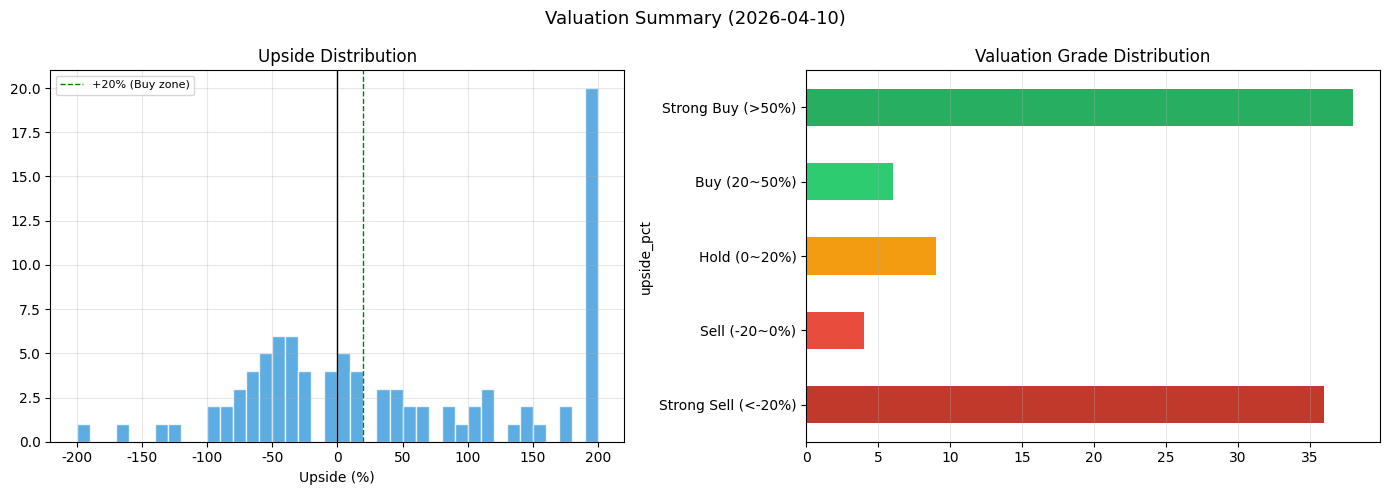


[개별 종목 시각화] ['AAPL', 'MSFT', 'NVDA']
[메모리] forecast_sarima 실행 전: 466.97 MB
[메모리] find_best_sarima_params 실행 전: 466.97 MB
[메모리] find_best_sarima_params 실행 후: 467.28 MB (변화: +0.30 MB)
[메모리] forecast_sarima 실행 후: 467.28 MB (변화: +0.30 MB)
[메모리] forecast_ets 실행 전: 467.28 MB
[메모리] forecast_ets 실행 후: 467.28 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 467.28 MB
[메모리] forecast_theta 실행 후: 467.28 MB (변화: +0.00 MB)


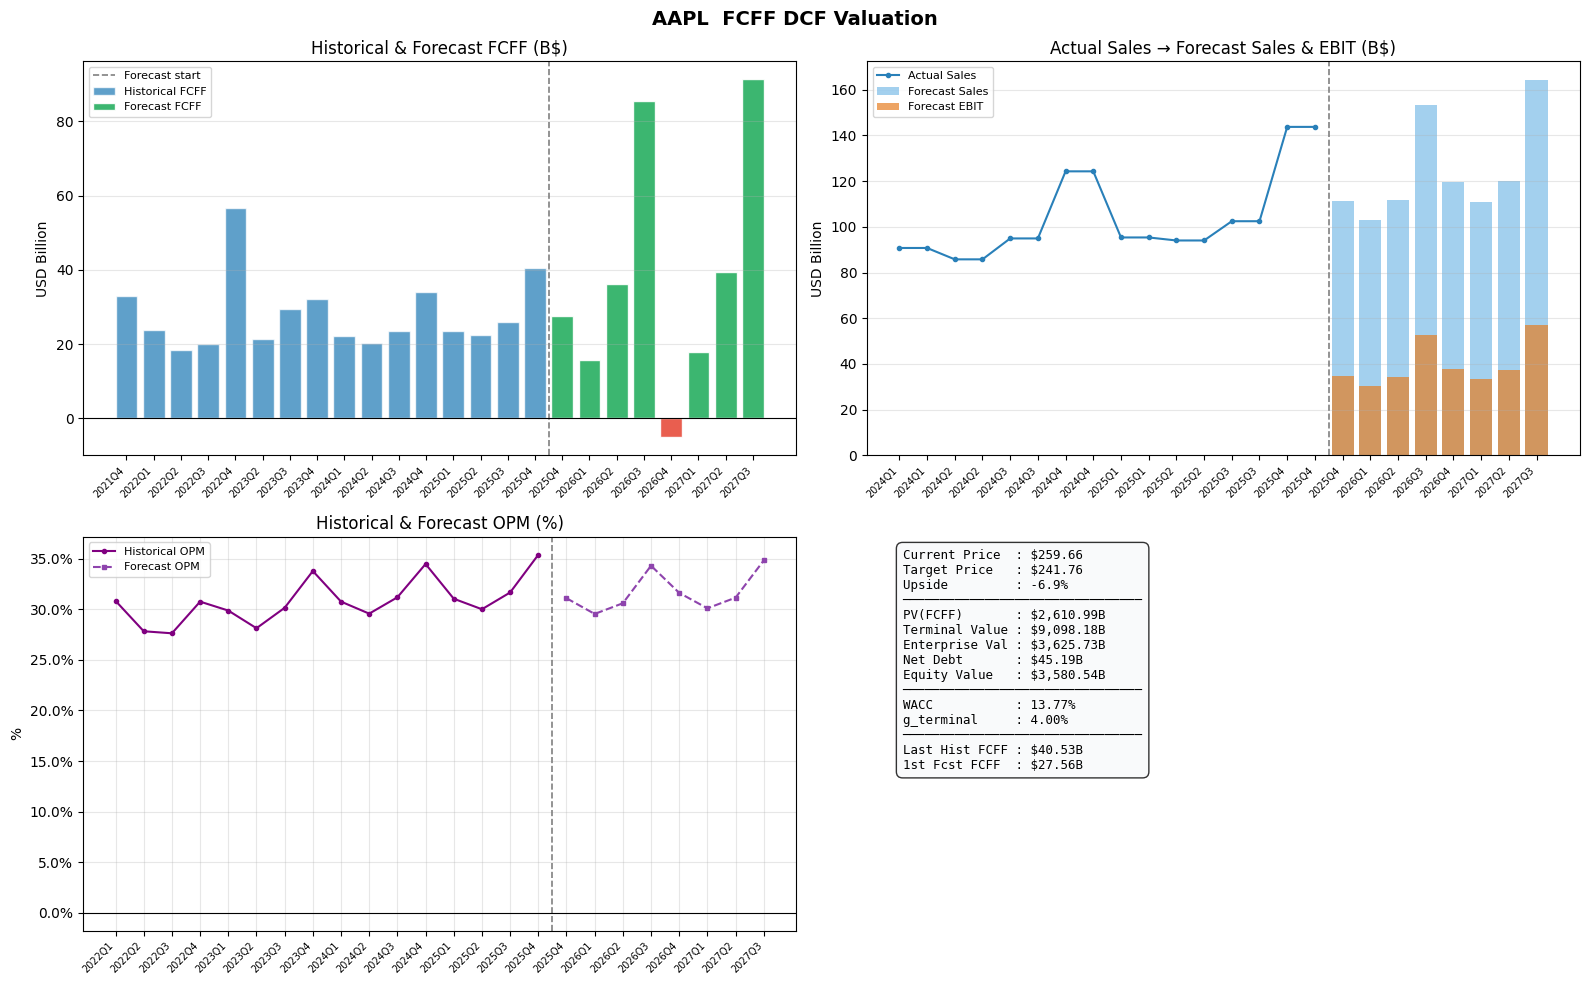

[메모리] forecast_sarima 실행 전: 476.60 MB
[메모리] find_best_sarima_params 실행 전: 476.60 MB
[메모리] find_best_sarima_params 실행 후: 471.65 MB (변화: -4.95 MB)
[메모리] forecast_sarima 실행 후: 471.65 MB (변화: -4.95 MB)
[메모리] forecast_ets 실행 전: 471.65 MB
[메모리] forecast_ets 실행 후: 471.65 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 471.65 MB
[메모리] forecast_theta 실행 후: 471.65 MB (변화: +0.00 MB)


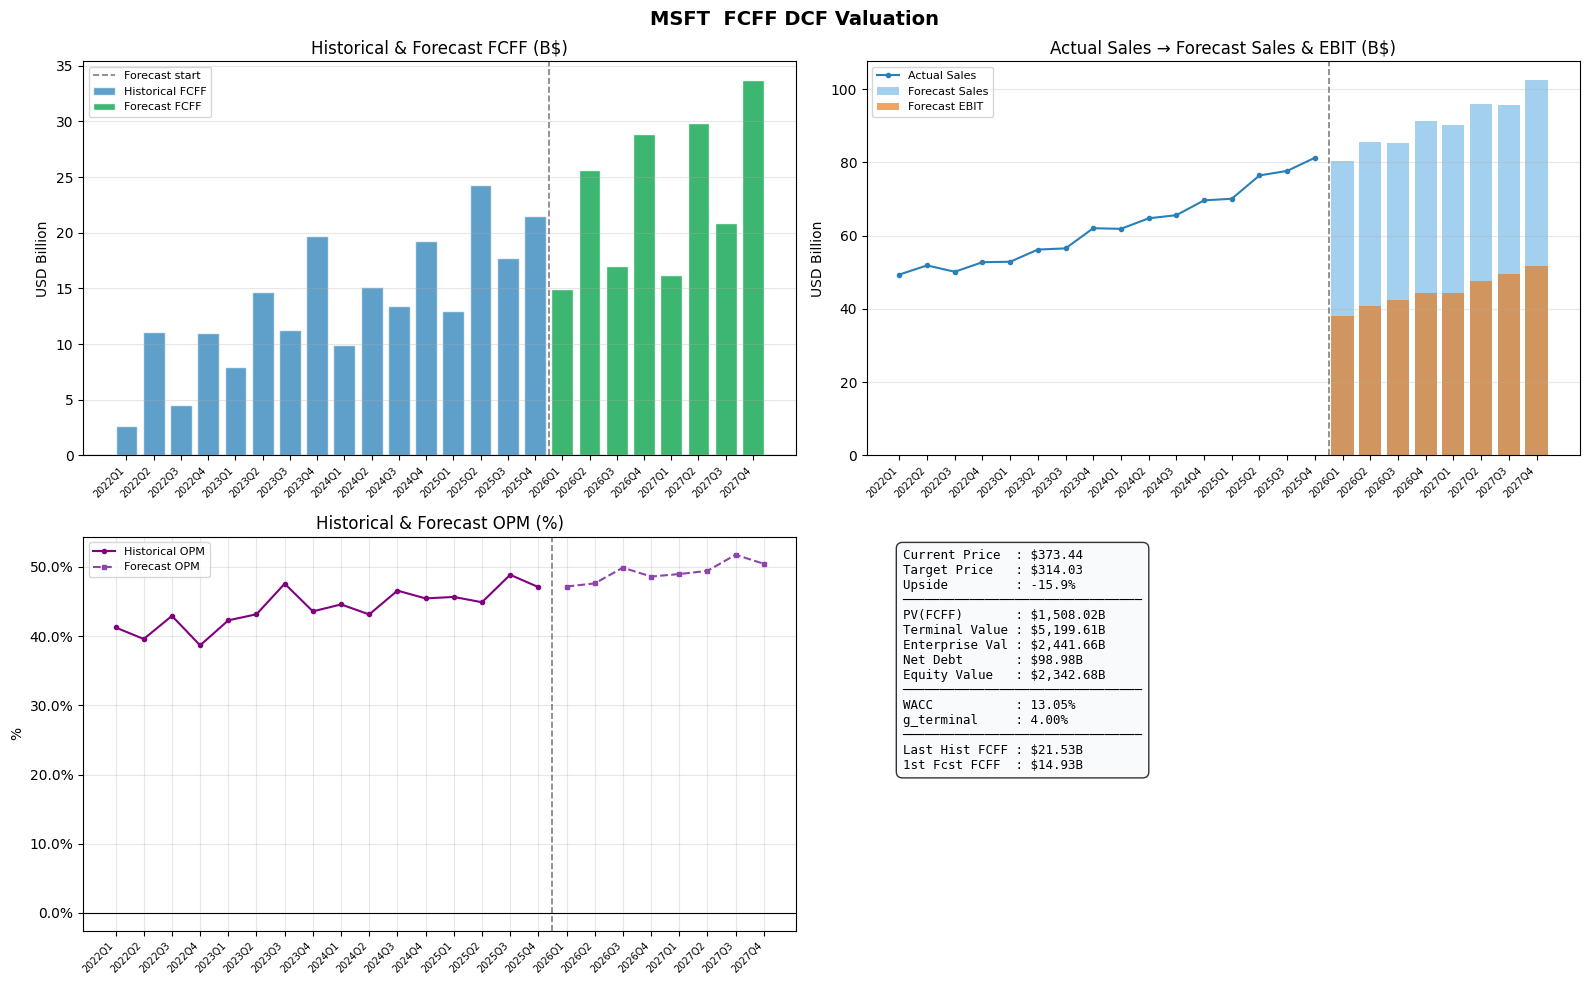

[메모리] forecast_sarima 실행 전: 477.77 MB
[메모리] find_best_sarima_params 실행 전: 477.77 MB
[메모리] find_best_sarima_params 실행 후: 472.20 MB (변화: -5.57 MB)
[메모리] forecast_sarima 실행 후: 472.20 MB (변화: -5.57 MB)
[메모리] forecast_ets 실행 전: 472.20 MB
[메모리] forecast_ets 실행 후: 472.20 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 472.20 MB
[메모리] forecast_theta 실행 후: 472.20 MB (변화: +0.00 MB)


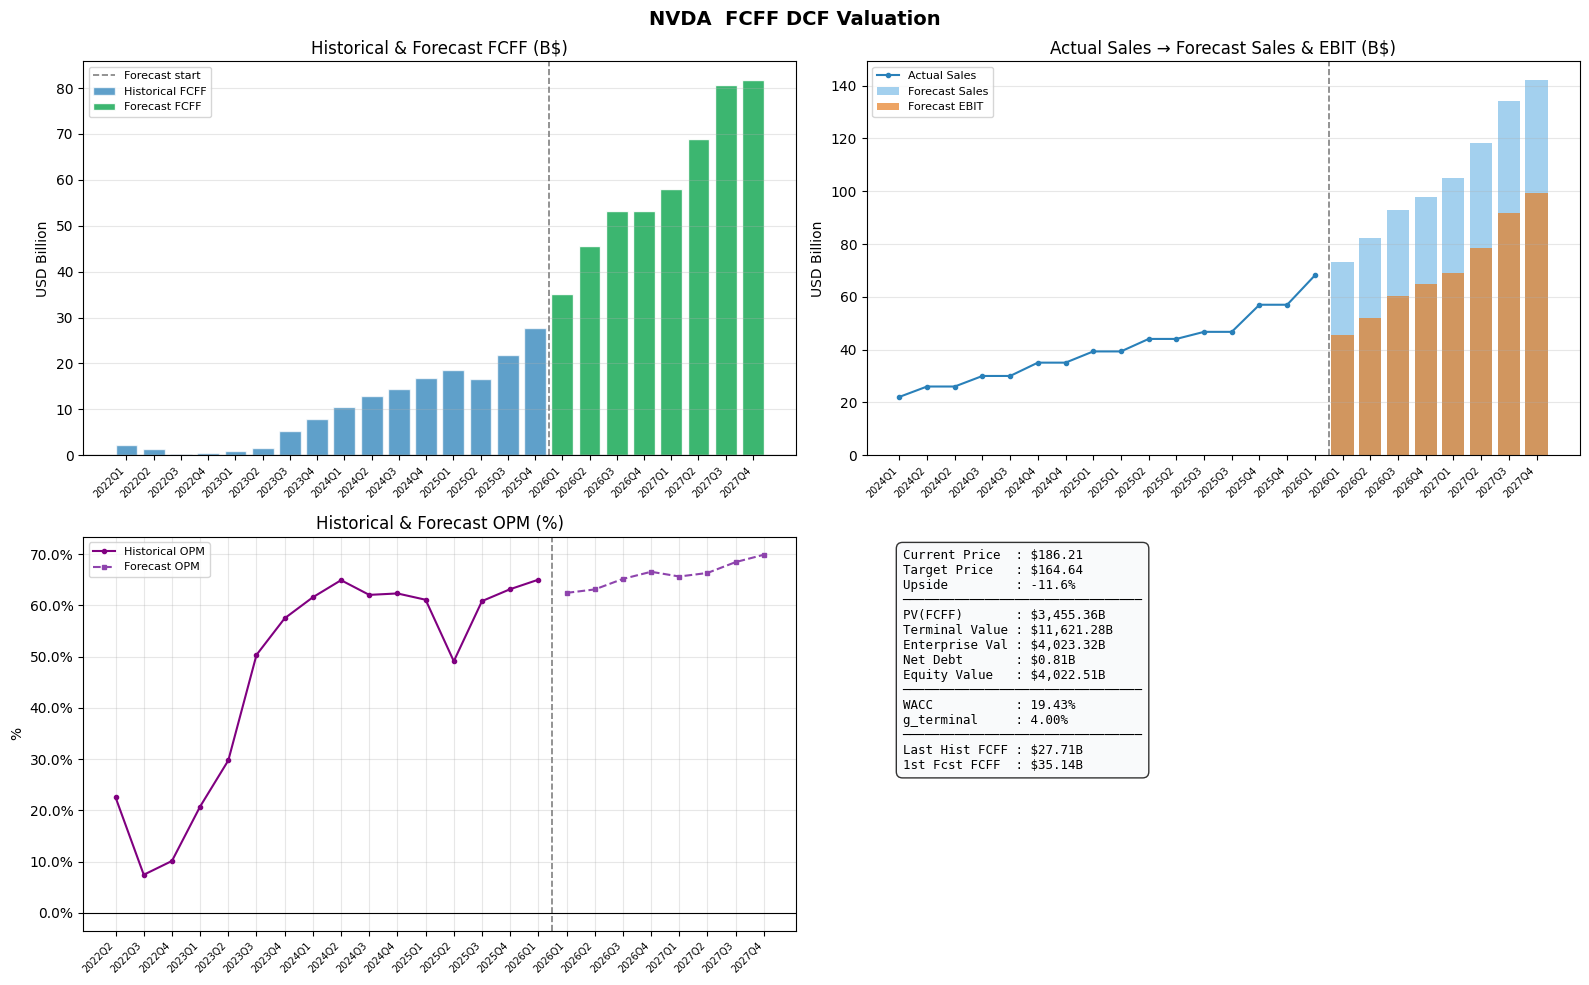

In [7]:
# ─────────────────────────────────────────────────────────────────
# Cell 6 · 결과 조회 & 시각화
# ─────────────────────────────────────────────────────────────────

# ── 6-1. DB 현황 ─────────────────────────────────────────────────
conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT DATE(date) AS run_date,
                   COUNT(DISTINCT ticker) AS tickers,
                   COUNT(*) AS total_rows,
                   AVG(target_price) AS avg_tp,
                   AVG(upside_pct) AS avg_upside
            FROM {TABLE_RESULT}
            GROUP BY DATE(date)
            ORDER BY run_date DESC
            LIMIT 10
        """)
        _summary = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print("=" * 60)
print(f"[DB 현황] {TABLE_RESULT}")
print("=" * 60)
display(_summary)

# ── 6-2. 최신 run_date 기준 업사이드 상위/하위 ────────────────────
conn = get_conn()
try:
    with conn.cursor() as cur:
        # 최신 run_date 찾기
        cur.execute(f"SELECT MAX(date) AS max_date FROM {TABLE_RESULT}")
        max_date = cur.fetchone()["max_date"]

        if max_date:
            cur.execute(f"""
                SELECT ticker, MAX(target_price) AS target_price,
                       MAX(current_price) AS current_price,
                       MAX(upside_pct) AS upside_pct,
                       MAX(discount_rate) AS wacc,
                       MAX(g_terminal) AS g_terminal
                FROM {TABLE_RESULT}
                WHERE date = %s AND target_price IS NOT NULL
                GROUP BY ticker
                ORDER BY upside_pct DESC
            """, (max_date,))
            results_df = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

if max_date and not results_df.empty:
    print(f"\n[최신 run_date: {max_date}]  총 {len(results_df)}개 종목")

    print("\n🔼 업사이드 TOP 20")
    display(results_df.head(20)[["ticker","target_price","current_price","upside_pct","wacc","g_terminal"]])

    print("\n🔽 다운사이드 TOP 20")
    display(results_df.tail(20)[["ticker","target_price","current_price","upside_pct","wacc","g_terminal"]])

    # 업사이드 분포 히스토그램
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Valuation Summary ({max_date})", fontsize=13)

    ax = axes[0]
    upside_clean = results_df["upside_pct"].dropna().clip(-200, 200)
    ax.hist(upside_clean, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(20, color="green", lw=1, ls="--", label="+20% (Buy zone)")
    ax.set_title("Upside Distribution"); ax.set_xlabel("Upside (%)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[1]
    grade_counts = pd.cut(results_df["upside_pct"],
                          bins=[-np.inf, -20, 0, 20, 50, np.inf],
                          labels=["Strong Sell (<-20%)", "Sell (-20~0%)",
                                  "Hold (0~20%)", "Buy (20~50%)", "Strong Buy (>50%)"])
    grade_counts.value_counts().sort_index().plot(
        kind="barh", ax=ax,
        color=["#c0392b","#e74c3c","#f39c12","#2ecc71","#27ae60"]
    )
    ax.set_title("Valuation Grade Distribution"); ax.grid(axis="x", alpha=0.3)

    plt.tight_layout(); plt.show()
else:
    print("[INFO] 데이터 없음 — Cell 5 배치 실행 후 재시도")

# ── 6-3. 개별 종목 시각화 ────────────────────────────────────────
VIZ_TICKERS = ["AAPL", "MSFT", "NVDA"]   # ← 원하는 종목으로 변경

print(f"\n[개별 종목 시각화] {VIZ_TICKERS}")
for tk in VIZ_TICKERS:
    try:
        m = DCFModel(ticker=tk, engine=engine, verbose=False).run()
        m.plot()
    except Exception as e:
        print(f"  [{tk}] 시각화 실패: {e}")


## Cell 7 · Sensitivity Analysis (WACC x g_terminal)

> Set `SENS_TICKERS` to the tickers you want to analyse.  
> Visualises Target Price changes across WACC ±4pp and g_terminal ±2pp ranges  
> via heatmap, tornado chart, and Monte Carlo simulation.


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  Cell 7 · Sensitivity Analysis
#  ─ 2D heatmap : WACC × g_terminal  →  Target Price / Upside %
#  ─ Tornado chart : single-param sweep  →  TP range
#  ─ Monte Carlo   : input uncertainty  →  TP distribution
# ═══════════════════════════════════════════════════════════════

SENS_TICKERS = ["MSFT", "NVDA", "AAPL"]   # <- tickers to analyse

# ── Parameter ranges ─────────────────────────────────────────────
WACC_STEPS  = 9     # WACC grid points
G_STEPS     = 7     # g_terminal grid points
WACC_DELTA  = 0.04  # base WACC ± 4 pp
G_DELTA     = 0.02  # base g    ± 2 pp
MC_RUNS     = 2000  # Monte Carlo iterations

# ── Fast scalar DCF helper ────────────────────────────────────────
def _dcf_tp(all_annual, fcff_last, net_debt, shares, wacc, g):
    """Annual FCFF array + params -> Target Price (scalar)"""
    if wacc - g < 0.005 or shares <= 0:
        return np.nan
    pv_f  = sum(all_annual[t] / (1 + wacc) ** (t + 1)
                for t in range(len(all_annual)))
    tv    = fcff_last * (1 + g) / (wacc - g)
    pv_tv = tv / (1 + wacc) ** len(all_annual)
    return max((pv_f + pv_tv - net_debt) / shares, 0)


for SENS_TICKER in SENS_TICKERS:
    print(f"\n{'='*64}")
    print(f"  Sensitivity Analysis: {SENS_TICKER}")
    print(f"{'='*64}")

    try:
        _m = DCFModel(ticker=SENS_TICKER, engine=engine, verbose=False)
        _m.run()
    except Exception as e:
        print(f"  [{SENS_TICKER}] model failed: {e}")
        continue

    v          = _m.valuation
    wacc_base  = v["wacc"]
    g_base     = v["g_terminal"]
    all_annual = np.array(v["all_annual"])
    fcff_last  = v["fcff_last_annual"]
    net_debt   = v["net_debt"]
    shares     = v["shares"]
    tp_base    = v["target_price"]
    cp         = v["current_price"]
    moat_lbl   = v.get("moat_label", "N/A")
    n_ph2      = v.get("n_phase2",  0)

    if np.isnan(tp_base) or shares <= 0:
        print(f"  [{SENS_TICKER}] TP unavailable — skipping")
        continue

    print(f"  Base  WACC={wacc_base*100:.2f}%  g={g_base*100:.2f}%  "
          f"TP=${tp_base:.2f}  Moat={moat_lbl}  Phase2={n_ph2}yr")

    # ════════════════════════════════════════════════════════════
    # 1) 2-D heatmaps  (TP  &  Upside %)
    # ════════════════════════════════════════════════════════════
    wacc_arr = np.linspace(max(wacc_base - WACC_DELTA, 0.04),
                           wacc_base + WACC_DELTA, WACC_STEPS)
    g_arr    = np.linspace(max(g_base - G_DELTA, 0.00),
                           min(g_base + G_DELTA, 0.08), G_STEPS)

    tp_mat     = np.full((len(g_arr), len(wacc_arr)), np.nan)
    upside_mat = np.full_like(tp_mat, np.nan)

    for ri, g_ in enumerate(g_arr):
        for ci, w_ in enumerate(wacc_arr):
            tp_ = _dcf_tp(all_annual, fcff_last, net_debt, shares, w_, g_)
            if tp_ is not None and not np.isnan(tp_):
                tp_mat[ri, ci] = tp_
                if cp > 0:
                    upside_mat[ri, ci] = (tp_ / cp - 1) * 100

    # ════════════════════════════════════════════════════════════
    # 2) Tornado chart
    # ════════════════════════════════════════════════════════════
    tornado_params = {
        "WACC (+/-4pp)":      ("wacc", wacc_base - 0.04, wacc_base + 0.04),
        "g_terminal (+/-2pp)":("g",    max(g_base - 0.02, 0.005), g_base + 0.02),
        "WACC (+/-2pp)":      ("wacc", wacc_base - 0.02, wacc_base + 0.02),
        "g_terminal (+/-1pp)":("g",    max(g_base - 0.01, 0.005), g_base + 0.01),
        "FCFF x0.8 / x1.2":  ("fcff", 0.80, 1.20),
        "Net Debt x0.5/x1.5":("debt", 0.50, 1.50),
    }

    tornado_data = []
    for label, (ptype, lo, hi) in tornado_params.items():
        if ptype == "wacc":
            tp_lo = _dcf_tp(all_annual, fcff_last, net_debt, shares, lo, g_base)
            tp_hi = _dcf_tp(all_annual, fcff_last, net_debt, shares, hi, g_base)
        elif ptype == "g":
            tp_lo = _dcf_tp(all_annual, fcff_last, net_debt, shares, wacc_base, lo)
            tp_hi = _dcf_tp(all_annual, fcff_last, net_debt, shares, wacc_base, hi)
        elif ptype == "fcff":
            tp_lo = _dcf_tp(all_annual * lo, fcff_last * lo, net_debt, shares, wacc_base, g_base)
            tp_hi = _dcf_tp(all_annual * hi, fcff_last * hi, net_debt, shares, wacc_base, g_base)
        elif ptype == "debt":
            tp_lo = _dcf_tp(all_annual, fcff_last, net_debt * hi, shares, wacc_base, g_base)
            tp_hi = _dcf_tp(all_annual, fcff_last, net_debt * lo, shares, wacc_base, g_base)
        else:
            continue
        if tp_lo is not None and tp_hi is not None:
            tornado_data.append((label, tp_lo, tp_hi))

    tornado_data.sort(key=lambda x: abs(x[2] - x[1]), reverse=True)

    # ════════════════════════════════════════════════════════════
    # 3) Monte Carlo
    # ════════════════════════════════════════════════════════════
    np.random.seed(42)
    mc_wacc   = np.random.normal(wacc_base, 0.015, MC_RUNS)
    mc_g      = np.random.normal(g_base,    0.008, MC_RUNS)
    mc_fcff_s = np.random.normal(1.0,       0.10,  MC_RUNS)

    mc_tp = []
    for w_, g_, fs_ in zip(mc_wacc, mc_g, mc_fcff_s):
        if w_ - g_ < 0.005 or w_ < 0.02:
            continue
        tp_ = _dcf_tp(all_annual * fs_, fcff_last * fs_, net_debt, shares, w_, g_)
        if tp_ is not None and not np.isnan(tp_) and 0 < tp_ < tp_base * 10:
            mc_tp.append(tp_)
    mc_tp = np.array(mc_tp)

    # ════════════════════════════════════════════════════════════
    # Visualisation (2x2)
    # ════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        f"{SENS_TICKER}  Sensitivity Analysis  |  "
        f"Base TP=${tp_base:.2f}  CP=${cp:.2f}  "
        f"[{moat_lbl} / Phase2 {n_ph2}yr]",
        fontsize=13, fontweight="bold"
    )

    # ── (1) Target Price heatmap ──────────────────────────────────
    ax = axes[0, 0]
    vmin = np.nanpercentile(tp_mat, 5)
    vmax = np.nanpercentile(tp_mat, 95)
    im = ax.imshow(tp_mat, aspect="auto", cmap="RdYlGn",
                   vmin=vmin, vmax=vmax, origin="lower")
    plt.colorbar(im, ax=ax, label="Target Price ($)")

    ci_b = np.argmin(np.abs(wacc_arr - wacc_base))
    ri_b = np.argmin(np.abs(g_arr    - g_base))
    ax.plot(ci_b, ri_b, marker="*", ms=16, color="white",
            markeredgecolor="black", markeredgewidth=0.8, zorder=5,
            label=f"Base TP=${tp_base:.0f}")

    for ri in range(len(g_arr)):
        for ci in range(len(wacc_arr)):
            val = tp_mat[ri, ci]
            if not np.isnan(val):
                txt_col = "white" if (val < vmin * 1.1 or val > vmax * 0.9) else "black"
                ax.text(ci, ri, f"${val:.0f}", ha="center", va="center",
                        fontsize=7, color=txt_col)

    ax.set_xticks(range(len(wacc_arr)))
    ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_arr], rotation=45, fontsize=7)
    ax.set_yticks(range(len(g_arr)))
    ax.set_yticklabels([f"{g*100:.1f}%" for g in g_arr], fontsize=7)
    ax.set_xlabel("WACC")
    ax.set_ylabel("g_terminal")
    ax.set_title("Target Price  —  WACC x g heatmap")
    ax.legend(fontsize=8, loc="upper right")

    # ── (2) Upside % heatmap ──────────────────────────────────────
    ax = axes[0, 1]
    im2 = ax.imshow(upside_mat, aspect="auto", cmap="RdYlGn",
                    vmin=-50, vmax=100, origin="lower")
    plt.colorbar(im2, ax=ax, label="Upside (%)")
    ax.plot(ci_b, ri_b, marker="*", ms=16, color="white",
            markeredgecolor="black", markeredgewidth=0.8, zorder=5,
            label=f"Base TP=${tp_base:.0f}")

    for ri in range(len(g_arr)):
        for ci in range(len(wacc_arr)):
            val = upside_mat[ri, ci]
            if not np.isnan(val):
                ax.text(ci, ri, f"{val:+.0f}%", ha="center", va="center",
                        fontsize=7, color="black")

    ax.set_xticks(range(len(wacc_arr)))
    ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_arr], rotation=45, fontsize=7)
    ax.set_yticks(range(len(g_arr)))
    ax.set_yticklabels([f"{g*100:.1f}%" for g in g_arr], fontsize=7)
    ax.set_xlabel("WACC")
    ax.set_ylabel("g_terminal")
    ax.set_title("Upside (%)  —  WACC x g heatmap")
    ax.legend(fontsize=8, loc="upper right")

    # ── (3) Tornado chart ─────────────────────────────────────────
    ax = axes[1, 0]
    labels  = [t[0] for t in tornado_data]
    lo_vals = [t[1] for t in tornado_data]
    hi_vals = [t[2] for t in tornado_data]
    y_pos   = range(len(labels))

    for y, lo, hi in zip(y_pos, lo_vals, hi_vals):
        # green = favourable side, red = unfavourable side
        if lo < hi:
            ax.barh(y, hi - tp_base, left=tp_base,
                    color="#2ecc71", alpha=0.8, height=0.5)
            ax.barh(y, lo - tp_base, left=tp_base,
                    color="#e74c3c", alpha=0.8, height=0.5)
        else:
            ax.barh(y, lo - tp_base, left=tp_base,
                    color="#2ecc71", alpha=0.8, height=0.5)
            ax.barh(y, hi - tp_base, left=tp_base,
                    color="#e74c3c", alpha=0.8, height=0.5)
        ax.text(max(lo, hi) + tp_base * 0.01, y,
                f"${max(lo, hi):.0f}", va="center", fontsize=8)
        ax.text(min(lo, hi) - tp_base * 0.01, y,
                f"${min(lo, hi):.0f}", va="center", ha="right", fontsize=8)

    ax.axvline(tp_base, color="black", lw=1.5, ls="--",
               label=f"Base TP=${tp_base:.2f}")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Target Price ($)")
    ax.set_title("Tornado Chart  —  Parameter Sensitivity")
    ax.legend(fontsize=8)
    ax.grid(axis="x", alpha=0.3)

    # ── (4) Monte Carlo distribution ─────────────────────────────
    ax = axes[1, 1]
    if len(mc_tp) > 100:
        ax.hist(mc_tp, bins=60, color="#3498db", edgecolor="white",
                alpha=0.75, density=True,
                label=f"MC distribution (n={len(mc_tp):,})")
        ax.axvline(tp_base, color="black", lw=2.0, ls="--",
                   label=f"Base TP=${tp_base:.2f}")
        if not np.isnan(cp):
            ax.axvline(cp, color="#e74c3c", lw=2.0,
                       label=f"Current price ${cp:.2f}")

        p10, p25, p50, p75, p90 = np.percentile(mc_tp, [10, 25, 50, 75, 90])
        for pval, plbl, col in [
            (p10, "P10", "#e74c3c"),
            (p50, "P50", "#f39c12"),
            (p90, "P90", "#2ecc71"),
        ]:
            ax.axvline(pval, color=col, lw=1.2, ls=":",
                       label=f"{plbl}=${pval:.0f}")

        if not np.isnan(cp) and cp > 0:
            prob_up = (mc_tp > cp).mean() * 100
            ax.text(0.97, 0.95,
                    f"P(TP > current price) = {prob_up:.1f}%",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=10, fontweight="bold",
                    color="#2ecc71" if prob_up > 50 else "#e74c3c")

        ax.set_title(
            f"Monte Carlo TP Distribution\n"
            f"P50=${p50:.0f}   P10-P90: ${p10:.0f} - ${p90:.0f}"
        )
    else:
        ax.text(0.5, 0.5, "Insufficient MC data",
                transform=ax.transAxes, ha="center", va="center", fontsize=12)
        ax.set_title("Monte Carlo TP Distribution")

    ax.set_xlabel("Target Price ($)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Summary text ─────────────────────────────────────────────
    print(f"\n  [TP Range Summary]")
    print(f"    Heatmap range   : ${np.nanmin(tp_mat):.0f} - ${np.nanmax(tp_mat):.0f}")
    if len(mc_tp) > 100:
        print(f"    MC P10/P50/P90  : ${p10:.0f} / ${p50:.0f} / ${p90:.0f}")
        if not np.isnan(cp) and cp > 0:
            print(f"    P(TP > cur price): {prob_up:.1f}%")
    print(f"    Most sensitive  : {tornado_data[0][0]}  "
          f"(${min(tornado_data[0][1], tornado_data[0][2]):.0f}"
          f" - ${max(tornado_data[0][1], tornado_data[0][2]):.0f})")


## FMP 데이터 적합성 확인

In [16]:
# ═══════════════════════════════════════════════════════════════
# AUPH NWC 진단 전용 셀
# ═══════════════════════════════════════════════════════════════
import sys, os

# ── DATA 폴더 경로 자동 감지 (Cell 1과 동일한 후보 리스트) ──────
DATA_CANDIDATES = [
    r"D:\DATA",                                      # 데스크톱
    r"C:\Users\(사용자명)\Documents\DATA",            # 노트북
    os.path.expanduser("~/DATA"),
    # ... 실제 본인 환경의 후보 경로를 넣으세요
]
for p in DATA_CANDIDATES:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)
        print(f"[path] added: {p}")
        break

import pandas as pd
import numpy as np
from scipy import stats
import pymysql
from config import DB_CONFIG  # 이제 동작

# ... (이하 이전 진단 코드 그대로)

ModuleNotFoundError: No module named 'config'